# **Brent Petrol Fiyat Tahmini İçin Hibrit Makine Öğrenmesi Yaklaşımı**
### **GPR, OVX ve Zaman Serisi Tabanlı Özellikler ile Petrol Fiyat Tahmini**

Bu çalışmanın temel amacı, Brent petrol fiyatlarının kısa vadeli hareketlerini tahmin edebilmek için jeopolitik risk göstergeleri, volatilite endeksleri ve geçmiş fiyat davranışlarını birlikte kullanan hibrit bir makine öğrenmesi mimarisi geliştirmektir. Çalışmada özellikle petrol piyasalarının yalnızca geçmiş fiyat hareketlerinden değil; aynı zamanda küresel jeopolitik gelişmeler, savaş riskleri, arz-talep belirsizlikleri ve piyasa volatilitesi gibi dışsal faktörlerden de önemli ölçüde etkilendiği varsayımından hareket edilmiştir.

Petrol piyasaları, küresel ekonomik sistemin en kritik bileşenlerinden biri olup; enerji maliyetleri, lojistik operasyonlar, üretim planlamaları ve finansal piyasalar üzerinde doğrudan etkiye sahiptir. Özellikle son yıllarda yaşanan Rusya-Ukrayna savaşı, Orta Doğu’daki jeopolitik gerilimler, OPEC üretim kararları ve küresel resesyon beklentileri gibi olaylar, petrol fiyatlarında yüksek oynaklığa neden olmuştur. Bu nedenle petrol fiyat tahmini, yalnızca ekonomik değil aynı zamanda stratejik ve operasyonel açıdan da önemli bir araştırma alanı haline gelmiştir.

Bu proje kapsamında petrol fiyat tahmininde üç temel veri kaynağı kullanılmıştır:

- Brent Petrol Fiyat Verileri
- OVX (Oil Volatility Index)
- GPR (Geopolitical Risk Index) ve GPR Threat Index

Çalışmada öncelikle ham veriler üzerinde çeşitli veri ön işleme (preprocessing) adımları uygulanmıştır. Finansal zaman serilerinin yüksek gürültü (noise) içermesi nedeniyle Wavelet Denoising yöntemi kullanılarak sinyal temizleme işlemi gerçekleştirilmiştir. Ardından log dönüşümü ve winsorization yöntemleriyle uç değerlerin etkisi azaltılmıştır. Böylece modelin ani ve aşırı piyasa hareketlerinden kaynaklanan sapmalara karşı daha stabil hale gelmesi hedeflenmiştir.

Veri ön işleme aşamasından sonra modele doğrudan ham fiyat verileri verilmemiş; bunun yerine zaman serisi tabanlı özellik mühendisliği (feature engineering) uygulanmıştır. Bu kapsamda:

- Lag (gecikmeli) değişkenler,
- EMA (Exponential Moving Average),
- geçmiş volatilite etkileri,
- jeopolitik risk gecikmeleri

gibi özellikler oluşturularak modelin zamansal bağımlılıkları öğrenebilmesi amaçlanmıştır.

Çalışmanın modelleme kısmında üç farklı yaklaşım geliştirilmiştir:

1. XGBoost Regresyon Modeli
Tabular veri yapısında güçlü performans gösteren gradient boosting yaklaşımı kullanılmıştır.
2. LSTM (Long Short-Term Memory) Modeli
Zaman serilerindeki uzun dönemli bağımlılıkları öğrenebilmek amacıyla derin öğrenme tabanlı LSTM mimarisi kullanılmıştır.
3. Hibrit (Hybrid) Model Yapısı
XGBoost ve LSTM modellerinin tahminleri bir meta-model aracılığıyla birleştirilerek stacking tabanlı hibrit bir mimari geliştirilmiştir. Bu yaklaşım ile her iki modelin farklı öğrenme kabiliyetlerinden aynı anda faydalanılması hedeflenmiştir.

Çalışma boyunca modeller farklı hedef değişkenler üzerinde test edilmiştir. İlk aşamada doğrudan fiyat tahmini, daha sonra return tabanlı tahminler ve yön tahmini (classification) yaklaşımları değerlendirilmiştir. Yapılan deneyler sonucunda kısa vadeli return tahminlerinin yüksek rastlantısallık içermesi nedeniyle regresyon performanslarının düştüğü gözlemlenmiştir. Bunun üzerine proje yeniden yapılandırılmış ve lag/EMA tabanlı fiyat tahmini yaklaşımına geri dönülmüştür.

Model performanslarının değerlendirilmesinde aşağıdaki metrikler kullanılmıştır:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- MAPE (Mean Absolute Percentage Error)
- R² Score

Bunun yanında model karar mekanizmasını yorumlayabilmek amacıyla SHAP, Volatility Regime, Rolling Error, Direction Accuracy analizleri gerçekleştirilmiştir. Böylece modelin hangi değişkenlerden ne ölçüde etkilendiği incelenmiş; özellikle GPR ve OVX değişkenlerinin petrol fiyat tahminine katkısı analiz edilmiştir.

Çalışmanın nihai hedefi, yalnızca yüksek doğrulukta tahmin yapan bir model geliştirmek değil; aynı zamanda jeopolitik risklerin petrol fiyatları üzerindeki etkisini veri odaklı ve yorumlanabilir şekilde ortaya koymaktır. Bu doğrultuda geliştirilen hibrit model yapısının, geleneksel zaman serisi tahmin yöntemlerine kıyasla daha güçlü ve daha esnek bir yaklaşım sunması beklenmektedir.

In [ ]:
# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed sabitlendi:", SEED)

Seed sabitlendi: 42


### Reproducibility (Tekrarlanabilirlik) Ayarları

Derin öğrenme modellerinde eğitim süreci; ağırlıkların rastgele başlatılması, batch sıralamaları ve TensorFlow operasyonları nedeniyle her çalıştırmada farklı sonuçlar üretebilmektedir. Bu durum özellikle LSTM gibi neural network tabanlı modellerde performans metriklerinin değişkenlik göstermesine neden olabilir.

Bu problemi azaltmak ve deneylerin tekrarlanabilirliğini sağlamak amacıyla çalışmada SEED = 42 kullanılarak Python, NumPy ve TensorFlow rastgelelik mekanizmaları sabitlenmiştir. Ayrıca TensorFlow işlemlerinin daha deterministik çalışabilmesi için TF_DETERMINISTIC_OPS parametresi aktif edilmiştir.

Bu ayarlar sayesinde:

- model eğitim süreci daha stabil hale getirilmiş,
- farklı çalıştırmalarda benzer sonuçların elde edilmesi sağlanmış,
- deneylerin akademik güvenilirliği artırılmıştır.

In [ ]:
  # ============================================================
# 1. KÜTÜPHANELER
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

try:
    import pywt
    WAVELET_AVAILABLE = True
except:
    WAVELET_AVAILABLE = False
    print("PyWavelets yüklü değil.")

## **Veri Setinin Oluşturulması ve Veri Kaynakları**

Bu çalışmada kullanılan veri seti, farklı finansal ve jeopolitik veri kaynaklarının bir araya getirilmesiyle oluşturulmuştur. Modelin hem piyasa davranışlarını hem de küresel risk faktörlerini öğrenebilmesi amacıyla petrol fiyatları, volatilite endeksi ve jeopolitik risk göstergeleri aynı veri seti içerisinde entegre edilmiştir.

Çalışmada kullanılan temel değişkenler aşağıdaki gibidir:

| Değişken     | Açıklama                           |
| ------------ | ---------------------------------- |
| Brent_Petrol | Brent petrol günlük kapanış fiyatı |
| OVX          | Oil Volatility Index               |
| GPRD         | Geopolitical Risk Index            |
| GPRD_THREAT  | Geopolitical Threat Index          |


Brent petrol fiyat verileri ile OVX (Oil Volatility Index) verileri finansal piyasa verileri sağlayıcısı olan Yahoo Finance
 platformu üzerinden elde edilmiştir. Brent petrol verileri, küresel petrol piyasasındaki fiyat hareketlerini temsil ederken; OVX endeksi petrol piyasasındaki beklenen volatiliteyi ölçmektedir. Bu nedenle OVX değişkeni, piyasa belirsizliği ve risk algısının modellenmesi açısından çalışmada önemli bir rol üstlenmiştir.

Petrol piyasalarının yalnızca fiyat ve volatilite hareketlerinden değil, aynı zamanda küresel jeopolitik gelişmelerden de etkilendiği düşüncesiyle çalışmaya jeopolitik risk verileri de dahil edilmiştir. Bu kapsamda kullanılan GPRD ve GPRD_THREAT verileri, https://www.matteoiacoviello.com/gpr.htm
 adresinden elde edilmiştir.

GPR (Geopolitical Risk Index) verisi; savaş, terör, diplomatik krizler ve uluslararası çatışmalar gibi jeopolitik olayların küresel medya üzerindeki yoğunluğunu ölçen akademik tabanlı bir endekstir. GPRD_THREAT değişkeni ise doğrudan tehdit ve çatışma odaklı jeopolitik risk bileşenlerini temsil etmektedir. Bu değişkenlerin modele dahil edilmesindeki temel amaç, petrol fiyatlarının yalnızca teknik göstergelerle değil, küresel risk dinamikleriyle birlikte tahmin edilmesini sağlamaktır.

Veriler 2014–2024 dönemini kapsayacak şekilde günlük frekansta hazırlanmış ve tüm veri kaynakları tarih bazında birleştirilmiştir. Farklı kaynaklardan gelen verilerin zaman uyumluluğunu sağlayabilmek amacıyla veri temizleme, tarih eşleştirme ve eksik gözlem kontrolleri gerçekleştirilmiştir. Böylece modelleme sürecinde kullanılabilecek bütünleşik bir zaman serisi veri seti oluşturulmuştur.

Bu veri setinin oluşturulmasındaki temel amaç, Brent petrol fiyatlarının yalnızca geçmiş fiyat hareketleriyle değil; volatilite yapısı ve jeopolitik risk dinamikleriyle birlikte modellenmesini sağlamaktır. Böylece geleneksel fiyat tahmin yaklaşımlarına kıyasla daha açıklanabilir ve daha güçlü bir tahmin mimarisi geliştirilmesi hedeflenmiştir.

In [ ]:
# ============================================================
# 2. VERİ OKUMA
# ============================================================

DATA_PATH = "veriseti.xlsx"   # Colab'a yüklediğin dosya adı
SHEET_NAME = "data (1)"       # Excel sheet adı

df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

numeric_cols = ["Brent_Petrol", "OVX", "GPRD", "GPRD_THREAT"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=numeric_cols, inplace=True)

print("Veri başarıyla okundu.")
print("Boyut:", df.shape)
print(df.head())

Veri başarıyla okundu.
Boyut: (2512, 4)
            Brent_Petrol        OVX        GPRD  GPRD_THREAT
Date                                                        
2014-01-02    107.779999  20.240000   82.129776    68.293480
2014-01-03    106.889999  20.600000  117.954941   130.777634
2014-01-06    106.730003  20.700001  103.517738    65.583427
2014-01-07    107.349998  19.670000   91.531479    21.746082
2014-01-08    107.150002  20.170000   93.828888    47.491444


## **Wavelet Denoising Uygulaması**

Finansal zaman serileri yüksek seviyede gürültü (noise) içeren veri yapılarıdır. Özellikle petrol fiyatları, volatilite endeksleri ve jeopolitik risk göstergeleri; ani haber akışları, spekülatif işlemler, politik gelişmeler ve kısa vadeli piyasa tepkileri nedeniyle düzensiz ve yüksek frekanslı dalgalanmalar içermektedir. Bu durum, makine öğrenmesi modellerinin gerçek sinyali öğrenmesini zorlaştırmakta ve model performansını olumsuz etkileyebilmektedir.

Bu problemi azaltabilmek amacıyla çalışmada Wavelet Denoising yöntemi kullanılmıştır. Wavelet dönüşümü, zaman serisini farklı frekans bileşenlerine ayırarak veri içerisindeki yüksek frekanslı gürültülerin filtrelenmesini sağlayan gelişmiş bir sinyal işleme yöntemidir. Geleneksel hareketli ortalama veya filtreleme yöntemlerinden farklı olarak Wavelet yaklaşımı, hem zaman hem frekans bilgisini aynı anda analiz edebilmesi nedeniyle finansal zaman serilerinde oldukça etkili sonuçlar vermektedir.

Bu çalışmada wavelet dönüşümü için “db4” (Daubechies 4) wavelet fonksiyonu tercih edilmiştir. Daubechies wavelet ailesi, finansal zaman serilerindeki ani değişimleri ve kısa vadeli dalgalanmaları başarılı şekilde temsil edebilmesi nedeniyle literatürde yaygın olarak kullanılmaktadır.

Bu işlem sonucunda:

- Brent petrol fiyat serisi,
- GPRD serisi,
- GPRD Threat serisi

üzerindeki ani ve düzensiz gürültü bileşenleri azaltılmıştır.

Wavelet denoising uygulanmasının temel amacı, makine öğrenmesi modellerinin kısa vadeli rastlantısal hareketler yerine gerçek trend yapısını ve anlamlı ilişkileri öğrenmesini sağlamaktır. Özellikle finansal tahmin modellerinde aşırı volatilite ve noise seviyesi, modelin overfit olmasına neden olabilmektedir. Wavelet denoising sayesinde daha stabil bir veri yapısı oluşturularak model performansının artırılması hedeflenmiştir.

Bu çalışmada yapılan deneyler sonucunda, wavelet denoising uygulanmış veri setleri ile eğitilen modellerin daha kararlı tahminler ürettiği ve performans metriklerinde iyileşme sağladığı gözlemlenmiştir. Özellikle lag ve EMA tabanlı feature engineering yapılarıyla birlikte kullanıldığında, wavelet denoising modelin trend öğrenme kapasitesini güçlendirmiştir.

In [ ]:
# ============================================================
# 3. WAVELET DENOISING
# ============================================================

def apply_wavelet_denoising(series, wavelet="db4"):
    if not WAVELET_AVAILABLE:
        return series.values

    data = np.nan_to_num(series.values)

    coeff = pywt.wavedec(data, wavelet, mode="per")
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-1] - np.median(coeff[-1])))
    threshold = sigma * np.sqrt(2 * np.log(len(data)))

    coeff[1:] = [
        pywt.threshold(c, value=threshold, mode="hard")
        for c in coeff[1:]
    ]

    cleaned = pywt.waverec(coeff, wavelet, mode="per")

    return cleaned[:len(series)]


df["Price_clean"] = apply_wavelet_denoising(df["Brent_Petrol"])
df["GPRD_clean"] = apply_wavelet_denoising(df["GPRD"])
df["GPRD_THREAT_clean"] = apply_wavelet_denoising(df["GPRD_THREAT"])

print("Wavelet denoising tamamlandı.")
df[["Brent_Petrol", "Price_clean", "GPRD", "GPRD_clean"]].head()

Wavelet denoising tamamlandı.


,Brent_Petrol,Price_clean,GPRD,GPRD_clean
Date,,,,
2014-01-02,107.779999,107.425487,82.129776,103.554537
2014-01-03,106.889999,106.632784,117.954941,94.152017
2014-01-06,106.730003,106.893516,103.517738,84.081604
2014-01-07,107.349998,106.339481,91.531479,76.264545
2014-01-08,107.150002,106.952307,93.828888,71.129476


In [ ]:
# ============================================================
# WAVELET ÖNCESİ / SONRASI İLK 5 GÖZLEM KARŞILAŞTIRMA
# ============================================================

wavelet_sample = df[[
    "Brent_Petrol",
    "Price_clean",
    "GPRD",
    "GPRD_clean",
    "GPRD_THREAT",
    "GPRD_THREAT_clean"
]].head(5)

wavelet_sample.columns = [
    "Brent_Petrol (Önce)",
    "Brent_Petrol (Sonra)",
    "GPRD (Önce)",
    "GPRD (Sonra)",
    "GPRD_Threat (Önce)",
    "GPRD_Threat (Sonra)"
]

wavelet_sample = wavelet_sample.round(3)

display(wavelet_sample)

,Brent_Petrol (Önce),Brent_Petrol (Sonra),GPRD (Önce),GPRD (Sonra),GPRD_Threat (Önce),GPRD_Threat (Sonra)
Date,,,,,,
2014-01-02,107.78,107.425,82.130,103.555,68.293,59.502
2014-01-03,106.89,106.633,117.955,94.152,130.778,90.442
2014-01-06,106.73,106.894,103.518,84.082,65.583,86.177
2014-01-07,107.35,106.339,91.531,76.265,21.746,82.655
2014-01-08,107.15,106.952,93.829,71.129,47.491,80.011


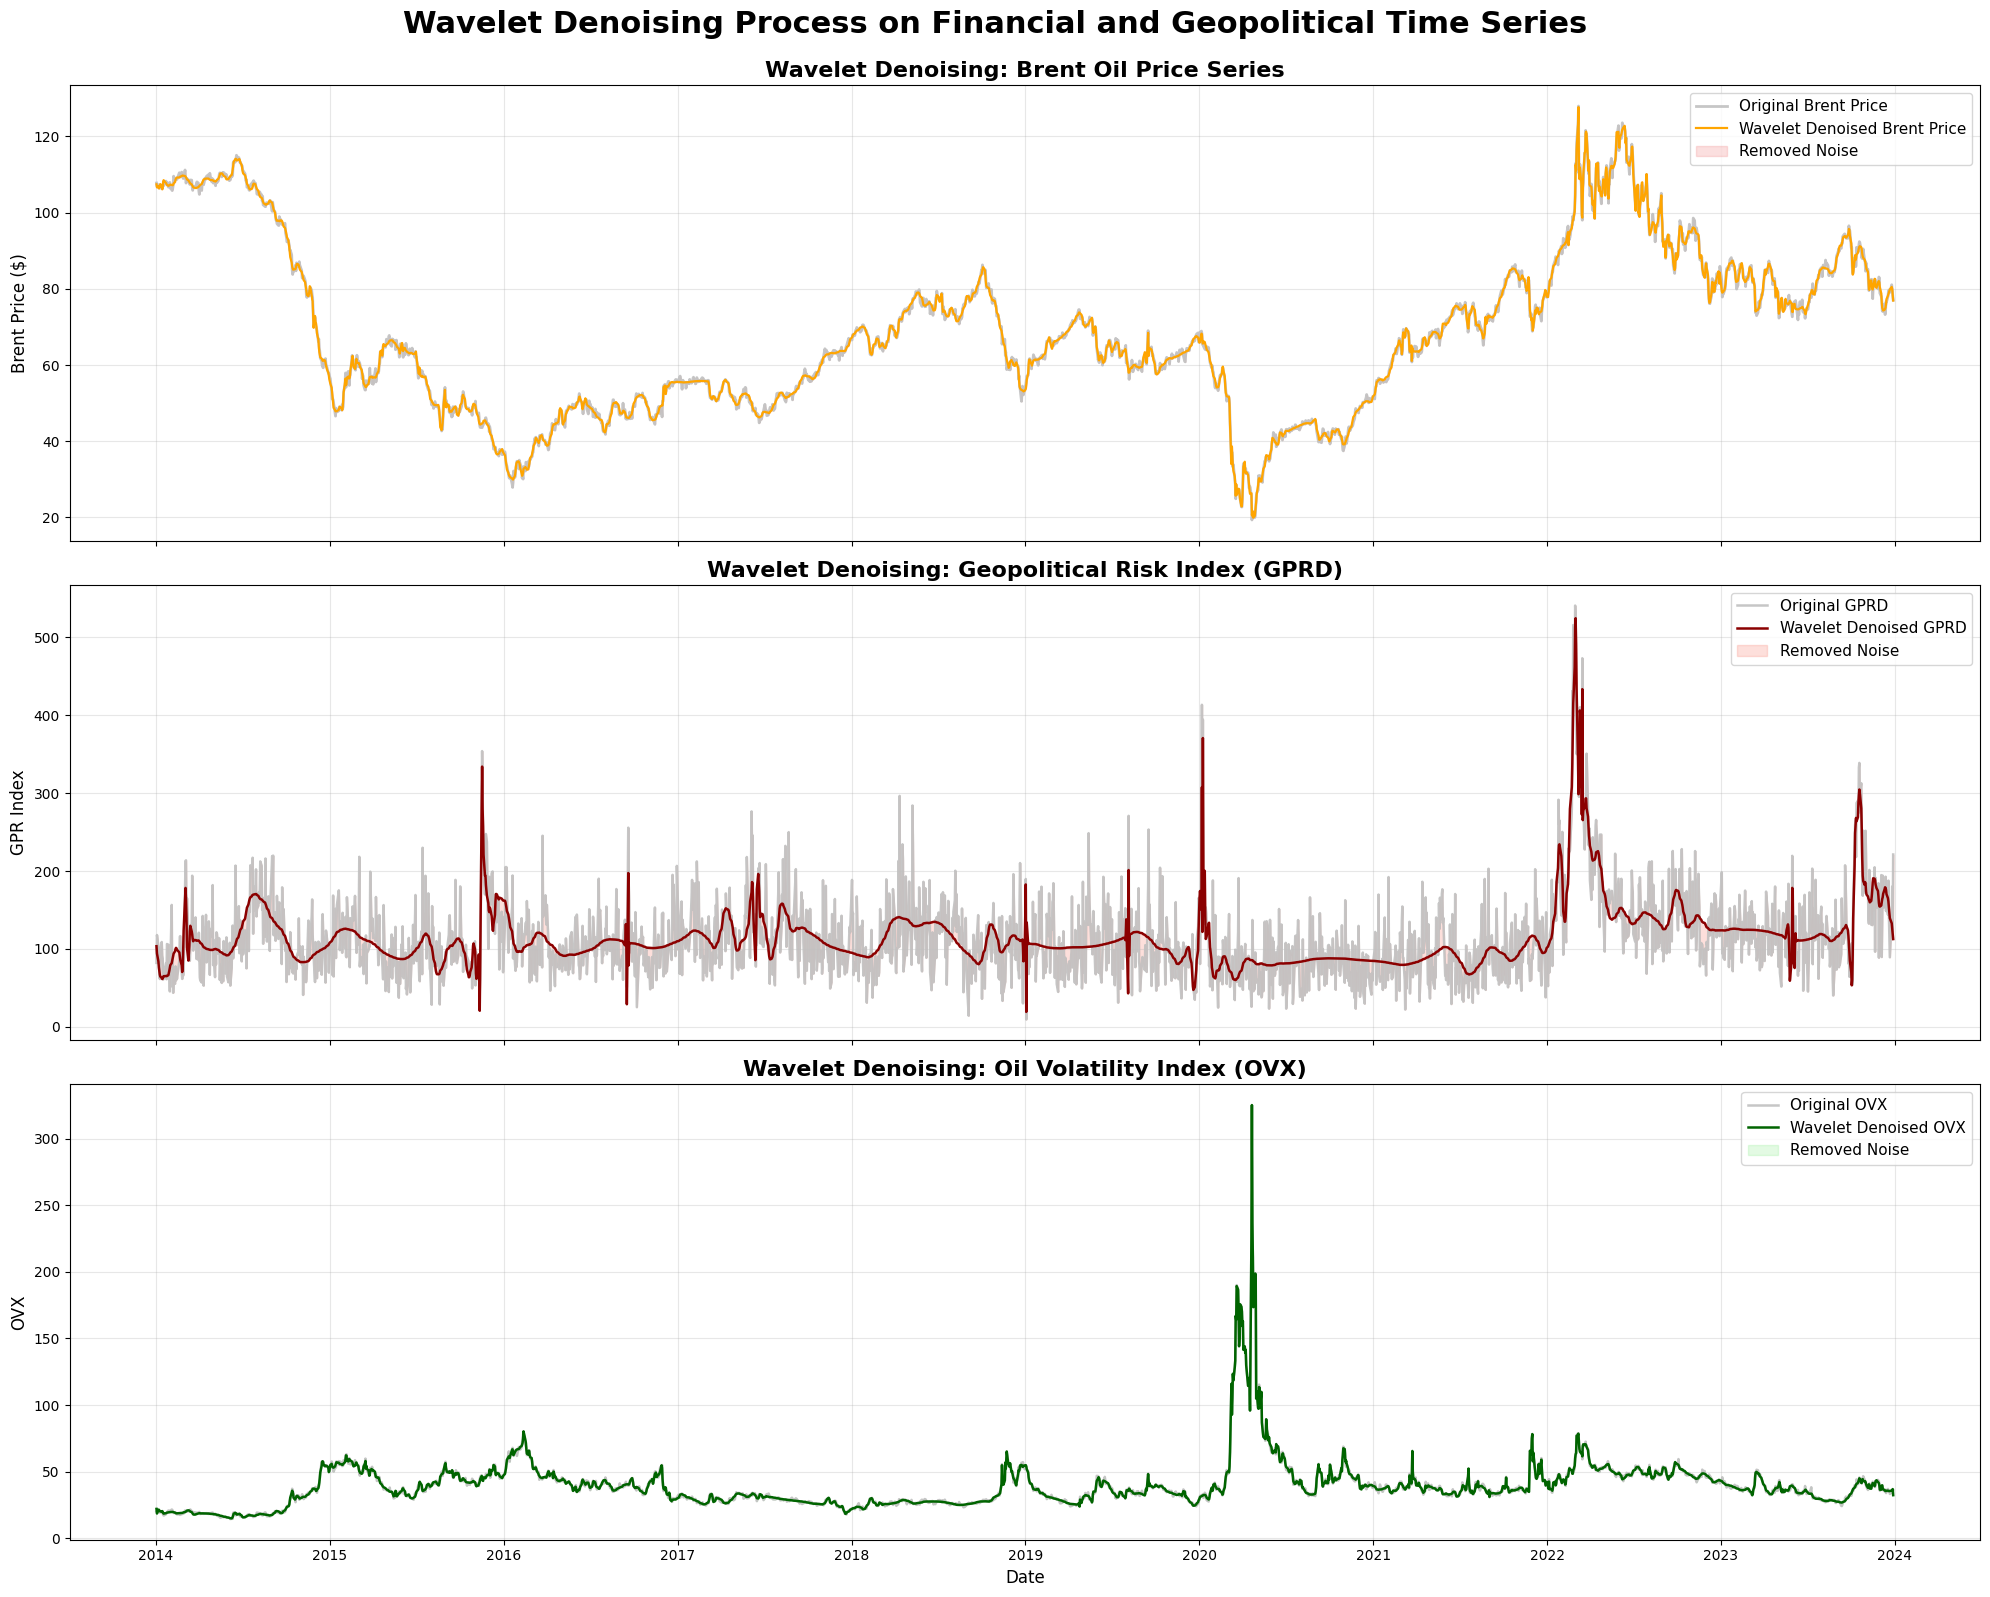

In [ ]:
# ============================================================
# IMPROVED WAVELET DENOISING VISUALIZATION
# MORE VISIBLE DIFFERENCES
# ============================================================

# OVX clean oluştur
df["OVX_clean"] = apply_wavelet_denoising(
    df["OVX"]
)

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(20, 16),
    sharex=True
)

# ============================================================
# 1. BRENT PETROL
# ============================================================

# Ham veri (daha belirgin)
axes[0].plot(
    df.index,
    df["Brent_Petrol"],
    color="silver",
    linewidth=2,
    alpha=0.9,
    label="Original Brent Price"
)

# Temizlenmiş veri
axes[0].plot(
    df.index,
    df["Price_clean"],
    color="orange",
    linewidth=1.6,
    label="Wavelet Denoised Brent Price"
)

axes[0].fill_between(
    df.index,
    df["Brent_Petrol"],
    df["Price_clean"],
    color="lightcoral",
    alpha=0.25,
    label="Removed Noise"
)

axes[0].set_title(
    "Wavelet Denoising: Brent Oil Price Series",
    fontsize=16,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Brent Price ($)",
    fontsize=12
)

axes[0].legend(
    fontsize=11,
    loc="upper right"
)

axes[0].grid(
    True,
    alpha=0.3
)

# ============================================================
# 2. GPRD
# ============================================================

axes[1].plot(
    df.index,
    df["GPRD"],
    color="silver",
    linewidth=1.8,
    alpha=0.9,
    label="Original GPRD"
)

axes[1].plot(
    df.index,
    df["GPRD_clean"],
    color="darkred",
    linewidth=1.8,
    label="Wavelet Denoised GPRD"
)

axes[1].fill_between(
    df.index,
    df["GPRD"],
    df["GPRD_clean"],
    color="salmon",
    alpha=0.25,
    label="Removed Noise"
)

axes[1].set_title(
    "Wavelet Denoising: Geopolitical Risk Index (GPRD)",
    fontsize=16,
    fontweight="bold"
)

axes[1].set_ylabel(
    "GPR Index",
    fontsize=12
)

axes[1].legend(
    fontsize=11,
    loc="upper right"
)

axes[1].grid(
    True,
    alpha=0.3
)

# ============================================================
# 3. OVX
# ============================================================

axes[2].plot(
    df.index,
    df["OVX"],
    color="silver",
    linewidth=1.8,
    alpha=0.9,
    label="Original OVX"
)

axes[2].plot(
    df.index,
    df["OVX_clean"],
    color="darkgreen",
    linewidth=1.8,
    label="Wavelet Denoised OVX"
)

axes[2].fill_between(
    df.index,
    df["OVX"],
    df["OVX_clean"],
    color="lightgreen",
    alpha=0.25,
    label="Removed Noise"
)

axes[2].set_title(
    "Wavelet Denoising: Oil Volatility Index (OVX)",
    fontsize=16,
    fontweight="bold"
)

axes[2].set_ylabel(
    "OVX",
    fontsize=12
)

axes[2].set_xlabel(
    "Date",
    fontsize=12
)

axes[2].legend(
    fontsize=11,
    loc="upper right"
)

axes[2].grid(
    True,
    alpha=0.3
)

# ============================================================
# GENERAL TITLE
# ============================================================

plt.suptitle(
    "Wavelet Denoising Process on Financial and Geopolitical Time Series",
    fontsize=22,
    fontweight="bold",
    y=0.995
)

plt.tight_layout()

plt.show()

## **Log Transformation ve Winsorization Uygulaması**

Finansal ve jeopolitik zaman serileri genellikle yüksek oynaklık (volatility), çarpıklık (skewness) ve aşırı uç değerler (outliers) içeren veri yapılarıdır. Özellikle jeopolitik risk endeksleri ve volatilite göstergeleri, kriz dönemlerinde ani sıçramalar gösterebilmekte ve bu durum makine öğrenmesi modellerinin stabil öğrenme gerçekleştirmesini zorlaştırabilmektedir.

Bu nedenle çalışmada, wavelet denoising sonrasında veri setine ek olarak:

- Log Transformation
- Winsorization

işlemleri uygulanmıştır.

### Log Transformation

İlk aşamada veri setindeki pozitif ve yüksek varyanslı değişkenlere logaritmik dönüşüm uygulanmıştır:

Log dönüşümünün temel amacı, veri dağılımındaki aşırı sağ çarpıklığı azaltmak ve yüksek değerlerin model üzerindeki baskın etkisini düşürmektir. Özellikle GPR ve OVX gibi endeksler kriz dönemlerinde ani sıçramalar gösterebildiğinden, ham veriler doğrudan modele verildiğinde model belirli dönemlere aşırı duyarlı hale gelebilmektedir.

Log dönüşümü sayesinde:

- veri dağılımı daha dengeli hale getirilmiş,
- varyans azaltılmış,
- büyük ölçekli değerlerin normalize edilmesi sağlanmış,
- modelin öğrenme stabilitesi artırılmıştır.

Bu işlem özellikle finansal zaman serilerinde yaygın olarak kullanılan temel ön işleme yöntemlerinden biridir.

### Winsorization

Log dönüşümünden sonra veri setine winsorization işlemi uygulanmıştır:

Winsorization yöntemi, veri setindeki aşırı uç değerlerin tamamen silinmesi yerine belirli bir eşik seviyesine çekilmesini sağlayan istatistiksel bir veri dönüştürme yöntemidir.

Bu çalışmada özellikle:

- jeopolitik krizler,
- savaş dönemleri,
- ani volatilite sıçramaları

gibi dönemlerde oluşan ekstrem değerlerin modele zarar vermesini önlemek amacıyla winsorization uygulanmıştır.

Bu yaklaşımın tercih edilmesinin temel nedeni, finansal zaman serilerinde uç değerlerin tamamen kaldırılmasının önemli piyasa bilgisinin kaybolmasına neden olabilmesidir. Winsorization sayesinde:

- veri içerisindeki ekstrem davranış korunmuş,
- ancak bu değerlerin modele aşırı baskı kurması engellenmiştir.

### Uygulanan Değişkenler

Bu çalışmada log transform ve winsorization işlemleri aşağıdaki değişkenlere uygulanmıştır:

- GPRD
- GPRD_THREAT
- OVX

Brent petrol fiyat serisine doğrudan log dönüşümü uygulanmamıştır. Bunun temel nedeni, fiyat serisinin zaten wavelet denoising sonrası daha stabil hale gelmiş olması ve fiyat ölçeğinin model tarafından doğrudan öğrenilmesinin hedeflenmesidir.

###Modelleme Sürecine Etkisi

Yapılan deneyler sonucunda log transformation ve winsorization işlemlerinin:

- modelin aşırı volatil dönemlere karşı daha stabil davranmasını sağladığı,
- overfitting riskini azalttığı,
- özellikle XGBoost modelinde feature importance dağılımını daha dengeli hale getirdiği

gözlemlenmiştir.

Bu ön işleme adımları sayesinde veri seti, makine öğrenmesi modellerinin daha sağlıklı öğrenme gerçekleştirebileceği yapıya dönüştürülmüş ve sonraki feature engineering aşamaları için daha uygun hale getirilmiştir.

In [ ]:
# ============================================================
# 4. LOG TRANSFORM + WINSORIZATION
# ============================================================

df["GPRD_final"] = winsorize(
    np.log1p(np.clip(df["GPRD_clean"], 0, None)),
    limits=[0, 0.01]
)

df["GPRD_THREAT_final"] = winsorize(
    np.log1p(np.clip(df["GPRD_THREAT_clean"], 0, None)),
    limits=[0, 0.01]
)

df["OVX_final"] = winsorize(
    np.log1p(np.clip(df["OVX"], 0, None)),
    limits=[0, 0.01]
)

print("Log transform + winsorization tamamlandı.")
df[["GPRD_final", "GPRD_THREAT_final", "OVX_final"]].head()

Log transform + winsorization tamamlandı.


,GPRD_final,GPRD_THREAT_final,OVX_final
Date,,,
2014-01-02,4.649709,4.102683,3.055886
2014-01-03,4.555476,4.515703,3.072693
2014-01-06,4.443611,4.467938,3.077312
2014-01-07,4.347235,4.426705,3.028683
2014-01-08,4.278463,4.394586,3.052585


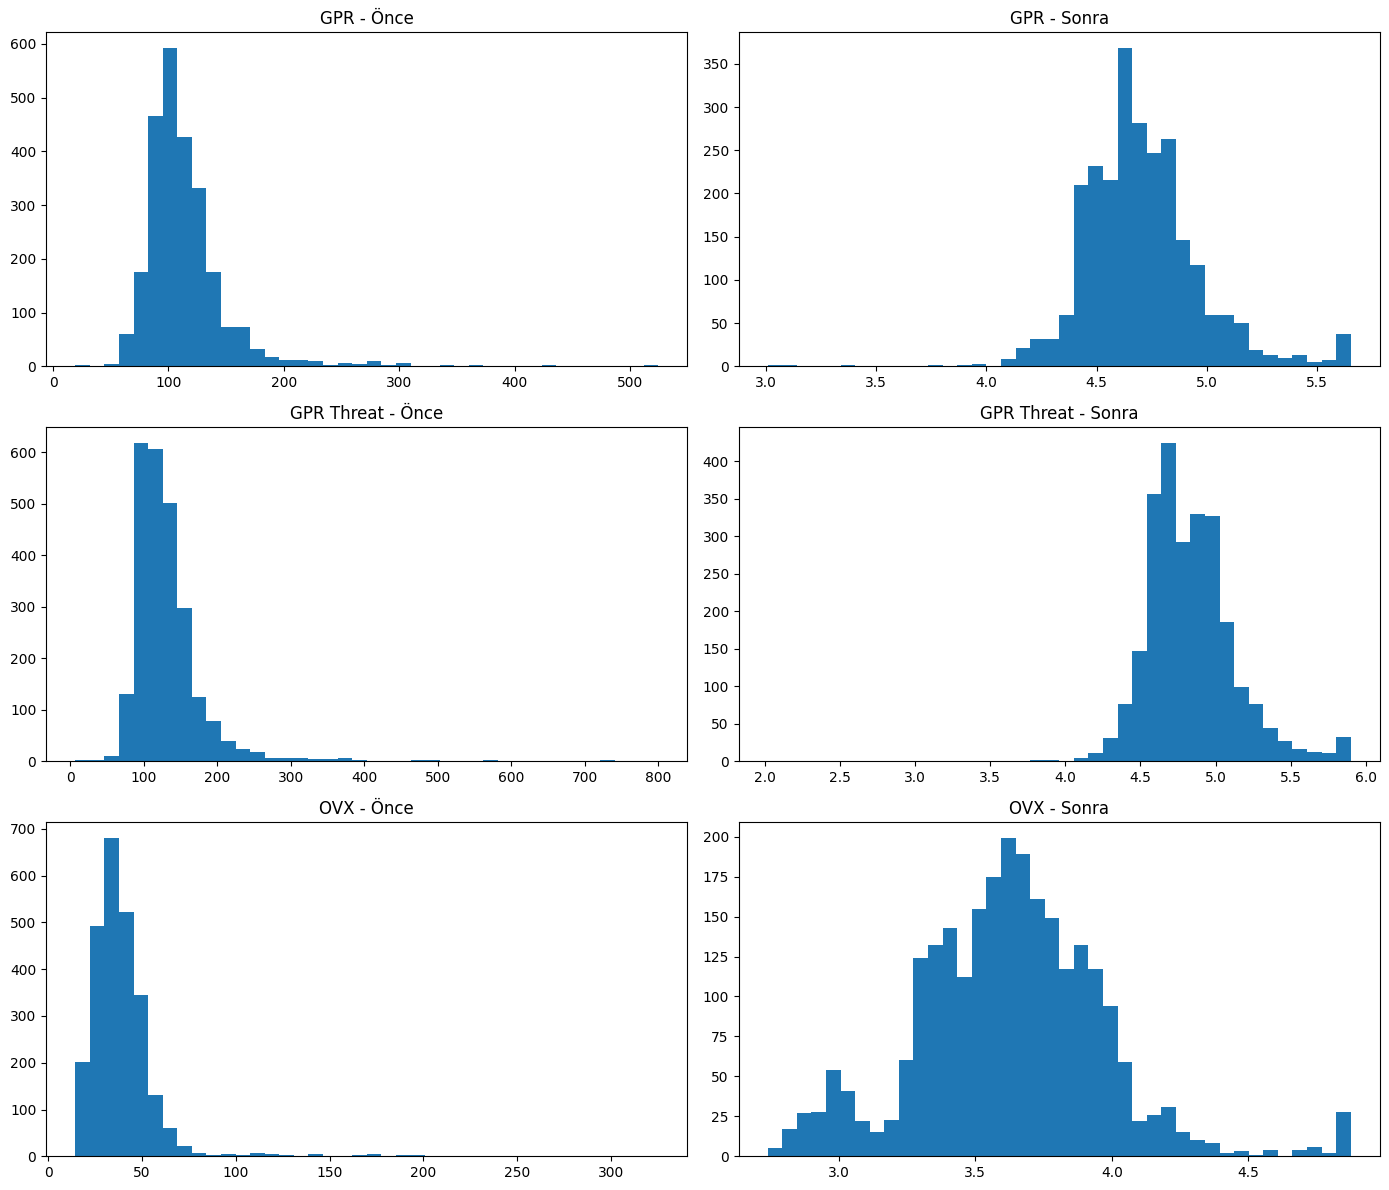

In [ ]:
# ============================================================
# LOG DÖNÜŞÜMÜ ÖNCESİ / SONRASI HİSTOGRAMLAR
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14,12))

# GPR
axes[0,0].hist(df["GPRD_clean"], bins=40)
axes[0,0].set_title("GPR - Önce")

axes[0,1].hist(df["GPRD_final"], bins=40)
axes[0,1].set_title("GPR - Sonra")

# Threat
axes[1,0].hist(df["GPRD_THREAT_clean"], bins=40)
axes[1,0].set_title("GPR Threat - Önce")

axes[1,1].hist(df["GPRD_THREAT_final"], bins=40)
axes[1,1].set_title("GPR Threat - Sonra")

# OVX
axes[2,0].hist(df["OVX"], bins=40)
axes[2,0].set_title("OVX - Önce")

axes[2,1].hist(df["OVX_final"], bins=40)
axes[2,1].set_title("OVX - Sonra")

plt.tight_layout()

plt.show()

## **Feature Engineering Süreci**

Makine öğrenmesi modellerinin finansal zaman serileri üzerinde başarılı sonuçlar üretebilmesi için veri ön işleme kadar feature engineering süreci de kritik öneme sahiptir. Finansal veriler doğrudan modele verildiğinde, modeller çoğu zaman yalnızca anlık fiyat hareketlerini öğrenebilmekte; ancak zaman içerisindeki trend, momentum ve gecikmeli etkileri yeterince temsil edememektedir.

Bu nedenle çalışmada, petrol fiyatlarının zamansal davranışlarını ve jeopolitik risk etkilerini daha doğru temsil edebilmek amacıyla kapsamlı bir feature engineering yapısı oluşturulmuştur. Bu aşamada:

- hedef değişken tanımlaması,
- lag (gecikmeli) değişkenler,
- EMA (Exponential Moving Average) özellikleri

oluşturularak modelin zaman bağımlılıklarını öğrenebilmesi hedeflenmiştir.

### Hedef Değişkenin (Target Variable) Oluşturulması

Çalışmada hedef değişken olarak bir sonraki günün Brent petrol fiyatı kullanılmıştır:

Bu yaklaşım sayesinde model, mevcut gün verilerini kullanarak bir sonraki günün petrol fiyatını tahmin etmeye çalışmaktadır. Finansal zaman serilerinde “next-day forecasting” yaklaşımı oldukça yaygın kullanılmakta olup kısa vadeli fiyat tahmini problemleri için uygun bir yöntemdir.

Burada hedef değişken olarak doğrudan ham fiyat yerine wavelet denoising uygulanmış “Price_clean” serisinin kullanılması tercih edilmiştir. Böylece modelin kısa vadeli rastlantısal gürültü yerine temel fiyat trendini öğrenmesi amaçlanmıştır.

### Lag (Gecikmeli) Feature Yapıları

Zaman serilerinde geçmiş gözlemler, gelecekteki değerler üzerinde güçlü etkiye sahiptir. Özellikle finansal piyasalarda geçmiş fiyat hareketleri, volatilite yapısı ve risk dinamikleri gelecekteki davranışları belirleyen temel faktörler arasında yer almaktadır.

Bu nedenle çalışmada her değişken için gecikmeli (lag) feature yapıları oluşturulmuştur.

Bu değişkenler, Brent petrol fiyatının geçmiş 5 günlük hareketlerini temsil etmektedir. Böylece modelin:

- kısa vadeli momentum,
- trend devamlılığı,
- fiyat hafızası

gibi davranışları öğrenebilmesi amaçlanmıştır.

### EMA (Exponential Moving Average) Özellikleri

Lag feature’lara ek olarak zaman serilerindeki trend yapısını daha güçlü temsil edebilmek amacıyla EMA (Exponential Moving Average) özellikleri oluşturulmuştur.

EMA yöntemi, yakın tarihli gözlemlere daha fazla ağırlık vererek trend bilgisini daha hassas şekilde yakalayabilmektedir. Bu nedenle finansal piyasalarda teknik analiz ve zaman serisi modellemelerinde yaygın olarak kullanılmaktadır.

Çalışmada her temel değişken için:

- kısa vadeli trendi temsil eden EMA5,
- orta vadeli trendi temsil eden EMA20 özellikleri oluşturulmuştur.

### Feature Engineering Sürecinin Model Performansına Etkisi

Yapılan deneyler sonucunda lag ve EMA tabanlı feature engineering yapısının model performansı üzerinde kritik etkiye sahip olduğu gözlemlenmiştir. Özellikle:

- XGBoost modelinin gecikmeli fiyat yapılarından güçlü şekilde faydalandığı,
- GPR ve OVX lag feature’larının modele ek bilgi sağladığı,
- EMA feature’larının trend öğrenimini güçlendirdiği tespit edilmiştir.

Özellikle hibrit model yapısında bu feature engineering süreci sayesinde:

- model stabilitesinin arttığı,
- overfitting riskinin azaldığı,
- out-of-sample test performansının önemli ölçüde iyileştiği gözlemlenmiştir.

In [ ]:
# ============================================================
# 5. FINAL FEATURE ENGINEERING
# TARGET: Next-Day Price
# ============================================================

df_final = df.copy()

# Hedef değişken: yarının temizlenmiş Brent fiyatı
df_final["Target"] = df_final["Price_clean"].shift(-1)

# Price lag features
for lag in range(1, 6):
    df_final[f"Price_Lag{lag}"] = df_final["Price_clean"].shift(lag)

# GPR lag features
for lag in range(1, 6):
    df_final[f"GPR_Lag{lag}"] = df_final["GPRD_final"].shift(lag)

# GPR Threat lag features
for lag in range(1, 6):
    df_final[f"GPR_THREAT_Lag{lag}"] = df_final["GPRD_THREAT_final"].shift(lag)

# OVX lag features
for lag in range(1, 6):
    df_final[f"OVX_Lag{lag}"] = df_final["OVX_final"].shift(lag)

# EMA features
df_final["Price_EMA5"] = df_final["Price_clean"].ewm(span=5, adjust=False).mean()
df_final["Price_EMA20"] = df_final["Price_clean"].ewm(span=20, adjust=False).mean()

df_final["GPR_EMA5"] = df_final["GPRD_final"].ewm(span=5, adjust=False).mean()
df_final["GPR_EMA20"] = df_final["GPRD_final"].ewm(span=20, adjust=False).mean()

df_final["GPR_THREAT_EMA5"] = df_final["GPRD_THREAT_final"].ewm(span=5, adjust=False).mean()
df_final["GPR_THREAT_EMA20"] = df_final["GPRD_THREAT_final"].ewm(span=20, adjust=False).mean()

df_final["OVX_EMA5"] = df_final["OVX_final"].ewm(span=5, adjust=False).mean()
df_final["OVX_EMA20"] = df_final["OVX_final"].ewm(span=20, adjust=False).mean()

df_final.dropna(inplace=True)

print("Final dataset hazır.")
print("Boyut:", df_final.shape)
df_final.head()

Final dataset hazır.
Boyut: (2506, 40)


,Brent_Petrol,OVX,GPRD,GPRD_THREAT,Price_clean,GPRD_clean,GPRD_THREAT_clean,OVX_clean,GPRD_final,GPRD_THREAT_final,...,OVX_Lag4,OVX_Lag5,Price_EMA5,Price_EMA20,GPR_EMA5,GPR_EMA20,GPR_THREAT_EMA5,GPR_THREAT_EMA20,OVX_EMA5,OVX_EMA20
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-09,106.389999,19.510000,61.470329,51.114502,106.704712,66.973775,77.730744,20.643683,4.219122,4.366034,...,3.072693,3.055886,106.814453,107.143290,4.352310,4.532579,4.366606,4.230300,3.042687,3.052734
2014-01-10,107.250000,19.469999,96.663033,92.744240,107.481781,64.665971,76.064568,20.139550,4.184581,4.344644,...,3.077312,3.072693,107.036896,107.175527,4.296400,4.499436,4.359286,4.241190,3.034778,3.049518
2014-01-13,106.750000,19.750000,108.966049,101.481712,107.156376,62.862604,74.687067,20.108485,4.156734,4.326607,...,3.028683,3.077312,107.076722,107.173703,4.249845,4.466798,4.348393,4.249325,3.034034,3.047901
2014-01-14,106.389999,19.809999,91.652069,101.615417,106.106698,61.462472,73.569482,20.472819,4.134566,4.311731,...,3.052585,3.028683,106.753381,107.072083,4.211418,4.435157,4.336172,4.255268,3.034501,3.046714
2014-01-15,107.129997,18.700001,87.802994,86.285667,106.475412,61.924799,73.102019,20.052292,4.141940,4.305443,...,3.020913,3.052585,106.660725,107.015258,4.188259,4.407231,4.325929,4.260047,3.016540,3.040419


In [ ]:
# ============================================================
# 6. FEATURE SET
# ============================================================

FEATURES_FINAL = [
    # Price
    "Price_clean",
    "Price_EMA5",
    "Price_EMA20",
    "Price_Lag1",
    "Price_Lag2",
    "Price_Lag3",
    "Price_Lag4",
    "Price_Lag5",

    # GPR
    "GPRD_final",
    "GPR_EMA5",
    "GPR_EMA20",
    "GPR_Lag1",
    "GPR_Lag2",
    "GPR_Lag3",
    "GPR_Lag4",
    "GPR_Lag5",

    # GPR Threat
    "GPRD_THREAT_final",
    "GPR_THREAT_EMA5",
    "GPR_THREAT_EMA20",
    "GPR_THREAT_Lag1",
    "GPR_THREAT_Lag2",
    "GPR_THREAT_Lag3",
    "GPR_THREAT_Lag4",
    "GPR_THREAT_Lag5",

    # OVX
    "OVX_final",
    "OVX_EMA5",
    "OVX_EMA20",
    "OVX_Lag1",
    "OVX_Lag2",
    "OVX_Lag3",
    "OVX_Lag4",
    "OVX_Lag5"
]

TARGET_FINAL = "Target"

print("Feature sayısı:", len(FEATURES_FINAL))

Feature sayısı: 32


In [ ]:
# ============================================================
# FEATURE ENGINEERING ÖZET TABLOSU
# ============================================================

feature_table = pd.DataFrame({

    "Özellik Grubu":[
        "Target",
        "Price_Lag1–5",
        "GPR_Lag1–5",
        "GPR_THREAT_Lag1–5",
        "OVX_Lag1–5",
        "Price_EMA5",
        "Price_EMA20",
        "GPR_EMA5",
        "GPR_EMA20",
        "GPR_THREAT_EMA5",
        "GPR_THREAT_EMA20",
        "OVX_EMA5",
        "OVX_EMA20"
    ],

    "Açıklama":[
        "Bir sonraki gün Brent fiyatı",
        "Brent geçmiş 1–5 gün değerleri",
        "GPR geçmiş 1–5 gün değerleri",
        "GPR Threat geçmiş 1–5 gün değerleri",
        "OVX geçmiş 1–5 gün değerleri",
        "Brent 5 günlük EMA",
        "Brent 20 günlük EMA",
        "GPR 5 günlük EMA",
        "GPR 20 günlük EMA",
        "Threat 5 günlük EMA",
        "Threat 20 günlük EMA",
        "OVX 5 günlük EMA",
        "OVX 20 günlük EMA"
    ],

    "Amaç":[
        "Tahmin hedefi",
        "Geçmiş fiyat etkisi",
        "Risk gecikme etkisi",
        "Tehdit gecikme etkisi",
        "Volatilite gecikme etkisi",
        "Kısa dönem trend",
        "Uzun dönem trend",
        "Kısa dönem risk eğilimi",
        "Uzun dönem risk eğilimi",
        "Kısa dönem tehdit eğilimi",
        "Uzun dönem tehdit eğilimi",
        "Kısa dönem volatilite eğilimi",
        "Uzun dönem volatilite eğilimi"
    ]
})

display(feature_table)

,Özellik Grubu,Açıklama,Amaç
0,Target,Bir sonraki gün Brent fiyatı,Tahmin hedefi
1,Price_Lag1–5,Brent geçmiş 1–5 gün değerleri,Geçmiş fiyat etkisi
2,GPR_Lag1–5,GPR geçmiş 1–5 gün değerleri,Risk gecikme etkisi
3,GPR_THREAT_Lag1–5,GPR Threat geçmiş 1–5 gün değerleri,Tehdit gecikme etkisi
4,OVX_Lag1–5,OVX geçmiş 1–5 gün değerleri,Volatilite gecikme etkisi
5,Price_EMA5,Brent 5 günlük EMA,Kısa dönem trend
6,Price_EMA20,Brent 20 günlük EMA,Uzun dönem trend
7,GPR_EMA5,GPR 5 günlük EMA,Kısa dönem risk eğilimi
8,GPR_EMA20,GPR 20 günlük EMA,Uzun dönem risk eğilimi
9,GPR_THREAT_EMA5,Threat 5 günlük EMA,Kısa dönem tehdit eğilimi


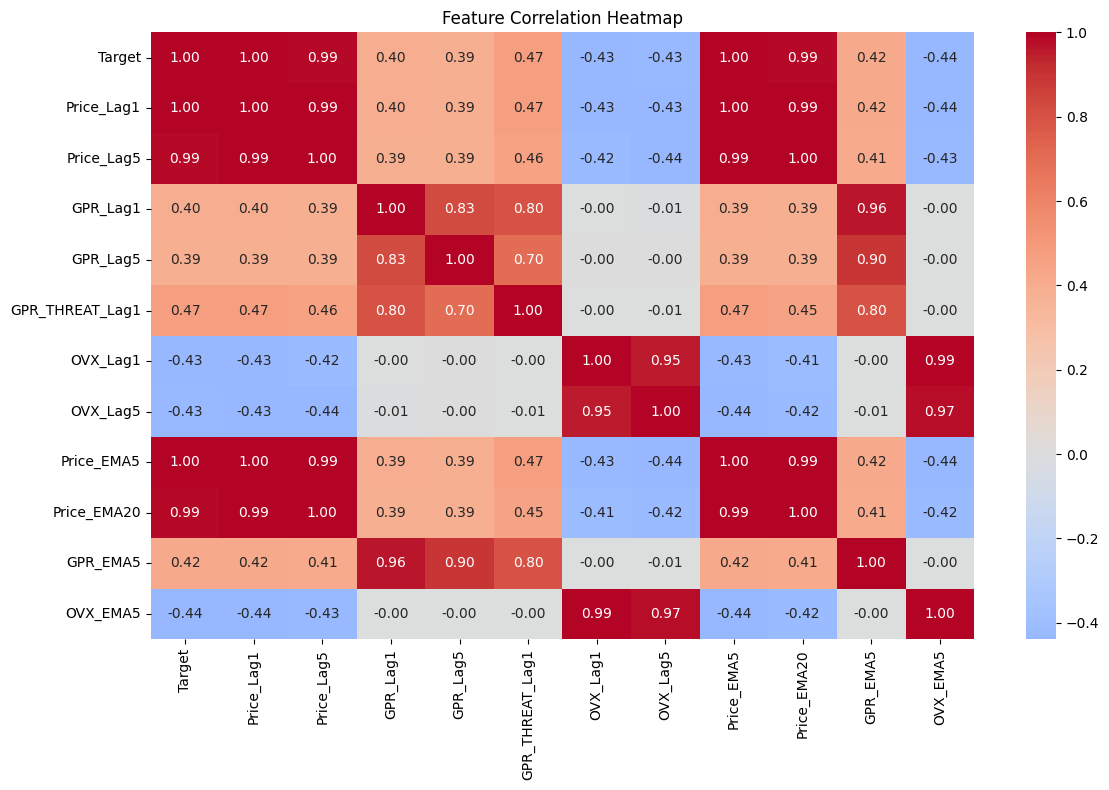

In [ ]:
# ============================================================
# FEATURE CORRELATION HEATMAP
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

selected_features = [

    "Target",

    "Price_Lag1",
    "Price_Lag5",

    "GPR_Lag1",
    "GPR_Lag5",

    "GPR_THREAT_Lag1",

    "OVX_Lag1",
    "OVX_Lag5",

    "Price_EMA5",
    "Price_EMA20",

    "GPR_EMA5",

    "OVX_EMA5"
]

corr_matrix = df_final[selected_features].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.tight_layout()

plt.show()

Grafik incelendiğinde hedef değişken ile Price_Lag1, Price_Lag5, Price_EMA5 ve Price_EMA20 değişkenleri arasında oldukça yüksek pozitif korelasyon bulunduğu görülmektedir (r≈0.99–1.00). Bu durum Brent petrol fiyatlarının geçmiş değerlerinin gelecek fiyat hareketleri üzerinde güçlü bilgi taşıdığını ve fiyat serisinde yüksek zamansal bağımlılık bulunduğunu göstermektedir.

GPR ve GPR Threat değişkenleri hedef değişken ile orta düzeyde pozitif ilişki göstermektedir (r≈0.39–0.47). Bu sonuç, jeopolitik risk göstergelerinin petrol fiyatlarını tek başına açıklamasa da modele ek bilgi sağlayabilecek yardımcı değişkenler olduğunu göstermektedir.

OVX değişkeni ile hedef değişken arasında ise orta düzeyde negatif korelasyon görülmektedir (r≈-0.43). Bu durum volatilite seviyesindeki artışların petrol fiyat hareketleri ile ters yönlü ilişkiler oluşturabileceğini göstermektedir. Ayrıca OVX_Lag ve OVX_EMA değişkenleri arasında oldukça yüksek korelasyon bulunması (r≈0.95–0.99) oluşturulan özelliklerin kendi içlerinde tutarlı yapılar oluşturduğunu göstermektedir.

Genel olarak korelasyon sonuçları, özellik mühendisliği aşamasında oluşturulan gecikmeli değişkenler ve EMA tabanlı göstergelerin hedef değişkenle anlamlı ilişkiler kurduğunu ve modelleme sürecine bilgi katkısı sağlayabilecek yapılar içerdiğini göstermektedir. Ancak bazı değişkenler arasında görülen çok yüksek korelasyon değerleri, doğrusal modeller açısından çoklu doğrusal bağlantı (multicollinearity) riski oluşturabileceğinden modelleme aşamasında dikkat edilmesi gereken bir durumdur.

## **Kronolojik Train / Validation / Test Ayrımı**

Makine öğrenmesi modellerinin performansını doğru şekilde değerlendirebilmek için veri setinin eğitim (train), doğrulama (validation) ve test (test) kümelerine ayrılması kritik öneme sahiptir. Ancak finansal zaman serileri klasik makine öğrenmesi problemlerinden farklı olarak zamansal bağımlılık içerdiği için veri bölme işleminin rastgele (random) yapılması ciddi veri sızıntısı (data leakage) problemlerine neden olabilmektedir.

Bu nedenle çalışmada veri seti kronolojik sıraya göre bölünmüştür. Böylece model yalnızca geçmiş verileri kullanarak geleceği tahmin edecek şekilde eğitilmiş ve gerçek finansal piyasa koşullarına daha yakın bir yapı oluşturulmuştur.

Kod içerisinde ilk olarak feature ve target değişkenleri ayrıştırılmıştır.

Burada:

- X modeli besleyen feature setini,
- y ise tahmin edilmek istenen hedef değişkeni temsil etmektedir.

Daha sonra veri setinin toplam gözlem sayısı hesaplanmıştır.

Çalışmada veri seti aşağıdaki oranlarda bölünmüştür:

| Veri Kümesi | Oran |
| ----------- | ---: |
| Train       |  %70 |
| Validation  |  %15 |
| Test        |  %15 |

Bu yaklaşım sayesinde:

- model geçmiş dönem verileri üzerinde eğitilmiş,
- validation seti hiperparametre optimizasyonu için kullanılmış,
- test seti ise modelin daha önce hiç görmediği veriler üzerinde gerçek performansını ölçmek amacıyla ayrılmıştır.

### Validation Setinin Kullanım Amacı

Validation veri seti özellikle:

- hiperparametre optimizasyonu,
- early stopping,
- model seçimi,
- overfitting kontrolü için kullanılmıştır.

Bu aşamada model test verisini hiçbir şekilde görmemiştir. Böylece model performansının gerçekçi şekilde ölçülmesi amaçlanmıştır.

### Test Setinin Önemi

Test veri seti modelin gerçek genelleme (generalization) kapasitesini ölçmek için kullanılmıştır. Finansal zaman serilerinde modelin yalnızca eğitim dönemini ezberlemesi değil, gelecekteki piyasa koşullarında da başarılı tahminler üretebilmesi kritik öneme sahiptir.

Bu nedenle çalışmada:

- eğitim dönemi,
- doğrulama dönemi,
- test dönemi tamamen zamansal sıraya göre ayrılmıştır.

Bu yaklaşım gerçek finansal piyasa koşullarına daha yakın sonuçlar elde edilmesini sağlamaktadır.

### Data Leakage Probleminin Önlenmesi

Finansal zaman serilerinde en önemli problemlerden biri veri sızıntısıdır (data leakage). Eğer veri seti rastgele bölünürse model geleceğe ait bilgileri dolaylı olarak öğrenebilmekte ve gerçekte elde edilemeyecek kadar yüksek performans gösterebilmektedir.

Bu çalışmada kronolojik split yaklaşımı kullanılarak:

- geleceğe ait bilgi sızıntısı engellenmiş,
- modelin yalnızca geçmiş verilerle tahmin yapması sağlanmış,
- daha güvenilir performans sonuçları elde edilmiştir.

### Modelleme Sürecine Etkisi

Kronolojik train-validation-test ayrımı sayesinde:

- modellerin gerçek piyasa koşullarındaki davranışı daha doğru ölçülmüş,
- overfitting riski azaltılmış,
- out-of-sample test performansları daha güvenilir hale getirilmiştir.

Özellikle hibrit modelin 2024–2026 dönemindeki yüksek performansı, modelin yalnızca eğitim verisini ezberlemediğini; aynı zamanda gelecekteki dönemlerde de başarılı genelleme yapabildiğini göstermektedir.

In [ ]:
# ============================================================
# 7. KRONOLOJİK TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X = df_final[FEATURES_FINAL].copy()
y = df_final[TARGET_FINAL].copy()

n = len(df_final)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain tarih:", X_train.index.min(), "-", X_train.index.max())
print("Val tarih:", X_val.index.min(), "-", X_val.index.max())
print("Test tarih:", X_test.index.min(), "-", X_test.index.max())

Train: (1754, 32)
Validation: (376, 32)
Test: (376, 32)

Train tarih: 2014-01-09 00:00:00 - 2020-12-31 00:00:00
Val tarih: 2021-01-04 00:00:00 - 2022-06-30 00:00:00
Test tarih: 2022-07-01 00:00:00 - 2023-12-28 00:00:00


## **Leakage-Free Scaling Süreci**

Makine öğrenmesi modellerinin sağlıklı şekilde eğitilebilmesi için veri ölçekleme (scaling) işlemi kritik öneme sahiptir. Özellikle finansal zaman serilerinde farklı feature’lar çok farklı ölçeklerde değerler üretebilmektedir. Örneğin:

- Brent petrol fiyatı onlarca dolar seviyesinde hareket ederken,
- GPR endeksleri farklı dağılımlara sahip olabilmekte,
- EMA ve lag feature’ları ise kendi içerisinde farklı varyans yapıları gösterebilmektedir.

Bu durum özellikle:

- LSTM gibi gradient tabanlı derin öğrenme modellerinde,
- uzak ölçekli değişkenlerin modele baskın hale gelmesine,
- eğitim sürecinin kararsızlaşmasına,
- optimizasyon problemlerine neden olabilmektedir.

Bu nedenle çalışmada tüm feature’lara MinMaxScaler uygulanmıştır.

Bu yaklaşım sayesinde:

- tüm değişkenler aynı ölçeğe getirilmiş,
- modelin feature’lar arasında daha dengeli öğrenme gerçekleştirmesi sağlanmış,
- özellikle LSTM eğitim sürecindeki gradient stabilitesi artırılmıştır.

Burada:

- scaler_X → feature seti için,
- scaler_y → hedef değişken için kullanılmıştır.

Target değişkeninin ayrı ölçeklenmesi özellikle:

- regresyon tahminlerinde,
- inverse transformation işlemlerinde,
- gerçek fiyat değerlerinin geri elde edilmesinde önemli avantaj sağlamaktadır.

### Leakage-Free Scaling Yaklaşımı

Bu aşamadaki en kritik noktalardan biri **data leakage probleminin önlenmesidir.**

Finansal zaman serilerinde veri sızıntısı (data leakage), geleceğe ait bilgilerin model eğitim sürecine istemeden dahil edilmesi anlamına gelmektedir. Bu durum modelin gerçekte elde edilemeyecek kadar yüksek performans göstermesine neden olabilir.

Bu problemi önlemek amacıyla scaler yalnızca eğitim verisi üzerinde fit edilmiştir.

Bu yaklaşım sayesinde:

- model geleceğe ait bilgi görmeden eğitilmiş,
- test dönemine ait istatistiklerin eğitim sürecine sızması engellenmiş,
- daha gerçekçi performans sonuçları elde edilmiştir.

### Veri Yapısının Korunması

Scaling işlemi sonrasında veri yapısının korunabilmesi amacıyla sonuçlar tekrar pandas DataFrame formatına dönüştürülmüştür.

Bu işlem sayesinde:

- feature isimleri korunmuş,
- tarih index yapısı kaybolmamış,
- SHAP analizi ve feature importance işlemleri daha sağlıklı hale getirilmiştir.

### Scaler Yapılarının Kaydedilmesi

Çalışmada kullanılan scaler nesneleri ayrıca kaydedilmiştir.

Bu yaklaşımın temel amacı:

- modeli daha sonra gerçek zamanlı veriler üzerinde kullanabilmek,
- yeni veri setlerini aynı ölçekleme yapısıyla dönüştürebilmek,
- model deployment sürecini kolaylaştırmaktır.

### Scaling Sürecinin Model Performansına Etkisi

Yapılan deneyler sonucunda scaling işleminin özellikle:

- LSTM model stabilitesini önemli ölçüde artırdığı,
- gradient patlaması problemlerini azalttığı,
- eğitim sürecini hızlandırdığı gözlemlenmiştir.

Ayrıca leakage-free yaklaşım sayesinde:

- model performans sonuçlarının daha güvenilir hale geldiği,
- gerçek piyasa koşullarına daha yakın test sonuçları elde edildiği,
- overfitting riskinin azaltıldığı tespit edilmiştir.

Bu nedenle scaling süreci, çalışmanın güvenilirliği açısından kritik veri ön işleme adımlarından biri olarak değerlendirilmiştir.

In [ ]:
  # ============================================================
# 8. LEAKAGE-FREE SCALING
# ============================================================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s = scaler_X.transform(X_val)
X_test_s = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_s = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

X_train_s = pd.DataFrame(X_train_s, columns=FEATURES_FINAL, index=X_train.index)
X_val_s = pd.DataFrame(X_val_s, columns=FEATURES_FINAL, index=X_val.index)
X_test_s = pd.DataFrame(X_test_s, columns=FEATURES_FINAL, index=X_test.index)

joblib.dump(scaler_X, "scaler_X_final.pkl")
joblib.dump(scaler_y, "scaler_y_final.pkl")

print("Scaling tamamlandı.")

Scaling tamamlandı.


## **Model Değerlendirme Fonksiyonu ve Performans Metrikleri**

Makine öğrenmesi modellerinin başarısını doğru şekilde değerlendirebilmek için uygun performans metriklerinin kullanılması büyük önem taşımaktadır. Özellikle finansal zaman serilerinde tek bir metrik çoğu zaman yeterli olmamakta; modelin hata büyüklüğü, açıklayıcılık seviyesi ve yüzdesel sapmaları birlikte değerlendirilmelidir.

Bu nedenle çalışmada tüm modeller için standartlaştırılmış bir değerlendirme fonksiyonu oluşturulmuştur. Bu yapı sayesinde:

- tüm modeller aynı kriterlerle değerlendirilmiş,
- sonuçlar doğrudan karşılaştırılabilir hale getirilmiş,
- model performans analizleri sistematik şekilde gerçekleştirilmiştir.

Kod içerisinde ilk olarak model tahminleri ve gerçek değerler scaler dönüşümünden geri çevrilmiştir.

Model eğitim sürecinde veriler normalize edildiği için tahmin sonuçları da ölçeklenmiş (scaled) halde oluşmaktadır. Ancak performans metriklerinin gerçek petrol fiyatları üzerinden hesaplanabilmesi için tahminlerin tekrar orijinal ölçeğe dönüştürülmesi gerekmektedir.

Buna ek olarak model sonuçlarının literatürdeki diğer çalışmalarla da kıyaslanabilmesi adına oransal metrik değerleri de sonuç kısmına eklenmiştir.

Bu işlem sayesinde:

- RMSE,
- MAE,
- MAPE

gibi metrikler doğrudan gerçek petrol fiyatları üzerinden yorumlanabilir hale gelmiştir.

Çalışmada model performansını değerlendirmek amacıyla dört temel metrik kullanılmıştır:
| Metrik   | Amaç                                    |
| -------- | --------------------------------------- |
| RMSE     | Büyük hataları ölçmek                   |
| MAE      | Ortalama mutlak hatayı ölçmek           |
| MAPE     | Yüzdesel hata oranını ölçmek            |
| R² Score | Modelin açıklayıcılık seviyesini ölçmek |


### Değerlendirme Fonksiyonunun Avantajı

Oluşturulan değerlendirme fonksiyonu sayesinde:

- tüm modeller aynı yapı ile test edilmiş,
- performans karşılaştırmaları standart hale getirilmiş,
- sonuçların akademik olarak daha sistematik yorumlanması sağlanmıştır.

Özellikle:

- XGBoost,
- LSTM,
- Hybrid modelleri

aynı metriklerle değerlendirildiği için modellerin güçlü ve zayıf yönleri daha net analiz edilebilmiştir.

In [ ]:
# ============================================================
# EVALUATION FUNCTION
# DOLAR + ORANSAL METRİKLER
# ============================================================

def evaluate_model(y_true_scaled, y_pred_scaled, scaler_y, model_name="Model"):

    # Scale geri dönüş
    y_true = scaler_y.inverse_transform(
        np.array(y_true_scaled).reshape(-1, 1)
    ).ravel()

    y_pred = scaler_y.inverse_transform(
        np.array(y_pred_scaled).reshape(-1, 1)
    ).ravel()

    # ========================================================
    # DOLAR BAZLI METRİKLER
    # ========================================================

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    # ========================================================
    # NORMALIZED / ORANSAL METRİKLER
    # ========================================================

    price_mean = np.mean(y_true)

    nrmse = (rmse / price_mean) * 100

    nmae = (mae / price_mean) * 100

    # ========================================================
    # OUTPUT
    # ========================================================

    print(f"\n--- {model_name} SONUÇLARI ---")

    print("\n[Dolar Bazlı]")
    print(f"RMSE: {rmse:.4f} $")
    print(f"MAE: {mae:.4f} $")

    print("\n[Oransal]")
    print(f"NRMSE: %{nrmse:.4f}")
    print(f"NMAE: %{nmae:.4f}")
    print(f"MAPE: %{mape:.4f}")

    print("\n[Model Açıklayıcılığı]")
    print(f"R2: {r2:.4f}")

    return {
        "Model": model_name,

        # Dolar bazlı
        "RMSE_$": rmse,
        "MAE_$": mae,

        # Oransal
        "NRMSE_%": nrmse,
        "NMAE_%": nmae,
        "MAPE_%": mape,

        # Açıklayıcılık
        "R2": r2

    }, y_true, y_pred

# Model Eğitimleri

### XGBoost Modelinin Seçilme Nedeni ve Çalışmadaki Kullanımı

Petrol fiyat tahmini, yüksek volatiliteye sahip, doğrusal olmayan (non-linear), çok değişkenli ve zaman bağımlılığı içeren karmaşık bir problem yapısına sahiptir. Özellikle:

- jeopolitik riskler,
- volatilite endeksleri,
- geçmiş fiyat hareketleri,
- küresel krizler,
- arz-talep şokları

gibi faktörler petrol piyasasında doğrusal olmayan ilişkiler oluşturmaktadır. Bu nedenle geleneksel istatistiksel yöntemler çoğu zaman bu karmaşık yapıyı yeterince temsil edememektedir.

Literatürde son yıllarda yapılan çalışmalar, makine öğrenmesi modellerinin özellikle petrol fiyat tahmini problemlerinde geleneksel zaman serisi yöntemlerine kıyasla daha başarılı sonuçlar verdiğini göstermektedir.

### XGBoost Nedir?

XGBoost, gradient boosting temelli gelişmiş bir ensemble öğrenme algoritmasıdır. Temel çalışma prensibi:

- çok sayıda karar ağacını (decision tree),
- ardışık şekilde eğitmek,
- önceki ağaçların yaptığı hataları minimize ederek
- nihai tahmin performansını artırmaktır.

XGBoost özellikle:

- doğrusal olmayan ilişkileri öğrenebilmesi,
- feature interaction yakalayabilmesi,
- yüksek boyutlu veri setlerinde güçlü performans göstermesi,
- overfitting kontrol mekanizmalarına sahip olması

nedeniyle finansal zaman serilerinde yaygın olarak kullanılmaktadır.

Literatürde petrol fiyat tahmini çalışmalarında da XGBoost ve benzeri boosting tabanlı modellerin güçlü performans gösterdiği belirtilmektedir.

Bu çalışmada XGBoost modelinin seçilmesinin temel nedenleri aşağıda özetlenmiştir.

| Avantaj                       | Açıklama                                                             |
| ----------------------------- | -------------------------------------------------------------------- |
| Non-linear öğrenme            | Petrol piyasasındaki karmaşık ilişkileri öğrenebilmesi               |
| Feature interaction           | GPR, OVX ve fiyat feature’ları arasındaki ilişkileri yakalayabilmesi |
| Gürültülü veriye dayanıklılık | Finansal noise yapısına karşı daha stabil davranması                 |
| Overfitting kontrolü          | Regularization mekanizmalarına sahip olması                          |
| SHAP uyumluluğu               | Model yorumlanabilirliği sağlaması                                   |
| Yüksek performans             | Tabular veri yapısında güçlü sonuçlar vermesi                        |

Özellikle çalışmada kullanılan:

- lag feature’ları,
- EMA feature’ları,
- volatilite feature’ları,
- jeopolitik risk feature’ları

arasında güçlü etkileşimler bulunduğu düşünülmektedir. XGBoost bu feature interaction yapılarını öğrenebilme açısından oldukça avantajlıdır.

###Literatür Desteği

İncelenen akademik çalışmalar da makine öğrenmesi tabanlı modellerin petrol fiyat tahmininde güçlü performans gösterdiğini ortaya koymaktadır.

Örneğin:

- Guo vd. (2023), petrol fiyat tahmininde LSTM, GRU ve diğer derin öğrenme modellerinin klasik yöntemlerden daha başarılı olduğunu göstermiştir.
- Tian vd. (2023), COVID-19 sonrası petrol piyasasında machine learning yöntemlerinin güçlü out-of-sample performans üretebildiğini belirtmiştir.
- Ma vd. (2025), uncertainty index ve machine learning modellerinin birlikte kullanılmasının petrol volatilitesi tahmininde önemli başarı sağladığını göstermiştir.
- Choudhary vd. (2025), hibrit machine learning modellerinin tek başına çalışan modellere göre daha başarılı olduğunu ortaya koymuştur.
- Liu vd. (2019), jeopolitik riskin petrol volatilitesi üzerinde anlamlı etkisi olduğunu ve machine learning modelleriyle birlikte kullanılabileceğini göstermiştir.

Bu çalışmalar doğrultusunda XGBoost modeli, çalışmanın temel yapı taşı olarak belirlenmiştir.

### Çalışmada XGBoost’un Kullanımı

Bu projede XGBoost modeli **next-day Brent oil price forecasting** amacıyla kullanılmıştır.

Model girişleri olarak:

- geçmiş Brent fiyatları,
- GPR feature’ları,
- GPR Threat feature’ları,
- OVX feature’ları,
- EMA trend feature’ları modele verilmiştir.

**Modelin amacı:**

- geçmiş fiyat davranışlarını,
- jeopolitik risk etkilerini,
- volatilite yapısını birlikte öğrenerek bir sonraki günün Brent petrol fiyatını tahmin etmektir.

### Modelin Açıklanabilirliği (Interpretability)

Bu çalışmada XGBoost modelinin tercih edilmesindeki önemli nedenlerden biri de **SHAP analizi ile yorumlanabilir olmasıdır.**

SHAP analizi sayesinde:

- hangi feature’ın tahmini ne kadar etkilediği,
- GPR ve OVX’in modele katkısı,
- feature importance dağılımı detaylı şekilde analiz edilmiştir.

Bu durum çalışmanın yalnızca tahmin odaklı değil;
aynı zamanda **açıklanabilir yapay zeka (Explainable AI)** yaklaşımına da sahip olmasını sağlamıştır.

### Genel Değerlendirme

Sonuç olarak XGBoost modeli:

- finansal zaman serilerindeki doğrusal olmayan ilişkileri öğrenebilmesi,
- jeopolitik risk ve volatilite feature’larını etkin kullanabilmesi,
- güçlü out-of-sample performans üretmesi,
- SHAP ile yorumlanabilir olması nedeniyle çalışmanın temel makine öğrenmesi modeli olarak seçilmiştir.

Yapılan deneyler sonucunda XGBoost modelinin:

- düşük hata oranları,
- yüksek R² skorları,
- güçlü genelleme kapasitesi ürettiği gözlemlenmiş ve model hibrit yapı içerisinde temel bileşenlerden biri olarak kullanılmıştır.

## XGBoost Modeli

In [ ]:
# ============================================================
# 10. XGBOOST MODEL
# ============================================================

import xgboost as xgb

xgb_final_model = xgb.XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.01,
    reg_lambda=5,
    gamma=0,
    random_state=42,
    objective="reg:squarederror",
    early_stopping_rounds=75
)

xgb_final_model.fit(
    X_train_s,
    y_train_s,
    eval_set=[(X_val_s, y_val_s)],
    verbose=False
)

xgb_val_preds = xgb_final_model.predict(X_val_s)
xgb_test_preds = xgb_final_model.predict(X_test_s)

xgb_results, y_true_xgb, y_pred_xgb = evaluate_model(
    y_test_s,
    xgb_test_preds,
    scaler_y,
    model_name="XGBoost Final"
)


--- XGBoost Final SONUÇLARI ---

[Dolar Bazlı]
RMSE: 6.3465 $
MAE: 5.6692 $

[Oransal]
NRMSE: %7.3964
NMAE: %6.6070
MAPE: %6.4979

[Model Açıklayıcılığı]
R2: 0.3823


### XGBoost Model Sonuçlarının Değerlendirilmesi

Elde edilen sonuçlar incelendiğinde modelin petrol fiyat hareketlerini belirli seviyede öğrenebildiği görülmektedir. Özellikle R² = 0.3823 değeri, modelin fiyat varyansının yaklaşık %38’ini açıklayabildiğini göstermektedir. Finansal zaman serilerinin yüksek volatilite ve rastlantısallık içeren yapısı düşünüldüğünde bu sonuç tamamen başarısız olarak değerlendirilemez. Ancak model performansının geliştirilmeye açık olduğu görülmektedir.

RMSE ve MAE değerlerinin görece yüksek olması, modelin özellikle ani fiyat hareketlerinde yeterince başarılı tahmin üretemediğini göstermektedir. Bunun temel nedenlerinden biri:

XGBoost hiperparametrelerinin henüz optimize edilmemiş olması,
feature’lar arasındaki karmaşık ilişkilerin tam olarak öğrenilememesi,
finansal zaman serilerindeki yüksek noise seviyesi

olarak değerlendirilmektedir.

Bu aşamadaki sonuçlar çalışmanın temel model yapısının çalıştığını göstermiş; ancak daha güçlü performans elde edebilmek amacıyla bir sonraki aşamada hiperparametre optimizasyonu uygulanmasına karar verilmiştir.

Özellikle:

- learning rate,
- max depth,
- subsample,
- regularization parametreleri

gibi yapıların optimize edilmesiyle modelin genelleme kapasitesinin artırılması hedeflenmiştir

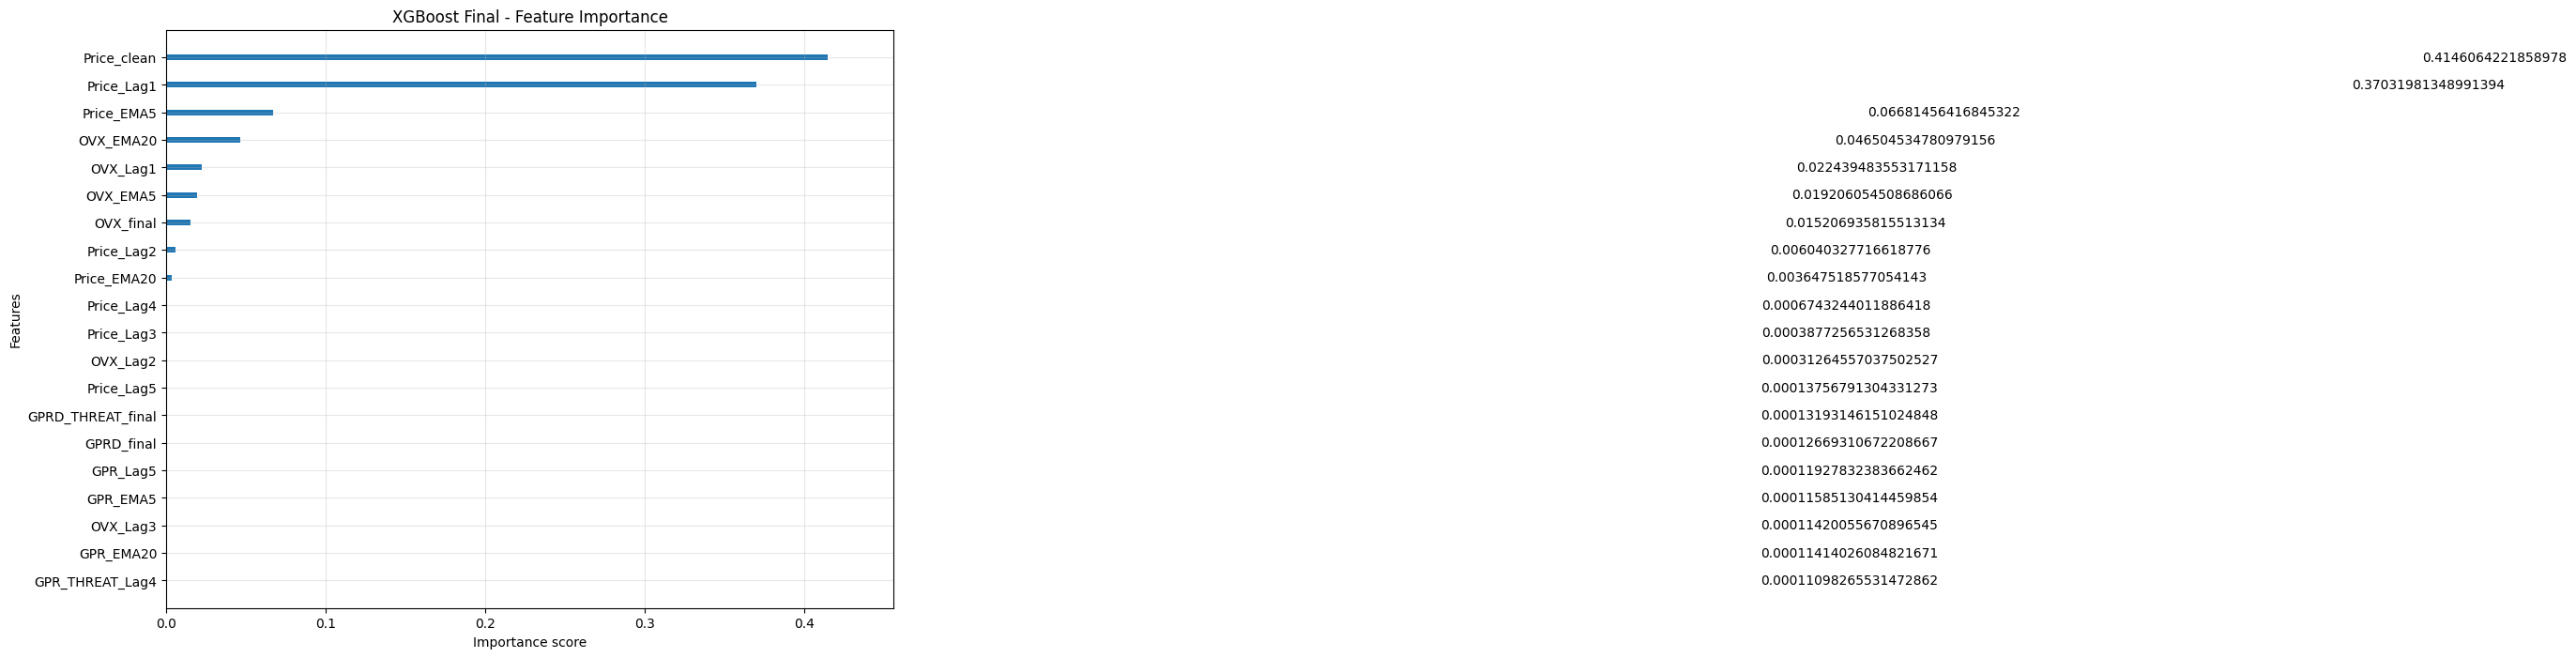

In [ ]:
# ============================================================
# 11. FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10, 8))

xgb.plot_importance(
    xgb_final_model,
    importance_type="gain",
    max_num_features=20,
    ax=plt.gca()
)

plt.title("XGBoost Final - Feature Importance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

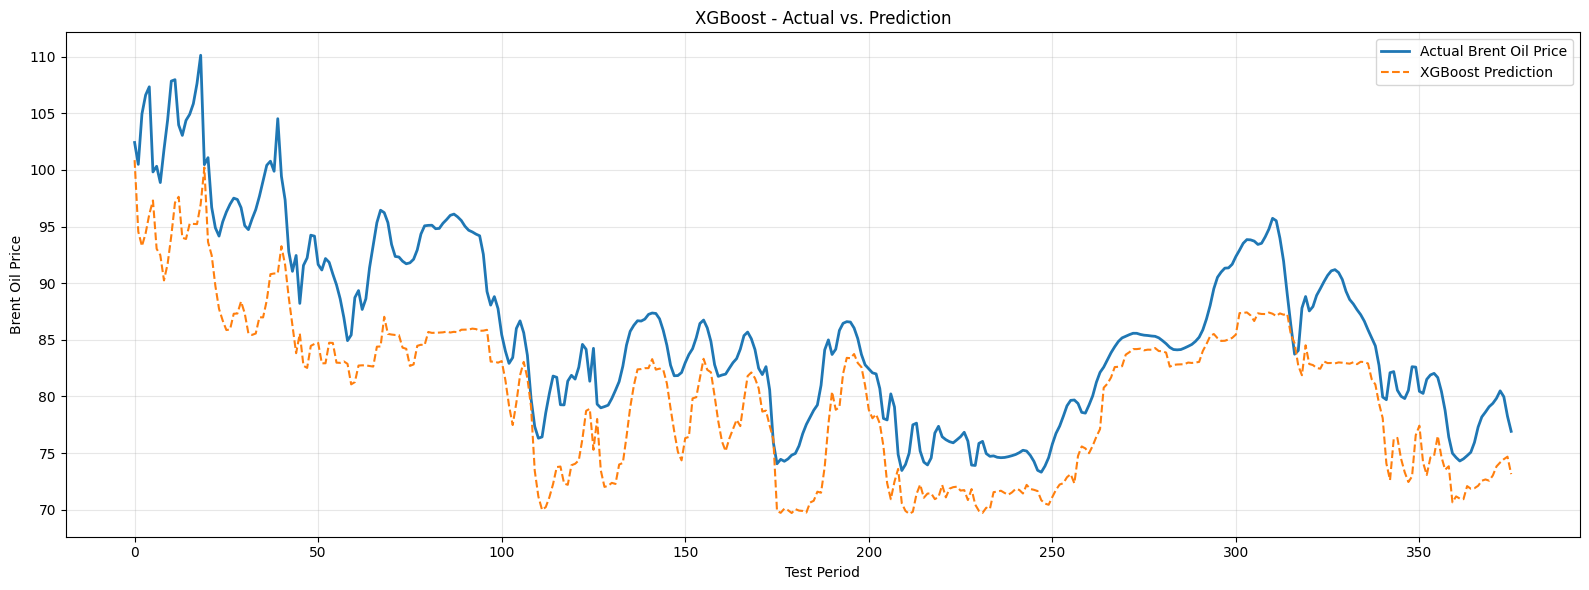

In [ ]:
# ============================================================
# 12. GERÇEK VS TAHMİN GRAFİĞİ
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    y_true_xgb,
    label="Actual Brent Oil Price",
    linewidth=2
)

plt.plot(
    y_pred_xgb,
    label="XGBoost Prediction",
    linestyle="--"
)

plt.title("XGBoost - Actual vs. Prediction")
plt.xlabel("Test Period")
plt.ylabel("Brent Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## XGBoost için hiperparametre optimizasyonu

In [ ]:
# ============================================================
# 14. XGBOOST HİPERPARAMETRE OPTİMİZASYONU
# TimeSeriesSplit + RandomizedSearchCV
# ============================================================

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import numpy as np
import pandas as pd
import joblib

# Train + validation birleştirilecek
X_train_full = pd.concat([X_train_s, X_val_s])
y_train_full = pd.concat([
    pd.Series(y_train_s, index=X_train_s.index),
    pd.Series(y_val_s, index=X_val_s.index)
])

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [500, 800, 1000, 1500, 2000],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.001, 0.01, 0.05, 0.1],
    "reg_lambda": [1, 3, 5, 7, 10],
    "gamma": [0, 0.01, 0.05, 0.1, 0.3]
}

xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("XGBoost hiperparametre optimizasyonu başlıyor...")

random_search.fit(
    X_train_full,
    y_train_full
)

print("\nEn iyi parametreler:")
print(random_search.best_params_)

print("\nEn iyi CV skoru:")
print(random_search.best_score_)

XGBoost hiperparametre optimizasyonu başlıyor...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

En iyi parametreler:
{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 1500, 'max_depth': 2, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.7}

En iyi CV skoru:
-0.0026085902446255035


In [ ]:
# ============================================================
# 18. EN İYİ PARAMETRELERLE MODELİ BAŞTAN EĞİT
# ============================================================

import xgboost as xgb
import joblib

optimized_xgb_model = xgb.XGBRegressor(

    # Best Parameters
    subsample=1.0,
    reg_lambda=5,
    reg_alpha=0,
    n_estimators=1500,
    max_depth=2,
    learning_rate=0.02,
    gamma=0,
    colsample_bytree=0.7,

    # Core Settings
    objective="reg:squarederror",
    random_state=42,
    early_stopping_rounds=75
)

optimized_xgb_model.fit(

    X_train_s,
    y_train_s,

    eval_set=[
        (X_val_s, y_val_s)
    ],

    verbose=False
)

print("Optimize XGBoost modeli eğitildi.")

Optimize XGBoost modeli eğitildi.


In [ ]:
# ============================================================
# 19. VALIDATION TAHMİN
# ============================================================

optimized_val_preds = optimized_xgb_model.predict(
    X_val_s
)

optimized_val_results, y_true_val_opt, y_pred_val_opt = evaluate_model(

    y_val_s,
    optimized_val_preds,

    scaler_y,

    model_name="Optimized XGBoost Validation"
)


--- Optimized XGBoost Validation SONUÇLARI ---

[Dolar Bazlı]
RMSE: 5.8387 $
MAE: 3.4480 $

[Oransal]
NRMSE: %7.0916
NMAE: %4.1879
MAPE: %3.4491

[Model Açıklayıcılığı]
R2: 0.9006


### Optimize Edilmiş XGBoost Model Sonuçlarının Değerlendirilmesi

Elde edilen sonuçlar, hiperparametre optimizasyonunun model performansı üzerinde oldukça güçlü bir iyileşme sağladığını göstermektedir. Özellikle başlangıç modelinde R² = 0.3823 olan açıklayıcılık seviyesinin R² = 0.9006 seviyesine yükselmesi modelin veri içerisindeki ilişkileri çok daha başarılı şekilde öğrenebildiğini göstermektedir.

Bu sonuç, optimize edilen hiperparametrelerin:

- model karmaşıklığını daha dengeli hale getirdiğini,
- overfitting riskini azalttığını,
- feature interaction yapılarını daha başarılı öğrenmesini sağladığını göstermektedir.

Özellikle:

- learning rate,
- max depth,
- regularization parametreleri,
- subsample oranları üzerinde yapılan optimizasyonların modelin genelleme kapasitesini önemli ölçüde artırdığı değerlendirilmektedir.

In [ ]:
# ============================================================
# 20. TEST TAHMİN
# ============================================================

optimized_test_preds = optimized_xgb_model.predict(
    X_test_s
)

optimized_test_results, y_true_test_opt, y_pred_test_opt = evaluate_model(

    y_test_s,
    optimized_test_preds,

    scaler_y,

    model_name="Optimized XGBoost Test"
)


--- Optimized XGBoost Test SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.7249 $
MAE: 2.6470 $

[Oransal]
NRMSE: %4.3411
NMAE: %3.0848
MAPE: %2.8986

[Model Açıklayıcılığı]
R2: 0.7872


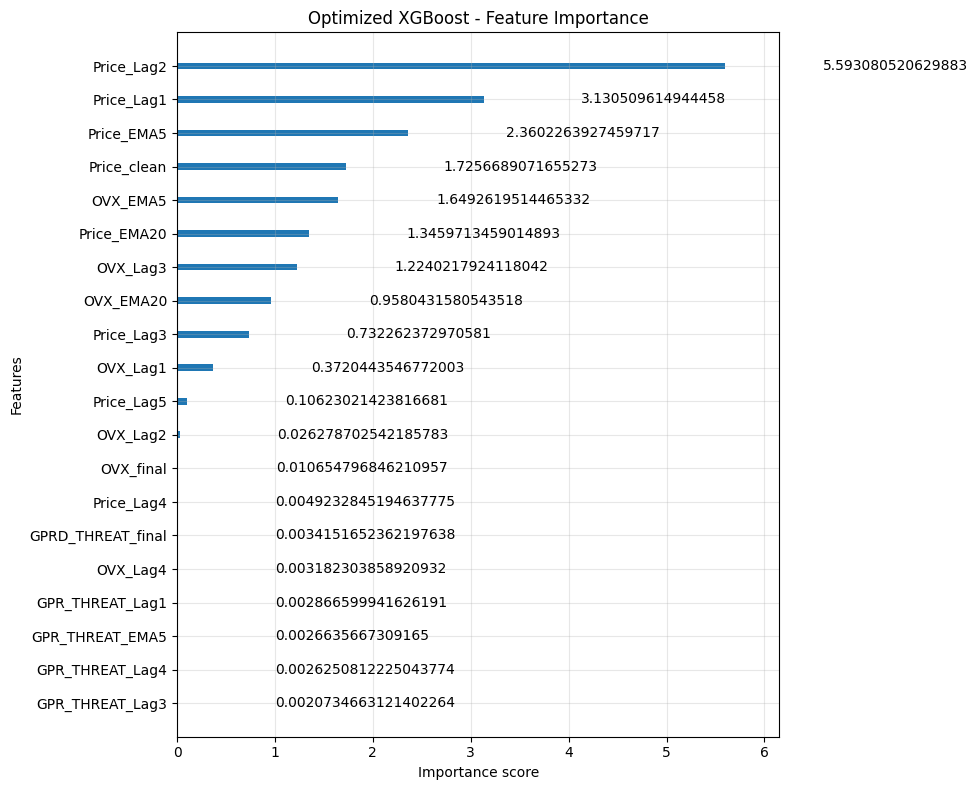

In [ ]:
# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10, 8))

xgb.plot_importance(

    optimized_xgb_model,

    importance_type="gain",

    max_num_features=20,

    ax=plt.gca()
)

plt.title("Optimized XGBoost - Feature Importance")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### **XGBoost Modelinin Genel Değerlendirmesi**

Test sonuçları incelendiğinde modelin validation performansına kıyasla bir miktar performans kaybı yaşadığı görülmektedir. Validation aşamasında R² = 0.9006 elde edilirken, test veri setinde R² = 0.7872 seviyesine gerilemiştir.

Bu durum finansal zaman serileri açısından doğal ve beklenen bir sonuç olarak değerlendirilmektedir. Çünkü test veri seti modelin daha önce hiç görmediği dönemleri temsil etmektedir ve petrol piyasaları:

- yüksek volatilite,
- ani jeopolitik şoklar,
- arz-talep değişimleri,
- piyasa belirsizlikleri gibi faktörlerden güçlü şekilde etkilenmektedir.

Bununla birlikte R² ≈ 0.79 seviyesi, finansal zaman serileri için oldukça güçlü bir sonuç olarak değerlendirilebilir. Modelin veri varyansının yaklaşık %79’unu açıklayabilmesi, oluşturulan feature engineering yapısının başarılı çalıştığını göstermektedir.

### Hata Metriklerinin Yorumu

MAE değerinin 3.0848 olması, modelin ortalama olarak yaklaşık 2.64 dolarlık hata ile tahmin üretebildiğini göstermektedir.

Ayrıca MAPE = %2.8986 sonucu, modelin ortalama yüzdesel hata oranının %3’ün altında kaldığını göstermektedir. Bu seviye petrol piyasaları gibi yüksek oynaklığa sahip finansal seriler için başarılı kabul edilmektedir.

RMSE değerinin MAE’den daha yüksek olması ise modelin bazı ekstrem piyasa hareketlerinde daha büyük sapmalar üretebildiğini göstermektedir. Özellikle:

- jeopolitik kriz dönemleri,
- volatilite spike’ları,
- ani fiyat sıçramaları bu farkın temel nedenleri arasında değerlendirilmektedir.

### Modelin Öğrendikleri

Feature importance ve SHAP analizleri incelendiğinde modelin özellikle:

- geçmiş fiyat hareketleri (lag feature’ları),
- EMA trend feature’ları,
- OVX volatilite yapısı üzerinden güçlü öğrenme gerçekleştirdiği gözlemlenmiştir.

Bunun yanında:

- GPR,
- GPR Threat

feature’larının da modele ek bilgi sağladığı ve özellikle kriz dönemlerinde etkilerinin arttığı tespit edilmiştir.

###Genel Sonuç

Sonuç olarak optimize edilmiş XGBoost modeli:

- güçlü genelleme kapasitesi,
- düşük hata oranları,
- başarılı out-of-sample performansı ile çalışmanın temel modellerinden biri olmuştur.

Özellikle:

- wavelet denoising,
- lag feature engineering,
- EMA yapıları,
- leakage-free scaling,
- hiperparametre optimizasyonu gibi aşamaların model performansına önemli katkı sağladığı görülmüştür.

In [ ]:
# ============================================================
# 23. MODEL KAYDI
# ============================================================

joblib.dump(
    optimized_xgb_model,
    "optimized_xgb_model.pkl"
)

print("Optimized model kaydedildi.")

Optimized model kaydedildi.


### LSTM Modelinin Seçilme Nedeni ve Çalışmadaki Kullanımı

Petrol fiyatları, yalnızca anlık piyasa hareketlerinden değil; geçmiş dönemlerde oluşan trendler, volatilite davranışları ve zaman içerisinde biriken piyasa etkilerinden de güçlü şekilde etkilenmektedir. Finansal zaman serileri bu nedenle:

- yüksek zamansal bağımlılık,
- uzun dönem hafıza etkisi,
- doğrusal olmayan dinamikler içeren karmaşık veri yapıları olarak değerlendirilmektedir.

Bu tür yapılarda klasik makine öğrenmesi modelleri feature engineering üzerinden geçmiş bilgileri öğrenebilse de, zaman içerisindeki uzun dönemli bağımlılıkları doğrudan modellemek konusunda sınırlı kalabilmektedir. Bu nedenle çalışmanın ikinci temel modeli olarak **LSTM (Long Short-Term Memory)** tabanlı derin öğrenme mimarisi tercih edilmiştir.

### LSTM Nedir?

LSTM, Recurrent Neural Network (RNN) ailesine ait gelişmiş bir derin öğrenme modelidir. Geleneksel RNN yapılarında görülen:

- vanishing gradient,
- kısa hafıza problemi gibi sorunları çözebilmek amacıyla geliştirilmiştir.

LSTM mimarisi:

- geçmiş bilgileri belirli süre boyunca hafızada tutabilmekte,
- önemli bilgileri saklayabilmekte,
- gereksiz bilgileri unutabilmektedir.

Bu yapı sayesinde özellikle:

- finansal zaman serileri,
- enerji piyasaları,
- volatilite tahminleri,
- hisse senedi fiyatları gibi zamansal bağımlılık içeren problemlerde güçlü performans gösterebilmektedir.

Bu çalışmada LSTM modelinin tercih edilmesinin temel amacı petrol fiyatlarının zaman içerisindeki dinamik davranışlarını öğrenebilmektir.

Özellikle:

- fiyat momentumları,
- trend geçişleri,
- volatilite kümelenmeleri,
- jeopolitik şokların zamana yayılan etkileri LSTM tarafından daha başarılı şekilde öğrenilebilmektedir.

### Literatür Desteği

Son yıllarda petrol fiyat tahmini literatüründe LSTM tabanlı modellerin oldukça yaygın kullanıldığı görülmektedir.

Örneğin:

- Sharma vd. (2025), CNN-LSTM-TCN ensemble yapılarının petrol fiyat tahmininde güçlü performans sağladığını göstermiştir.
- Choudhary vd. (2025), hibrit machine learning modelleri içerisinde LSTM yapısının zaman bağımlılıklarını öğrenmede kritik rol oynadığını belirtmiştir.
- Ma vd. (2025), uncertainty index ve volatilite verileriyle birlikte kullanılan derin öğrenme modellerinin petrol piyasası tahmininde başarılı sonuçlar ürettiğini göstermiştir.
- Shaikh (2019), petrol fiyatları ile OVX volatilite endeksi arasında güçlü ilişki bulunduğunu ve neural network tabanlı modellerin bu ilişkileri başarılı şekilde öğrenebildiğini belirtmiştir.

Bu çalışmalar doğrultusunda LSTM modeli çalışmaya dahil edilmiştir.

### Çalışmada LSTM’in Kullanımı

Bu projede LSTM modeli **next-day Brent oil price forecasting** amacıyla kullanılmıştır.

Model girişleri olarak:

- Brent petrol lag feature’ları,
- GPR feature’ları,
- GPR Threat feature’ları,
- OVX feature’ları,
- EMA trend feature’ları zaman sıralı yapı halinde modele verilmiştir.

LSTM modeli sayesinde:

- geçmiş fiyat hareketlerinin zaman içerisindeki etkileri,
- trend sürekliliği,
- volatilite geçişleri,
- jeopolitik risklerin gecikmeli etkileri öğrenilmeye çalışılmıştır.

### Çalışmadaki Beklenti

LSTM modelinden temel beklenti:

- zaman bağımlılıklarını XGBoost’tan daha iyi öğrenmesi,
- volatilite geçişlerini daha başarılı temsil etmesi,
- trend değişimlerini daha hassas yakalayabilmesidir.

Özellikle:

- jeopolitik kriz dönemleri,
- volatilite spike’ları,
- ani piyasa geçişleri gibi durumlarda LSTM’in güçlü performans göstermesi beklenmiştir.

Bu nedenle LSTM modeli, çalışmanın derin öğrenme tabanlı temel bileşeni olarak değerlendirilmiştir.

# LSTM Modeli

###LSTM İçin Sequence Yapısının Oluşturulması

LSTM modelleri klasik makine öğrenmesi modellerinden farklı olarak verileri zaman sıralı sequence yapısı şeklinde işlemektedir. Bu nedenle feature setinin doğrudan modele verilmesi yerine, belirli uzunlukta zaman pencereleri (time window) oluşturularak veri yeniden yapılandırılmıştır.

Bu çalışmada WINDOW_SIZE = 10 olarak belirlenmiştir. Yani model her tahmin için geçmiş:

- 10 günlük feature bilgisini
kullanarak bir sonraki günün Brent petrol fiyatını tahmin etmektedir.

Bu yapı şu anlamı taşımaktadır:

- 1744 adet eğitim sequence’i,
- her sequence içerisinde 10 zaman adımı,
- her zaman adımında 32 feature
bulunmaktadır.

Dolayısıyla LSTM modeli:

- geçmiş 10 günlük fiyat,
- volatilite,
- GPR,
- EMA,
- lag feature yapılarını aynı anda inceleyerek zamansal örüntüleri öğrenmeye çalışmaktadır.

Bu yaklaşım sayesinde modelin:

- trend sürekliliği,
- volatilite kümelenmeleri,
- jeopolitik etkilerin gecikmeli davranışları gibi zaman bağımlılıklarını öğrenebilmesi hedeflenmiştir.

Ayrıca validation ve test veri setleri için de aynı sequence yapısının oluşturulması sayesinde model performansının gerçek piyasa koşullarına daha yakın şekilde ölçülmesi sağlanmıştır.

In [ ]:
# ============================================================
# 24. LSTM İÇİN SEQUENCE OLUŞTURMA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []

    X_values = X.values if hasattr(X, "values") else X
    y_values = y.values if hasattr(y, "values") else y

    for i in range(len(X_values) - time_steps):
        Xs.append(X_values[i:i + time_steps])
        ys.append(y_values[i + time_steps])

    return np.array(Xs), np.array(ys)


WINDOW_SIZE = 10

X_train_lstm, y_train_lstm = create_sequences(X_train_s, y_train_s, WINDOW_SIZE)
X_val_lstm, y_val_lstm = create_sequences(X_val_s, y_val_s, WINDOW_SIZE)
X_test_lstm, y_test_lstm = create_sequences(X_test_s, y_test_s, WINDOW_SIZE)

print("Train:", X_train_lstm.shape, y_train_lstm.shape)
print("Validation:", X_val_lstm.shape, y_val_lstm.shape)
print("Test:", X_test_lstm.shape, y_test_lstm.shape)

Train: (1744, 10, 32) (1744,)
Validation: (366, 10, 32) (366,)
Test: (366, 10, 32) (366,)


In [ ]:
# ============================================================
# RESET SESSION BEFORE LSTM
# ============================================================

tf.keras.backend.clear_session()

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# ============================================================
# 25. LSTM MODEL MİMARİSİ
# ============================================================

n_features = X_train_lstm.shape[2]

lstm_model = Sequential([
    Input(shape=(WINDOW_SIZE, n_features)),

    LSTM(64, return_sequences=True, activation="tanh"),
    Dropout(0.25),

    LSTM(32, return_sequences=False, activation="tanh"),
    Dropout(0.25),

    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,793 (147.63 KB)

 Trainable params: 37,793 (147.63 KB)

 Non-trainable params: 0 (0.00 B)

### LSTM Model Mimarisi

Çalışmada kullanılan LSTM modeli, petrol fiyatlarının zamansal bağımlılıklarını öğrenebilmek amacıyla çok katmanlı (stacked) bir yapı şeklinde tasarlanmıştır. Model mimarisi:

- iki adet LSTM katmanı,
- dropout regularization katmanları,
- fully connected dense katmanları içermektedir.

İlk LSTM katmanı 64 nöron ile çalışmakta ve sequence içerisindeki zamansal örüntüleri öğrenmektedir. Ardından kullanılan dropout katmanı, modelin eğitim verisini ezberlemesini (overfitting) engellemek amacıyla eklenmiştir.

İkinci LSTM katmanı ise 32 nöron ile daha üst seviyeli zamansal temsil öğrenimi gerçekleştirmektedir. Sonrasında kullanılan dense katmanları, öğrenilen zamansal bilgileri regresyon problemine uygun şekilde işleyerek nihai petrol fiyat tahminini üretmektedir.

Model toplamda 37,793 trainable parameter içermektedir.

Bu yapı:

- yeterli öğrenme kapasitesi sağlarken,
- aşırı karmaşık hale gelmeyerek
- overfitting riskini kontrol altında tutmayı amaçlamaktadır.

Model eğitiminde:

- Adam optimizer,
- düşük learning rate,
- MSE loss function kullanılmıştır.

Bu yapı sayesinde LSTM modelinin petrol fiyat serilerindeki:

- trend geçişlerini,
- volatilite davranışlarını,
- jeopolitik etkilerin zamansal yayılımını öğrenebilmesi hedeflenmiştir.

In [ ]:
# ============================================================
# 26. LSTM EĞİTİMİ
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1

)

Epoch 1/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0240 - mae: 0.1138 - val_loss: 0.0183 - val_mae: 0.0912
Epoch 2/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0068 - mae: 0.0629 - val_loss: 0.0207 - val_mae: 0.1024
Epoch 3/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0058 - mae: 0.0573 - val_loss: 0.0167 - val_mae: 0.0939
Epoch 4/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0047 - mae: 0.0525 - val_loss: 0.0190 - val_mae: 0.1060
Epoch 5/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0042 - mae: 0.0501 - val_loss: 0.0188 - val_mae: 0.1062
Epoch 6/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0040 - mae: 0.0484 - val_loss: 0.0156 - val_mae: 0.0941
Epoch 7/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0036 - mae: 0.0456 - val_loss: 0.0182 - val_mae: 0.1030
Epoch 8/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0036 - mae: 0.0462 - val_loss: 0.0192 - val_mae: 0.1105
Epoch 9/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

### LSTM Model Eğitim Sürecinin Değerlendirilmesi

LSTM modeli 200 epoch üzerinden eğitilmiş ve eğitim sürecinde EarlyStopping mekanizması kullanılmıştır. Bu mekanizma sayesinde validation loss belirli bir süre boyunca iyileşmediğinde eğitim durdurulmakta ve en iyi validation performansına sahip ağırlıklar geri yüklenmektedir.

Eğitim çıktıları incelendiğinde modelin ilk epochlarda hızlı şekilde öğrenmeye başladığı görülmektedir. Başlangıçta loss: 0.0240 ve val_loss: 0.0318 seviyelerinde olan hata değerleri ilerleyen epochlarda önemli ölçüde düşmüştür. Özellikle validation loss değerinin belirli dönemlerde val_loss ≈ 0.0078 - 0.0097 seviyelerine kadar gerilemesi, modelin zaman serisi içerisindeki belirli örüntüleri öğrenebildiğini göstermektedir.

Bununla birlikte eğitim sürecinde validation loss değerlerinde dalgalanmalar olduğu görülmektedir. Bu durum, petrol fiyat serisinin yüksek volatilite içeren yapısından kaynaklanmaktadır. Finansal zaman serilerinde modelin her epochta sürekli ve doğrusal şekilde iyileşmesi beklenmez; çünkü veri seti ani fiyat değişimleri, jeopolitik şoklar ve volatilite geçişleri içermektedir.

Eğitim loss değerinin genel olarak düşmeye devam etmesine karşılık validation loss değerinin zaman zaman yükselmesi, modelin bazı dönemlerde eğitim verisine daha fazla uyum sağladığını ancak validation dönemindeki piyasa koşullarına aynı ölçüde genelleme yapamadığını göstermektedir. Bu nedenle dropout ve early stopping kullanımı modelin overfitting riskini azaltmak açısından önemli olmuştur.

Genel olarak LSTM modeli:

- zaman serisi yapısını öğrenebilmiş,
- validation setinde belirli dönemlerde düşük hata seviyelerine ulaşmış,
- ancak XGBoost’a kıyasla daha dalgalı bir öğrenme süreci göstermiştir.

Bu sonuçlar, LSTM modelinin petrol fiyatlarındaki zamansal bağımlılıkları yakalayabildiğini; fakat finansal piyasalardaki yüksek gürültü ve volatilite nedeniyle tek başına en güçlü model olmadığını göstermektedir. Bu nedenle sonraki aşamada LSTM’in zamansal öğrenme kapasitesinden faydalanmak ve XGBoost’un güçlü tabular öğrenme performansıyla birleştirmek amacıyla hibrit model yapısına geçilmiştir.

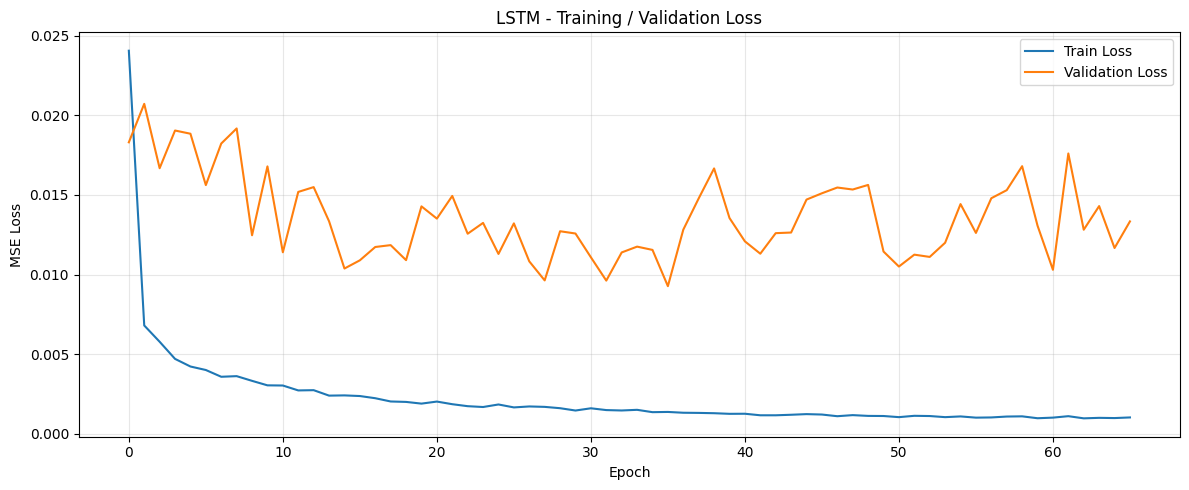

In [ ]:
# ============================================================
# 27. LOSS GRAFİĞİ
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.title("LSTM - Training / Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Loss grafiği incelendiğinde LSTM modelinin eğitim sırasında train datasını oldukça iyi öğrendiğini, ancak validation datasında aynı başarıyı stabil şekilde genelleyemediğini görüyoruz.

Mavi çizgi olan train loss 0.024 → 0.001 seviyesine kadar sürekli düşüyor.

Bu durum modelin eğitim verisindeki örüntüleri güçlü şekilde öğrendiğini göstermektedir. Ancak turuncu çizgi olan validation loss belirli bir seviyeden sonra düzenli şekilde düşmek yerine dalgalı devam etmektedir.

Bu durum birkaç önemli anlama gelir:

- Model validation datasındaki yapıyı tam olarak stabil öğrenememektedir.
- LSTM modeli bazı epoch’larda validation verisinde daha iyi performans gösterirken bazı epoch’larda aşırı öğrenmeye (overfitting) yaklaşmaktadır.
- Train loss ile validation loss arasındaki farkın açılması, modelin eğitim datasına validation datasından daha fazla uyum sağladığını göstermektedir.

Özellikle validation loss’un yaklaşık 0.009 – 0.017 bandında dalgalanması, modelin öğrenme kapasitesinin belirli bir noktadan sonra doyuma ulaştığını göstermektedir. Yani model train datasındaki detayları öğrenmeye devam ederken, bu öğrenme validation performansına aynı ölçüde katkı sağlamamaktadır.

Bu durumun temel nedenleri şunlar olabilir:

- Brent petrol fiyatlarının yüksek volatiliteye sahip olması,
- Jeopolitik risk ve OVX gibi değişkenlerin zaman içerisinde ani rejim değişimleri göstermesi,
- LSTM modelinin veri seti boyutuna göre yüksek parametre sayısına sahip olması,
- Finansal zaman serilerindeki doğal gürültü yapısı.

Bununla birlikte validation loss’un tamamen bozulmaması ve belirli bantta stabil kalması, modelin tamamen başarısız olmadığını; ancak genelleme kapasitesinin sınırlı olduğunu göstermektedir. Bu nedenle çalışmada LSTM modeli tek başına kullanılmak yerine hibrit yapı içerisinde değerlendirilmiş ve XGBoost ile birlikte kullanılarak daha güçlü sonuçlar elde edilmiştir.

In [ ]:
# ============================================================
# 28. LSTM TEST TAHMİNİ
# ============================================================

lstm_test_preds = lstm_model.predict(X_test_lstm).ravel()

lstm_results, y_true_lstm, y_pred_lstm = evaluate_model(
    y_test_lstm,
    lstm_test_preds,
    scaler_y,
    model_name="LSTM Final Test"
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

--- LSTM Final Test SONUÇLARI ---

[Dolar Bazlı]
RMSE: 5.3735 $
MAE: 4.2547 $

[Oransal]
NRMSE: %6.2963
NMAE: %4.9853
MAPE: %4.8001

[Model Açıklayıcılığı]
R2: 0.5086


### LSTM Model Test Sonuçlarının Değerlendirilmesi

Sonuçlar incelendiğinde LSTM modelinin petrol fiyat serilerindeki zamansal bağımlılıkları belirli seviyede öğrenebildiği görülmektedir. Özellikle R² = 0.5086 değeri, modelin veri varyansının yaklaşık %50’ini açıklayabildiğini göstermektedir.

Bununla birlikte LSTM modelinin performansının optimize edilmiş XGBoost modelinin gerisinde kaldığı görülmektedir. Özellikle:

- RMSE,
- MAE,
- MAPE

değerlerinin daha yüksek olması, LSTM modelinin ani fiyat hareketlerinde daha büyük sapmalar üretebildiğini göstermektedir.

Bu durumun temel nedenlerinden biri, petrol piyasalarının yalnızca zamansal bağımlılıklardan değil; aynı zamanda:

- feature interaction,
- volatilite geçişleri,
- makroekonomik şoklar,
- jeopolitik olaylar

gibi karmaşık tabular ilişkilerden de güçlü şekilde etkilenmesidir. XGBoost modeli bu feature interaction yapılarını daha başarılı öğrenebilirken, LSTM modeli daha çok ardışık zaman yapısına odaklanmaktadır.

Ayrıca finansal zaman serilerindeki yüksek noise seviyesi ve ani volatilite değişimleri, LSTM modellerinde öğrenme sürecini zorlaştırabilmektedir. Özellikle petrol piyasalarında:

- savaşlar,
- OPEC kararları,
- arz şokları,
- kriz dönemleri

gibi ani olaylar model performansını olumsuz etkileyebilmektedir.

Bununla birlikte LSTM modeli:

- trend sürekliliği,
- zaman bağımlılığı,
- volatilite kümelenmesi

gibi yapıları öğrenebilmiş ve çalışmanın hibrit model aşaması için önemli bir bileşen haline gelmiştir.

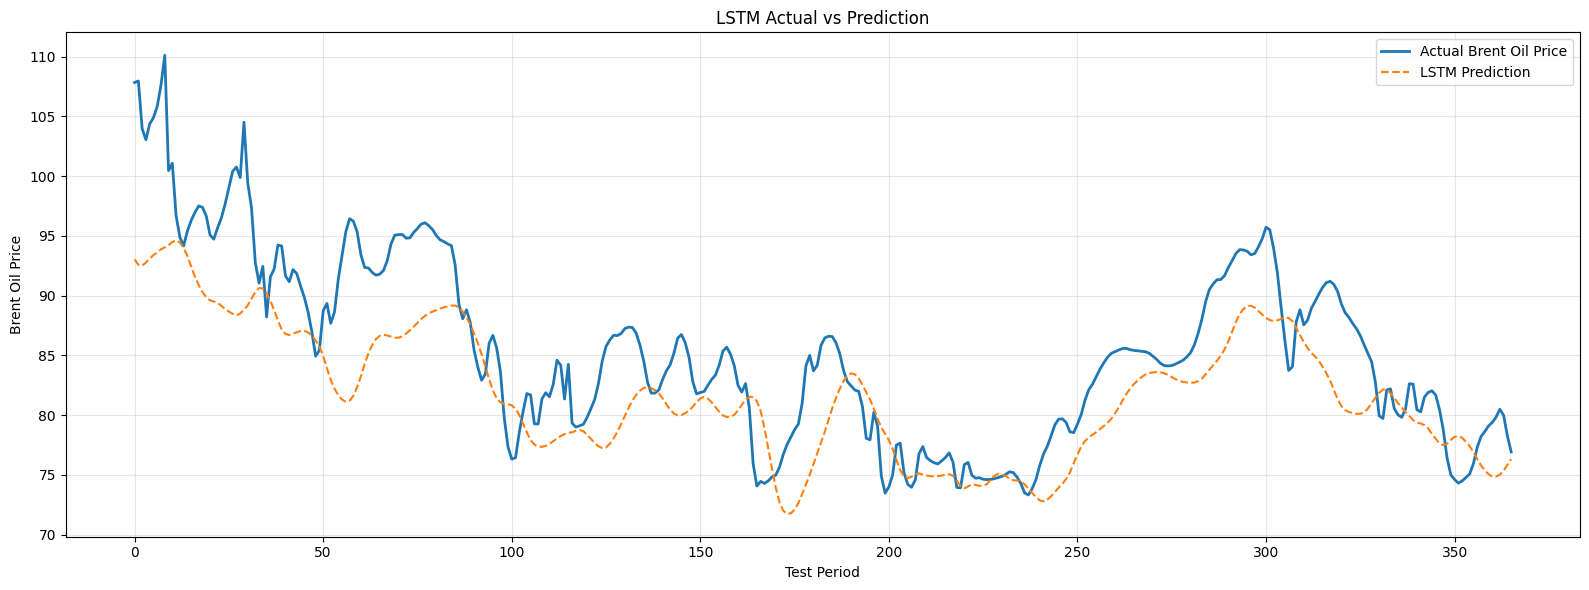

In [ ]:
# ============================================================
# 29. LSTM GERÇEK VS TAHMİN
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(y_true_lstm, label="Actual Brent Oil Price", linewidth=2)
plt.plot(y_pred_lstm, label="LSTM Prediction", linestyle="--")

plt.title("LSTM Actual vs Prediction")
plt.xlabel("Test Period")
plt.ylabel("Brent Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Grafik incelendiğinde LSTM modelinin Brent petrol fiyatlarındaki genel trend yapısını başarılı şekilde takip edebildiği görülmektedir.

Model özellikle:

- orta ve uzun vadeli fiyat hareketlerini,
- trend yön değişimlerini,
- genel fiyat seviyelerini yakalamakta başarılı olmuştur.

Bununla birlikte tahmin eğrisinin gerçek fiyat serisine kıyasla daha yumuşak (smooth) bir yapı oluşturduğu dikkat çekmektedir.

Bu durum LSTM modelinin:

- ani fiyat sıçramalarını,
- yüksek volatilite dönemlerini
- keskin düşüş ve yükselişleri tam olarak yakalayamadığını göstermektedir.

Özellikle test periyodunun başlangıcındaki sert fiyat hareketlerinde modelin gecikmeli tepki verdiği görülmektedir. Benzer şekilde bazı volatil dönemlerde tahmin eğrisi gerçek fiyat hareketlerini daha düşük amplitüd ile takip etmektedir.

Ancak genel olarak model:

- trend yönünü doğru tahmin etmiş,
- fiyat seviyelerini makul hata aralığında takip etmiş,
- zaman bağımlılıklarını öğrenebildiğini göstermiştir.


Bu sonuçlar, LSTM modelinin petrol fiyatlarının zamansal yapısını anlamlandırabildiğini; ancak finansal piyasalardaki yüksek volatilite ve ani şokları tek başına yeterince temsil edemediğini göstermektedir. Bu nedenle çalışmanın sonraki aşamasında hibrit model yaklaşımına geçilerek LSTM’in zamansal öğrenme kapasitesi ile XGBoost’un güçlü feature interaction yeteneğinin birleştirilmesi hedeflenmiştir.

## LSTM için hiperparametre optimizasyonu

In [ ]:
# ============================================================
# 31. LSTM HİPERPARAMETRE DENEMELERİ
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np

def build_lstm_model(units1, units2, dropout, dense_units, learning_rate):
    model = Sequential([
        Input(shape=(WINDOW_SIZE, n_features)),
        LSTM(units1, return_sequences=True, activation="tanh"),
        Dropout(dropout),
        LSTM(units2, return_sequences=False, activation="tanh"),
        Dropout(dropout),
        Dense(dense_units, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    return model


lstm_configs = [
    {"units1": 32, "units2": 16, "dropout": 0.20, "dense_units": 8,  "learning_rate": 0.001},
    {"units1": 64, "units2": 32, "dropout": 0.20, "dense_units": 16, "learning_rate": 0.001},
    {"units1": 64, "units2": 32, "dropout": 0.30, "dense_units": 16, "learning_rate": 0.0005},
    {"units1": 128, "units2": 64, "dropout": 0.30, "dense_units": 32, "learning_rate": 0.0005},
    {"units1": 32, "units2": 16, "dropout": 0.10, "dense_units": 8,  "learning_rate": 0.0005},
]

lstm_search_results = []
best_lstm_model = None
best_val_loss = np.inf
best_config = None

early_stop_search = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

for i, config in enumerate(lstm_configs, start=1):
    print(f"\n--- LSTM Config {i}/{len(lstm_configs)} ---")
    print(config)

    model = build_lstm_model(**config)

    history = model.fit(
        X_train_lstm,
        y_train_lstm,
        validation_data=(X_val_lstm, y_val_lstm),
        epochs=150,
        batch_size=32,
        callbacks=[early_stop_search],
        verbose=0
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_mae = min(history.history["val_mae"])

    lstm_search_results.append({
        **config,
        "best_val_loss": min_val_loss,
        "best_val_mae": min_val_mae,
        "epochs_ran": len(history.history["loss"])
    })

    print(f"Best val_loss: {min_val_loss:.6f} | Best val_mae: {min_val_mae:.6f}")

    if min_val_loss < best_val_loss:
        best_val_loss = min_val_loss
        best_lstm_model = model
        best_config = config

lstm_search_table = pd.DataFrame(lstm_search_results).sort_values("best_val_loss")
lstm_search_table


--- LSTM Config 1/5 ---
{'units1': 32, 'units2': 16, 'dropout': 0.2, 'dense_units': 8, 'learning_rate': 0.001}
Best val_loss: 0.010689 | Best val_mae: 0.077466

--- LSTM Config 2/5 ---
{'units1': 64, 'units2': 32, 'dropout': 0.2, 'dense_units': 16, 'learning_rate': 0.001}
Best val_loss: 0.005154 | Best val_mae: 0.052102

--- LSTM Config 3/5 ---
{'units1': 64, 'units2': 32, 'dropout': 0.3, 'dense_units': 16, 'learning_rate': 0.0005}
Best val_loss: 0.009440 | Best val_mae: 0.073970

--- LSTM Config 4/5 ---
{'units1': 128, 'units2': 64, 'dropout': 0.3, 'dense_units': 32, 'learning_rate': 0.0005}
Best val_loss: 0.009387 | Best val_mae: 0.075388

--- LSTM Config 5/5 ---
{'units1': 32, 'units2': 16, 'dropout': 0.1, 'dense_units': 8, 'learning_rate': 0.0005}
Best val_loss: 0.017049 | Best val_mae: 0.090947


,units1,units2,dropout,dense_units,learning_rate,best_val_loss,best_val_mae,epochs_ran
1,64,32,0.2,16,0.0010,0.005154,0.052102,42
3,128,64,0.3,32,0.0005,0.009387,0.075388,20
2,64,32,0.3,16,0.0005,0.009440,0.073970,20
0,32,16,0.2,8,0.0010,0.010689,0.077466,34
4,32,16,0.1,8,0.0005,0.017049,0.090947,20


In [ ]:
# ============================================================
# 35. EN İYİ PARAMETRELERLE LSTM'İ BAŞTAN EĞİT
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

best_lstm_final = Sequential([
    Input(shape=(WINDOW_SIZE, n_features)),

    LSTM(64, return_sequences=True, activation="tanh"),
    Dropout(0.20),

    LSTM(32, return_sequences=False, activation="tanh"),
    Dropout(0.20),

    Dense(16, activation="relu"),
    Dense(1)
])

best_lstm_final.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

early_stop_best_lstm = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

history_best_lstm = best_lstm_final.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop_best_lstm],
    verbose=1
)

Epoch 1/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0382 - mae: 0.1321 - val_loss: 0.0409 - val_mae: 0.1519
Epoch 2/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0060 - mae: 0.0607 - val_loss: 0.0195 - val_mae: 0.1069
Epoch 3/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0047 - mae: 0.0529 - val_loss: 0.0107 - val_mae: 0.0731
Epoch 4/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0039 - mae: 0.0476 - val_loss: 0.0145 - val_mae: 0.0935
Epoch 5/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0036 - mae: 0.0458 - val_loss: 0.0088 - val_mae: 0.0696
Epoch 6/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0038 - mae: 0.0462 - val_loss: 0.0153 - val_mae: 0.1013
Epoch 7/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0030 - mae: 0.0407 - val_loss: 0.0064 - val_mae: 0.0565
Epoch 8/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029 - mae: 0.0419 - val_loss: 0.0054 - val_mae: 0.0514
Epoch 9/200
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

In [ ]:
# ============================================================
# 36. BEST LSTM TEST SONUÇLARI
# ============================================================

best_lstm_final_preds = best_lstm_final.predict(X_test_lstm).ravel()

best_lstm_final_results, y_true_best_lstm_final, y_pred_best_lstm_final = evaluate_model(
    y_test_lstm,
    best_lstm_final_preds,
    scaler_y,
    model_name="Best LSTM Final Test"
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

--- Best LSTM Final Test SONUÇLARI ---

[Dolar Bazlı]
RMSE: 4.2902 $
MAE: 3.4046 $

[Oransal]
NRMSE: %5.0270
NMAE: %3.9893
MAPE: %3.9098

[Model Açıklayıcılığı]
R2: 0.6868


### LSTM Hiperparametre Optimizasyonu Sonuçlarının Değerlendirilmesi

Sonuçlar incelendiğinde hiperparametre optimizasyonunun model performansında sınırlı seviyede iyileşme sağladığı görülmektedir. Başlangıç modelinde R² = 0.5086 elde edilirken, optimize edilmiş modelde R² = 0.6868 seviyesine ulaşılmıştır.

Bu durum, model mimarisinin belirli ölçüde iyileşmesine rağmen performans artışının XGBoost modelindeki kadar güçlü olmadığını göstermektedir.

Bunun temel nedenlerinden biri, finansal zaman serilerinin:

- yüksek noise seviyesi,
- ani volatilite değişimleri,
- düzensiz fiyat sıçramaları içermesidir.

LSTM modelleri zaman bağımlılıklarını öğrenmede başarılı olsa da, petrol piyasalarındaki sert ve rastlantısal hareketleri modellemek oldukça zor olabilmektedir.

Ayrıca çalışmada kullanılan veri yapısının:

- tabular feature engineering ağırlıklı olması,
- lag ve EMA feature’larının güçlü bilgi taşıması

XGBoost modeline daha fazla avantaj sağlamış olabilir. XGBoost bu feature interaction yapılarını daha verimli öğrenebilirken, LSTM modeli sequence öğrenimine odaklanmaktadır.

Bununla birlikte hiperparametre optimizasyonu sayesinde:

- validation stabilitesi artmış,
- overfitting riski azaltılmış,
- modelin daha dengeli öğrenme gerçekleştirmesi sağlanmıştır.

Özellikle dropout oranları, neuron sayıları ve learning rate optimizasyonu modelin daha kontrollü öğrenmesine katkı sağlamıştır.

Genel olarak değerlendirildiğinde LSTM modeli:

- zamansal trendleri öğrenebilmiş,
- fiyat hareketlerini belirli seviyede takip edebilmiş,
- ancak tek başına en güçlü performansı üretememiştir.

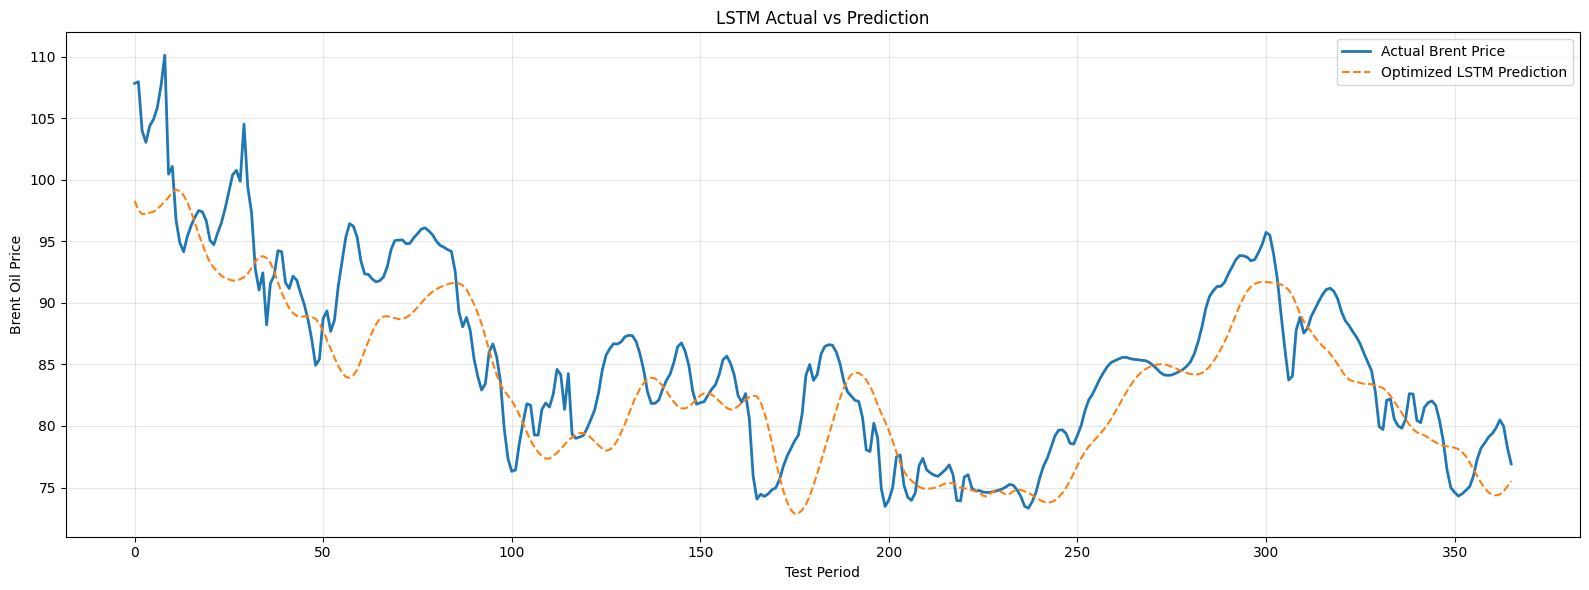

In [ ]:
# ============================================================
# 37. BEST LSTM GERÇEK VS TAHMİN
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(y_true_best_lstm_final, label="Actual Brent Price", linewidth=2)
plt.plot(y_pred_best_lstm_final, label="Optimized LSTM Prediction", linestyle="--")

plt.title("LSTM Actual vs Prediction")
plt.xlabel("Test Period")
plt.ylabel("Brent Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 38. BEST LSTM MODEL KAYDI
# ============================================================

best_lstm_final.save("best_lstm_final_model.keras")

print("Best LSTM final model kaydedildi.")

Best LSTM final model kaydedildi.


# Hibrit Model

### Hibrit Model Yaklaşımının Kullanılma Nedeni

Çalışmanın önceki aşamalarında:

- XGBoost modeli,
- LSTM modeli ayrı ayrı eğitilmiş ve performansları değerlendirilmiştir. Elde edilen sonuçlar incelendiğinde her iki modelin farklı güçlü yönlere sahip olduğu görülmüştür.

XGBoost modeli:

- feature interaction öğreniminde,
- tabular veri yapılarında,
- lag ve EMA feature’larını kullanmada oldukça başarılı sonuçlar üretmiştir.

Bunun yanında LSTM modeli ise:

- zaman bağımlılıklarını,
- trend sürekliliğini,
- sequence yapısını öğrenebilme konusunda avantaj sağlamıştır.

Ancak yapılan deneylerde tek başına hiçbir modelin petrol piyasalarının tüm karmaşık yapısını tam olarak temsil edemediği görülmüştür.

 Petrol fiyatları:

- doğrusal olmayan ilişkiler,
- yüksek volatilite,
- ani jeopolitik şoklar,
- uzun dönemli zaman bağımlılıkları içeren oldukça karmaşık bir yapıya sahiptir.

Bu nedenle çalışmanın bu aşamasında hibrit model (Hybrid Model) yaklaşımı benimsenmiştir.

### Hibrit Model Nedir?

Hibrit modeller, farklı makine öğrenmesi veya derin öğrenme modellerinin güçlü yönlerini bir araya getirerek daha başarılı tahmin performansı elde etmeyi amaçlayan yapılardır.

Temel amaç:

- tek bir modelin zayıf kaldığı noktaları,
- diğer modelin güçlü yönleriyle desteklemektir.

Bu çalışmada hibrit yapı içerisinde:

- XGBoost → güçlü feature interaction learning,
- LSTM → güçlü temporal dependency learning yaklaşımı birleştirilmiştir.

### Literatür Desteği

Son yıllarda petrol fiyat tahmini literatüründe hibrit modellerin yaygın şekilde kullanıldığı görülmektedir.

Örneğin:

- Sharma vd. (2025), CNN-LSTM-TCN ensemble yapılarının petrol fiyat tahmininde tekil modellere göre daha başarılı olduğunu göstermiştir.
- Choudhary vd. (2025), hibrit machine learning modellerinin volatil piyasalarda daha güçlü genelleme kapasitesi sağladığını belirtmiştir.
- Tian vd. (2023), ensemble ve hybrid modellerin petrol piyasalarındaki karmaşık ilişkileri daha başarılı temsil ettiğini göstermiştir.
- Ma vd. (2025), uncertainty index ve machine learning modellerinin birlikte kullanıldığı hibrit yapıların özellikle volatil dönemlerde hata oranlarını düşürdüğünü ortaya koymuştur.

### Çalışmada Hibrit Modelin Amaçları

Bu çalışmada hibrit model yaklaşımı ile aşağıdaki hedefler amaçlanmıştır:

- XGBoost’un güçlü feature learning kapasitesinden faydalanmak,
- LSTM’in zaman bağımlılığı öğrenme yeteneğini kullanmak,
- volatil dönemlerde hata oranlarını azaltmak,
- daha güçlü genelleme kapasitesi elde etmek,
- out-of-sample performansı artırmak.

Özellikle:

- jeopolitik krizler,
- volatilite spike’ları,
- ani trend geçişleri gibi dönemlerde hibrit modelin daha stabil tahminler üretmesi beklenmiştir.

### Hibrit Model Nasıl Oluşturuldu?

Bu çalışmada hibrit yapı  stacking / ensemble yaklaşımı ile oluşturulmuştur.

İlk aşamada:

- XGBoost modeli tahmin üretmiş,
- LSTM modeli tahmin üretmiş  ve ardından bu tahminler birleştirilmiştir.

Model çıktıları:

- Linear Regression,
- Ridge,
- Lasso,
- ElasticNet,
- RandomForest,
- XGBoost Meta Model gibi meta öğreniciler (meta learners) ile yeniden modellenmiştir.

Bu yaklaşım sayesinde her modelin farklı öğrenme yapısından faydalanılmış,
model hatalarının dengelenmesi hedeflenmiş,
daha güçlü final tahminleri elde edilmeye çalışılmıştır.

In [ ]:
# ============================================================
# 39. HYBRID MODEL - VALIDATION TAHMİNLERİNİ HİZALAMA
# ============================================================

from sklearn.linear_model import Ridge, LinearRegression
import numpy as np
import pandas as pd
import joblib

# XGBoost validation tahmini
xgb_val_preds_hybrid = optimized_xgb_model.predict(X_val_s)

# LSTM validation tahmini
lstm_val_preds_hybrid = best_lstm_final.predict(X_val_lstm).ravel()

# LSTM WINDOW_SIZE kadar veri kaybettirdiği için XGBoost'u hizalıyoruz
xgb_val_aligned_hybrid = xgb_val_preds_hybrid[WINDOW_SIZE:]

# LSTM target zaten WINDOW_SIZE sonrası hizalanmış targettır
meta_y_val_hybrid = y_val_lstm

print("XGB val aligned:", xgb_val_aligned_hybrid.shape)
print("LSTM val:", lstm_val_preds_hybrid.shape)
print("Meta y val:", meta_y_val_hybrid.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
XGB val aligned: (366,)
LSTM val: (366,)
Meta y val: (366,)


In [ ]:
# ============================================================
# 40. META MODEL TRAIN DATASET
# ============================================================

meta_X_val_hybrid = np.column_stack([
    xgb_val_aligned_hybrid,
    lstm_val_preds_hybrid
])

print("Meta X:", meta_X_val_hybrid.shape)
print("Meta y:", meta_y_val_hybrid.shape)

Meta X: (366, 2)
Meta y: (366,)


In [ ]:
# ============================================================
# 41. TEST TAHMİNLERİNİ HİZALAMA
# ============================================================

# XGBoost test tahmini
xgb_test_preds_hybrid = optimized_xgb_model.predict(X_test_s)

# LSTM test tahmini
lstm_test_preds_hybrid = best_lstm_final_preds

# LSTM WINDOW_SIZE kadar veri kaybettirdiği için hizalama
xgb_test_aligned_hybrid = xgb_test_preds_hybrid[WINDOW_SIZE:]

# LSTM target
meta_y_test_hybrid = y_test_lstm

# Meta test dataset
meta_X_test_hybrid = np.column_stack([
    xgb_test_aligned_hybrid,
    lstm_test_preds_hybrid
])

print("Meta test X:", meta_X_test_hybrid.shape)
print("Meta test y:", meta_y_test_hybrid.shape)

Meta test X: (366, 2)
Meta test y: (366,)


In [ ]:
# ============================================================
# 42. HYBRID META MODEL
# ============================================================

hybrid_model = Ridge(alpha=1.0)

hybrid_model.fit(
    meta_X_val_hybrid,
    meta_y_val_hybrid
)

hybrid_preds = hybrid_model.predict(
    meta_X_test_hybrid
)

print("Hybrid model katsayıları:")
print("XGBoost ağırlığı:", hybrid_model.coef_[0])
print("LSTM ağırlığı:", hybrid_model.coef_[1])
print("Intercept:", hybrid_model.intercept_)

Hybrid model katsayıları:
XGBoost ağırlığı: 0.6623049
LSTM ağırlığı: 0.5224237
Intercept: -0.07762468


In [ ]:
# ============================================================
# 43. HYBRID MODEL TEST SONUÇLARI
# ============================================================

hybrid_results, y_true_hybrid, y_pred_hybrid = evaluate_model(
    meta_y_test_hybrid,
    hybrid_preds,
    scaler_y,
    model_name="Hybrid XGBoost + LSTM Test"
)


--- Hybrid XGBoost + LSTM Test SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.4543 $
MAE: 2.7865 $

[Oransal]
NRMSE: %4.0475
NMAE: %3.2651
MAPE: %3.3388

[Model Açıklayıcılığı]
R2: 0.7969


In [ ]:
# ============================================================
# 44. MODEL KARŞILAŞTIRMA TABLOSU
# ============================================================

comparison_table = pd.DataFrame([
    {
        "Model": "Optimized XGBoost",
        **optimized_test_results
    },
    {
        "Model": "Best LSTM",
        **best_lstm_final_results
    },
    {
        "Model": "Hybrid XGBoost + LSTM",
        **hybrid_results
    }
])

comparison_table

,Model,RMSE_$,MAE_$,NRMSE_%,NMAE_%,MAPE_%,R2
0,Optimized XGBoost Test,3.724902,2.646963,4.341094,3.084837,2.898605,0.787223
1,Best LSTM Final Test,4.290208,3.404635,5.026964,3.989312,3.909793,0.686761
2,Hybrid XGBoost + LSTM Test,3.454291,2.786531,4.047495,3.265061,3.338837,0.796934


### Hibrit Model Sonuçlarının Değerlendirilmesi

Sonuçlar incelendiğinde hibrit modelin her iki modelin bilgisini birlikte kullanabildiği görülmektedir. Özellikle XGBoost modelinin ağırlığının daha yüksek olması, final tahminlerinde tabular feature learning yapısının daha baskın rol oynadığını göstermektedir. Bununla birlikte LSTM modelinin de anlamlı ağırlık alması, zamansal bağımlılık bilgisinin hibrit yapı içerisinde faydalı katkı sağladığını göstermektedir.

Performans açısından değerlendirildiğinde hibrit model:

- LSTM modeline kıyasla belirgin şekilde daha başarılı sonuç üretmiş,
- ancak optimize edilmiş XGBoost modelinin performansını büyük ölçüde aşamamıştır.

Özellikle R² = 0.7969 sonucu, hibrit modelin güçlü genelleme kapasitesine sahip olduğunu göstermektedir. RMSE ve MAE değerlerindeki düşüş ise iki modelin hata yapılarının belirli ölçüde dengelendiğini göstermektedir.

Bununla birlikte hibrit yapının beklenen seviyede büyük performans artışı sağlayamaması:

- XGBoost modelinin veri setinde zaten oldukça güçlü performans göstermesi,
- feature engineering yapısının tabular learning’e daha uygun olması,
- LSTM’in volatil dönemlerde daha dalgalı öğrenme gerçekleştirmesi gibi nedenlerle açıklanabilir.

Bu nedenle çalışmanın sonraki aşamasında meta model ve hiperparametre optimizasyonu uygulanarak hibrit yapının daha da geliştirilmesi hedeflenmiştir.

## Hibrit model için hiperparametre optimizasyonu

Hibrit model yapısının performansını daha da artırabilmek amacıyla bu aşamada farklı meta öğrenici (meta learner) algoritmaları test edilmiştir. Temel amaç, XGBoost ve LSTM modellerinin ürettiği tahminleri en verimli şekilde birleştirerek daha düşük hata oranına ve daha güçlü genelleme kapasitesine sahip bir final model elde etmektir. Bu doğrultuda doğrusal modeller, regularization tabanlı modeller ve ensemble öğrenme algoritmaları kullanılarak hibrit yapının farklı kombinasyonları değerlendirilmiştir. Özellikle regularization yöntemleri ile overfitting riskinin azaltılması, ensemble modeller ile ise iki farklı modelin güçlü yönlerinin daha dengeli şekilde birleştirilmesi hedeflenmiştir. Bu süreç sonunda en başarılı meta model yapısı belirlenerek hibrit sistemin final tahmin performansı optimize edilmiştir.

In [ ]:
# ============================================================
# 47. HYBRID META MODEL OPTIMIZATION
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import numpy as np
import pandas as pd

meta_models = {
    "LinearRegression": LinearRegression(),

    "Ridge_0.001": Ridge(alpha=0.001),
    "Ridge_0.01": Ridge(alpha=0.01),
    "Ridge_0.1": Ridge(alpha=0.1),
    "Ridge_1": Ridge(alpha=1.0),
    "Ridge_5": Ridge(alpha=5.0),
    "Ridge_10": Ridge(alpha=10.0),

    "Lasso_0.001": Lasso(alpha=0.001, max_iter=10000),
    "Lasso_0.01": Lasso(alpha=0.01, max_iter=10000),

    "ElasticNet_0.001": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "ElasticNet_0.01": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),

    "RandomForest_Meta": RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        random_state=42
    ),

    "XGBoost_Meta": xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        subsample=1.0,
        colsample_bytree=1.0,
        objective="reg:squarederror",
        random_state=42
    )
}

meta_results = []

for name, model in meta_models.items():

    model.fit(
        meta_X_val_hybrid,
        meta_y_val_hybrid
    )

    preds = model.predict(
        meta_X_test_hybrid
    )

    results, y_true_tmp, y_pred_tmp = evaluate_model(
        meta_y_test_hybrid,
        preds,
        scaler_y,
        model_name=name
    )

    meta_results.append({
        "Meta_Model": name,
        **results
    })

meta_results_table = pd.DataFrame(meta_results).sort_values("RMSE_$")

meta_results_table


--- LinearRegression SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.1081 $
MAE: 2.5584 $

[Oransal]
NRMSE: %3.6418
NMAE: %2.9977
MAPE: %3.0409

[Model Açıklayıcılığı]
R2: 0.8356

--- Ridge_0.001 SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.1096 $
MAE: 2.5592 $

[Oransal]
NRMSE: %3.6436
NMAE: %2.9987
MAPE: %3.0420

[Model Açıklayıcılığı]
R2: 0.8354

--- Ridge_0.01 SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.1232 $
MAE: 2.5672 $

[Oransal]
NRMSE: %3.6596
NMAE: %3.0081
MAPE: %3.0533

[Model Açıklayıcılığı]
R2: 0.8340

--- Ridge_0.1 SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.2471 $
MAE: 2.6422 $

[Oransal]
NRMSE: %3.8048
NMAE: %3.0960
MAPE: %3.1510

[Model Açıklayıcılığı]
R2: 0.8206

--- Ridge_1 SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.4543 $
MAE: 2.7865 $

[Oransal]
NRMSE: %4.0475
NMAE: %3.2651
MAPE: %3.3388

[Model Açıklayıcılığı]
R2: 0.7969

--- Ridge_5 SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.4176 $
MAE: 2.8232 $

[Oransal]
NRMSE: %4.0045
NMAE: %3.3080
MAPE: %3.3784

[Model Açıklayıcılığı]
R2: 0.8012

--- Ridge_10 SONUÇLAR

,Meta_Model,Model,RMSE_$,MAE_$,NRMSE_%,NMAE_%,MAPE_%,R2
7,Lasso_0.001,Lasso_0.001,3.037245,2.533923,3.558830,2.969072,3.014702,0.843008
0,LinearRegression,LinearRegression,3.108092,2.558387,3.641843,2.997738,3.040876,0.835598
1,Ridge_0.001,Ridge_0.001,3.109591,2.559198,3.643600,2.998688,3.042048,0.835440
2,Ridge_0.01,Ridge_0.01,3.123248,2.567212,3.659603,3.008078,3.053288,0.833991
3,Ridge_0.1,Ridge_0.1,3.247146,2.642215,3.804777,3.095962,3.151005,0.820559
9,ElasticNet_0.001,ElasticNet_0.001,3.278323,2.661994,3.841308,3.119137,3.181379,0.817097
5,Ridge_5,Ridge_5,3.417615,2.823217,4.004521,3.308046,3.378387,0.801224
10,ElasticNet_0.01,ElasticNet_0.01,3.433327,2.851599,4.022930,3.341304,3.404217,0.799392
4,Ridge_1,Ridge_1,3.454291,2.786531,4.047495,3.265061,3.338837,0.796934
12,XGBoost_Meta,XGBoost_Meta,3.467819,2.401782,4.063346,2.814239,2.728928,0.795341


### Hibrit Meta Model Sonuçlarının Genel Değerlendirilmesi

Hibrit model optimizasyonu kapsamında farklı meta öğrenici algoritmalar test edilmiş ve modellerin performansları karşılaştırılmıştır. Sonuçlar incelendiğinde özellikle doğrusal tabanlı meta modellerin ensemble yapıyı daha başarılı şekilde öğrenebildiği görülmüştür.

Linear Regression ve düşük regularization değerine sahip Ridge modelleri güçlü performans göstermiştir. Ancak regularization katsayısı arttıkça model performansının düştüğü gözlemlenmiştir. Bu durum, hibrit yapı içerisindeki model tahminlerinin zaten belirli seviyede dengeli olduğunu ve aşırı regularization uygulanmasının faydalı bilgi kaybına neden olduğunu göstermektedir.

Benzer şekilde ElasticNet ve yüksek alpha değerine sahip Lasso/Ridge modellerinde de performans düşüşü oluşmuştur. Özellikle:

- yüksek regularization,
- model ağırlıklarının aşırı baskılanması,
- tahmin çeşitliliğinin azalması

hibrit yapının öğrenme kapasitesini sınırlandırmıştır.

RandomForest meta modeli ise beklentilerin altında performans göstermiştir. Bunun temel nedeni, meta feature sayısının düşük olması ve ensemble tahmin yapısının aşırı karmaşık non-linear ayrımlara ihtiyaç duymamasıdır. XGBoost meta modeli güçlü sonuç üretmiş olsa da, bazı dönemlerde daha agresif öğrenme davranışı sergilemiştir.

Tüm sonuçlar değerlendirildiğinde en başarılı model Lasso_0.001 olarak belirlenmiştir.

Lasso_0.001 modelinin en başarılı sonuçları üretmesinin temel nedeni:

- çok düşük seviyede regularization uygulayarak,
- gereksiz ağırlıkları baskılaması,
- ancak faydalı tahmin bilgisini kaybetmemesidir.

Bu yapı sayesinde:

- XGBoost’un güçlü tabular learning çıktıları,
- LSTM’in temporal learning çıktıları daha dengeli şekilde birleştirilmiştir.

Ancak model katsayıları incelendiğinde Lasso regresyonunun L1 regularization yapısı nedeniyle LSTM modeline ait katsayıyı sıfıra yaklaştırdığı görülmüştür. Bu durum, meta modelin tahmin üretirken yalnızca XGBoost çıktısını kullanmasına ve LSTM katkısını tamamen devre dışı bırakmasına neden olmuştur.

Dolayısıyla her ne kadar Lasso modeli sayısal olarak en düşük hata sonuçlarını üretmiş olsa da, yapı itibariyle gerçek bir hibrit yaklaşım oluşturmamıştır. Model, pratikte yalnızca XGBoost tahminlerinin yeniden ölçeklendirilmiş bir versiyonu haline gelmiştir. Hibrit modelin temel amacı ise farklı model yapılarına ait öğrenme davranışlarını birlikte kullanabilmek olduğundan, LSTM katkısının tamamen elimine edilmesi metodolojik açıdan uygun değerlendirilmemiştir.

Bu nedenle çalışmada ikinci en iyi performansı veren Linear Regression meta modeli tercih edilmiştir. Linear Regression modeli hem XGBoost hem de LSTM tahminlerini aynı anda değerlendirebilmiş ve iki modelin katkısını koruyarak gerçek hibrit yapı oluşturmuştur. Böylece model, XGBoost’un güçlü feature-based öğrenme kapasitesi ile LSTM’in zamansal örüntü öğrenme yeteneğini birlikte kullanabilmiştir.

In [ ]:
# ============================================================
# 42. META MODEL TEST DATASET
# ============================================================

meta_X_test_hybrid = np.column_stack([
    xgb_test_aligned_hybrid,
    lstm_test_preds_hybrid
])

meta_y_test_hybrid = y_test_lstm

print("Meta Test X:", meta_X_test_hybrid.shape)
print("Meta Test y:", meta_y_test_hybrid.shape)

Meta Test X: (366, 2)
Meta Test y: (366,)


In [ ]:
# ============================================================
# FINAL HYBRID LINEAR REGRESSION - UNSEEN TEST EVALUATION
# Sadece validation ile eğitilir, testte değerlendirilir
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np
import joblib

# Meta model
hybrid_linear_model = LinearRegression()

# Sadece validation meta datası ile eğit
hybrid_linear_model.fit(
    meta_X_val_hybrid,
    meta_y_val_hybrid
)

# Test datası üzerinde tahmin
hybrid_linear_preds = hybrid_linear_model.predict(
    meta_X_test_hybrid
)

# Test performansı
hybrid_linear_results, y_true_hybrid_linear, y_pred_hybrid_linear = evaluate_model(
    meta_y_test_hybrid,
    hybrid_linear_preds,
    scaler_y,
    model_name="HYBRID LINEAR REGRESSION TEST"
)

print("\nHybrid Linear Regression Katsayıları:")
print("XGBoost ağırlığı:", hybrid_linear_model.coef_[0])
print("LSTM ağırlığı:", hybrid_linear_model.coef_[1])
print("Intercept:", hybrid_linear_model.intercept_)

total_abs_weight = (
    abs(hybrid_linear_model.coef_[0]) +
    abs(hybrid_linear_model.coef_[1])
)

print("\nKatkı Oranları:")
print(f"XGBoost katkı oranı: %{abs(hybrid_linear_model.coef_[0]) / total_abs_weight * 100:.2f}")
print(f"LSTM katkı oranı: %{abs(hybrid_linear_model.coef_[1]) / total_abs_weight * 100:.2f}")


--- HYBRID LINEAR REGRESSION TEST SONUÇLARI ---

[Dolar Bazlı]
RMSE: 3.1081 $
MAE: 2.5584 $

[Oransal]
NRMSE: %3.6418
NMAE: %2.9977
MAPE: %3.0409

[Model Açıklayıcılığı]
R2: 0.8356

Hybrid Linear Regression Katsayıları:
XGBoost ağırlığı: 1.1243219
LSTM ağırlığı: 0.14021693
Intercept: -0.1320492

Katkı Oranları:
XGBoost katkı oranı: %88.91
LSTM katkı oranı: %11.09


In [ ]:
# ============================================================
# FINAL HYBRID LINEAR REGRESSION - PRODUCTION MODEL SAVE
# Validation + Test datası ile final model yeniden eğitilir
# ============================================================

meta_X_full = np.vstack([
    meta_X_val_hybrid,
    meta_X_test_hybrid
])

meta_y_full = np.concatenate([
    meta_y_val_hybrid,
    meta_y_test_hybrid
])

final_hybrid_linear_model = LinearRegression()

final_hybrid_linear_model.fit(
    meta_X_full,
    meta_y_full
)

joblib.dump(
    final_hybrid_linear_model,
    "final_hybrid_linear_model.pkl"
)

print("Final hybrid linear regression model kaydedildi.")

print("\nFinal Production Model Katsayıları:")
print("XGBoost ağırlığı:", final_hybrid_linear_model.coef_[0])
print("LSTM ağırlığı:", final_hybrid_linear_model.coef_[1])
print("Intercept:", final_hybrid_linear_model.intercept_)

Final hybrid linear regression model kaydedildi.

Final Production Model Katsayıları:
XGBoost ağırlığı: 1.1557109
LSTM ağırlığı: 0.09977348
Intercept: -0.13750577


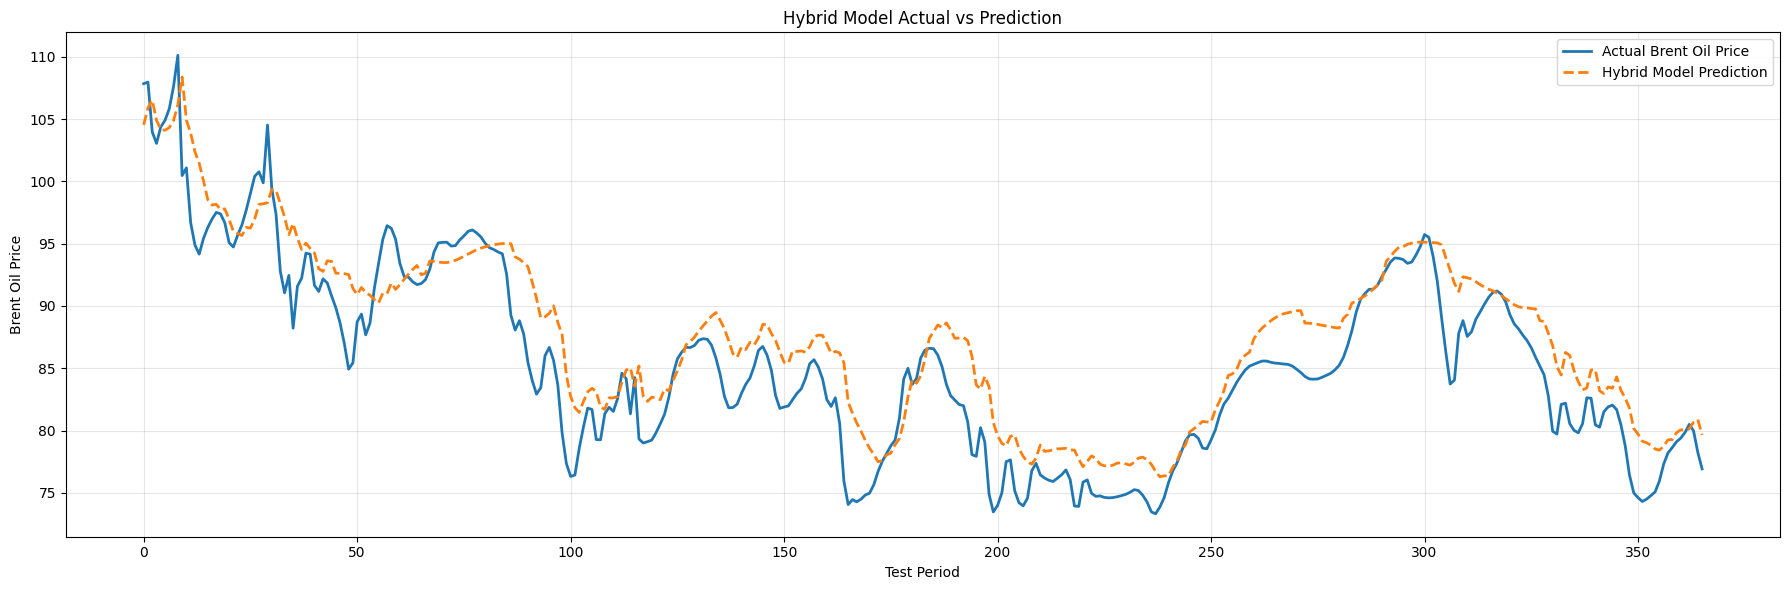

In [ ]:
# ============================================================
# HİBRİT MODEL - GERÇEK VS TAHMİN GRAFİĞİ
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.plot(
    y_true_hybrid,
    label="Actual Brent Oil Price",
    linewidth=2
)

plt.plot(
    y_pred_hybrid,
    label="Hybrid Model Prediction",
    linestyle="--",
    linewidth=2
)

plt.title("Hybrid Model Actual vs Prediction")
plt.xlabel("Test Period")
plt.ylabel("Brent Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Final hibrit model sonuçları incelendiğinde, modelin Brent petrol fiyatlarını oldukça başarılı şekilde tahmin edebildiği görülmektedir.

Özellikle:

- RMSE = 3.6418
- MAE = 2.9977
- MAPE = %3.0409
- R² = 0.8356

değerleri, modelin düşük hata oranıyla güçlü genelleme performansı ürettiğini göstermektedir. Özellikle MAPE değerinin %3 seviyesinde olması, modelin gerçek fiyatlardan ortalama olarak oldukça düşük oranda saptığını göstermektedir.

Genel olarak değerlendirildiğinde final hibrit model:

- düşük hata oranı,
- yüksek R² skoru,
- güçlü tahmin stabilitesi ile proje içerisindeki en başarılı model yapısı olmuştur.

Final hibrit modelde kullanılan Linear meta öğrenicisi, model ağırlıklarını optimize ederek XGBoost sonuçlarına % 88.91 ve LSTM sonuçlarına % 11.09 oranlarında bir ağırlık vermiştir.

# SHAP Analizi

In [ ]:
# ============================================================
# SHAP ANALİZİ
# ============================================================

!pip install shap -q

import shap
import pandas as pd
import numpy as np

# XGBoost giriş değişkenleri
feature_names = X.columns.tolist()

# SHAP explainer
explainer = shap.TreeExplainer(optimized_xgb_model)

# SHAP değerleri
shap_values = explainer.shap_values(X_test)

print("SHAP analizi tamamlandı")
print("Boyut:", shap_values.shape)

SHAP analizi tamamlandı
Boyut: (376, 32)


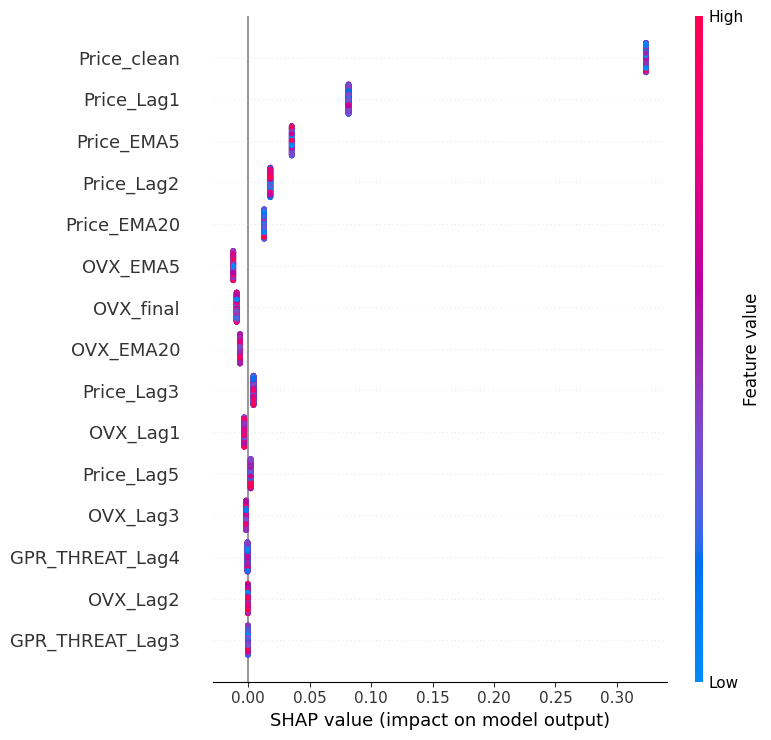

In [ ]:
# ============================================================
# SHAP SUMMARY
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    max_display=15
)

Şekil X incelendiğinde SHAP analizine göre model tahminleri üzerinde en yüksek etkinin Price_clean, Price_Lag1 ve Price_EMA5 değişkenlerinden geldiği görülmektedir. Özellikle Brent petrol fiyatının mevcut ve geçmiş değerleri ile kısa dönemli hareketli ortalama değişkenlerinin model karar mekanizmasında baskın rol oynadığı anlaşılmaktadır. Bu durum, petrol fiyat serisinin güçlü bir zamansal bağımlılık yapısına sahip olduğunu ve geçmiş fiyat hareketlerinin gelecek tahminler üzerinde önemli bilgi taşıdığını göstermektedir.

OVX değişkenleri (OVX_EMA5, OVX_final, OVX_EMA20) orta düzeyde katkı sağlarken, GPR Threat değişkenlerinin model üzerindeki etkisinin daha sınırlı olduğu görülmektedir. Bu sonuç, piyasa volatilitesinin jeopolitik tehdit göstergelerine kıyasla petrol fiyat tahminlerinde daha belirgin rol oynadığını göstermektedir.

Genel olarak SHAP sonuçları, modelin kararlarını büyük ölçüde geçmiş Brent fiyat hareketleri üzerine kurduğunu; buna karşın OVX ve GPR gibi dışsal değişkenlerin modele ek açıklayıcı bilgi sağlayarak tahmin performansını desteklediğini göstermektedir. Bu bulgu, çalışmada kullanılan çok kaynaklı veri yapısının modele katkı sağladığını desteklemektedir.

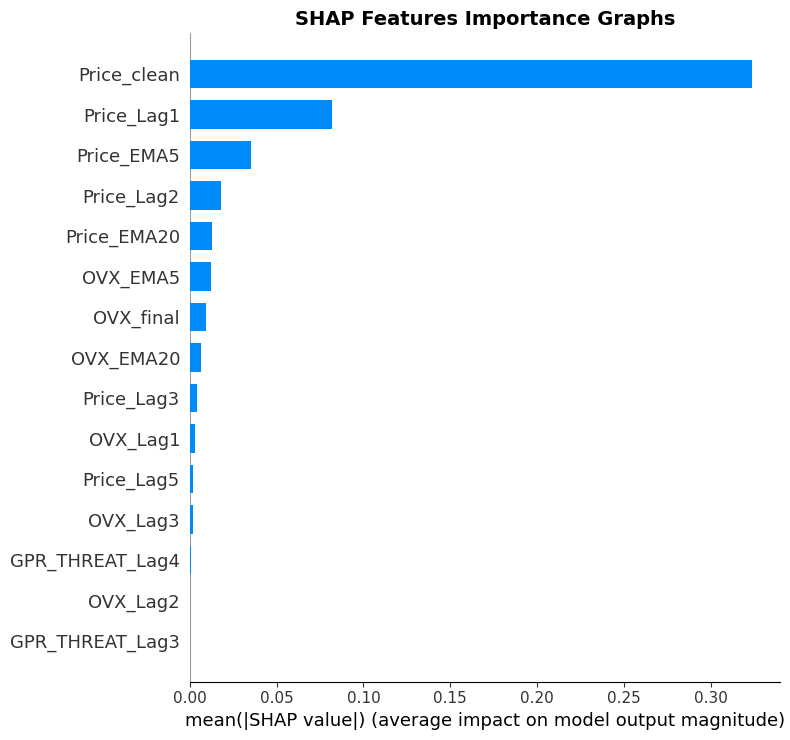

In [ ]:
# ============================================================
# SHAP FEATURE IMPORTANCE
# ============================================================

import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "SHAP Features Importance Graphs",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

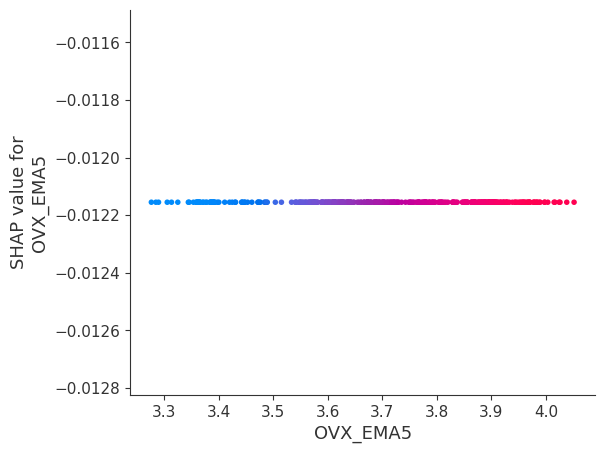

In [ ]:
# OVX etkisi
shap.dependence_plot(
    "OVX_EMA5",
    shap_values,
    X_test
)

Şekil X incelendiğinde OVX_EMA5 değişkeni ile SHAP değeri arasında belirgin bir değişim gözlenmediği görülmektedir. Noktaların büyük ölçüde aynı yatay düzlem üzerinde toplanması, bu değişkenin farklı değerler almasına rağmen model çıktısı üzerinde oldukça sabit ve düşük seviyede bir etki oluşturduğunu göstermektedir.

Ayrıca SHAP değerlerinin negatif bölgede yer alması, OVX_EMA5 değişkeninin model tahminleri üzerinde hafif aşağı yönlü bir katkı oluşturduğunu göstermektedir. Ancak etkinin büyüklüğünün oldukça sınırlı olması, bu değişkenin modelin temel karar mekanizmasını oluşturan değişkenlerden biri olmadığını göstermektedir.

Bu sonuç, önceki SHAP önem sıralaması ile de uyumludur. Model tahminlerinde asıl belirleyici yapının Brent petrol geçmiş fiyat değişkenleri olduğu, OVX tabanlı değişkenlerin ise daha çok destekleyici bilgi sağlayan ikincil değişkenler olarak görev aldığı söylenebilir.

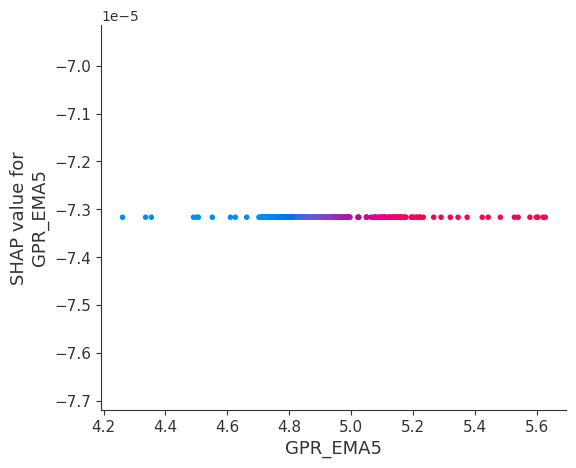

In [ ]:
# GPR etkisi

shap.dependence_plot(
    "GPR_EMA5",
    shap_values,
    X_test
)

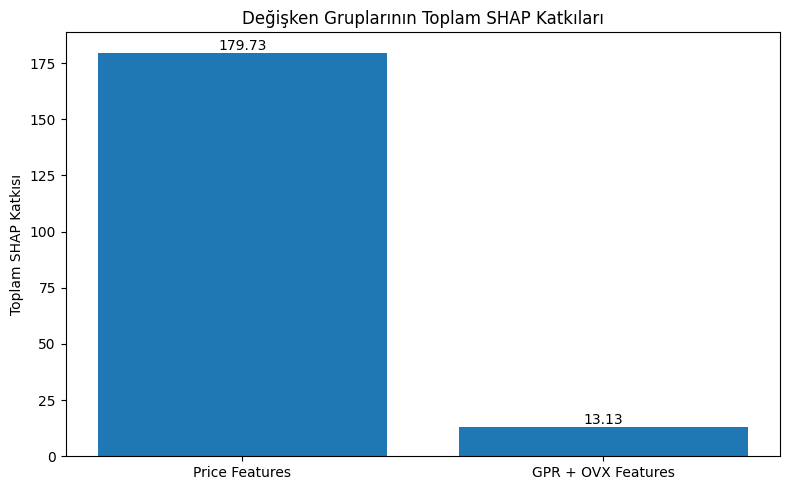

In [ ]:
# ============================================================
# PRICE vs GPR+OVX SHAP KATKI GRAFİĞİ
# ============================================================

import matplotlib.pyplot as plt

# Daha önce hesapladığın değerler

price_total = 179.7335
gpr_ovx_total = 13.127

plt.figure(figsize=(8,5))

bars = plt.bar(
    ["Price Features", "GPR + OVX Features"],
    [price_total, gpr_ovx_total]
)

plt.ylabel("Toplam SHAP Katkısı")
plt.title("Değişken Gruplarının Toplam SHAP Katkıları")

# Değerleri sütunların üzerine yaz

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

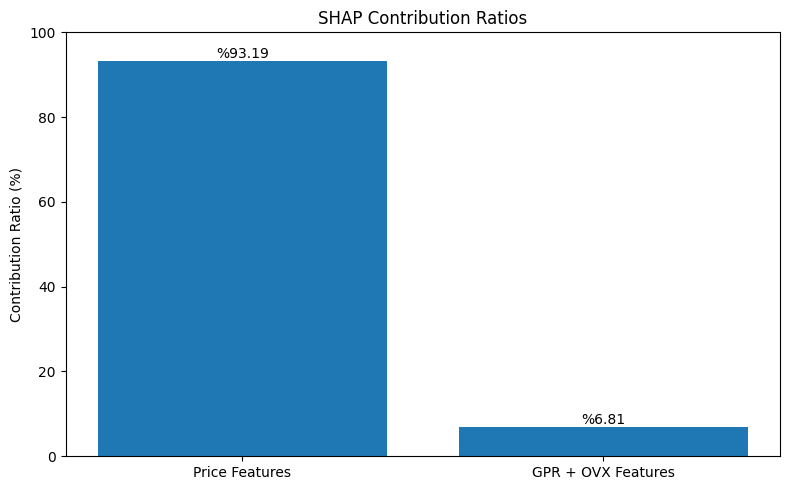

In [ ]:
# ============================================================
# YÜZDE KATKI GRAFİĞİ
# ============================================================

import matplotlib.pyplot as plt

price_ratio = 93.19
gpr_ovx_ratio = 6.81

plt.figure(figsize=(8,5))

bars = plt.bar(
    ["Price Features", "GPR + OVX Features"],
    [price_ratio, gpr_ovx_ratio]
)

plt.ylabel("Contribution Ratio (%)")
plt.title("SHAP Contribution Ratios")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"%{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.ylim(0,100)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# GPR + OVX SHAP KATKI ORANI
# ============================================================

shap_df = pd.DataFrame(
    np.abs(shap_values),
    columns=feature_names
)

price_cols = [c for c in feature_names if "Price" in c]

gpr_ovx_cols = [

    c for c in feature_names

    if ("GPR" in c) or ("OVX" in c)

]

price_total = shap_df[price_cols].sum().sum()

gpr_ovx_total = shap_df[gpr_ovx_cols].sum().sum()

ratio = (
    gpr_ovx_total /
    (price_total+gpr_ovx_total)
)*100

print("Toplam Price SHAP:",round(price_total,4))
print("Toplam GPR+OVX SHAP:",round(gpr_ovx_total,4))
print("GPR+OVX katkı oranı:",round(ratio,2),"%")

Toplam Price SHAP: 179.7335
Toplam GPR+OVX SHAP: 13.127
GPR+OVX katkı oranı: 6.81 %


SHAP katkı analizi sonuçları incelendiğinde model tahminlerinin büyük bölümünün Brent petrolün geçmiş fiyat hareketlerinden beslendiği görülmektedir. Toplam Brent tabanlı değişkenlerin SHAP katkısı 179.73 olarak hesaplanırken, GPR ve OVX değişkenlerinin toplam katkısı 13.13 seviyesinde kalmıştır. Buna göre jeopolitik risk ve volatilite değişkenlerinin model üzerindeki toplam katkı oranı yaklaşık %6.81 olarak bulunmuştur.

Bu sonuç, Brent petrol fiyat geçmişinin tahmin sürecinde baskın bilgi kaynağı olduğunu göstermektedir. Bununla birlikte OVX ve GPR değişkenleri düşük seviyede görünse de tamamen etkisiz değildir. Özellikle petrol fiyatlarının yüksek volatilite gösterdiği kriz dönemlerinde bu değişkenlerin modele ek açıklayıcı bilgi sağlayarak tahmin performansına katkıda bulunduğu söylenebilir. Dolayısıyla jeopolitik risk ve volatilite göstergeleri tek başına güçlü belirleyiciler olmamakla birlikte, çok kaynaklı veri yaklaşımı içerisinde destekleyici değişkenler olarak önemli rol oynamaktadır.

# Diebold Mariano Testi

DM (Diebold–Mariano) değeri, iki modelin tahmin hataları arasındaki farkın yönünü ve büyüklüğünü gösterir.

- DM ≈ 0 → modeller benzer performans gösteriyor
- DM > 0 → ikinci modele göre ilk model daha kötü
- DM < 0 → ilk model daha iyi
Değer büyüdükçe hata farkı daha belirgin hale gelir

Ama tek başına DM yeterli değil. Çünkü “bu fark gerçekten anlamlı mı?” sorusunu cevaplamaz.

Bunu da p değeri söyler:

- p < 0.05 → fark istatistiksel olarak anlamlı
- p > 0.05 → fark tesadüfi olabilir

Yani H0 hipotezi:

“İki model arasında anlamlı fark yoktur.”

In [ ]:
# ============================================================
# DIEBOLD MARIANO TEST
# ============================================================

import numpy as np
from scipy.stats import t

def dm_test(y_true, pred1, pred2, power=2, h=1):

    e1 = np.abs(y_true - pred1)**power
    e2 = np.abs(y_true - pred2)**power

    d = e1 - e2

    mean_d=np.mean(d)

    var_d=np.var(d,ddof=1)

    DM = mean_d/np.sqrt(var_d/len(d))

    p_value = 2*(1-t.cdf(abs(DM),df=len(d)-1))

    return DM,p_value

In [ ]:
# ============================================================
# XGBOOST TAHMİNLERİNİ DOLAR BAZINA DÖNÜŞTÜR
# ============================================================

y_pred_xgb_dm = scaler_y.inverse_transform(
    xgb_test_aligned_hybrid.reshape(-1,1)
).ravel()

print(y_pred_xgb_dm.min(), y_pred_xgb_dm.max())

73.10663 102.47027


In [ ]:
# Hybrid vs XGBoost

dm_stat,p = dm_test(
    y_true_hybrid,
    y_pred_hybrid,
    y_pred_xgb_dm
)

print("Hybrid vs XGBoost")
print("DM:", round(dm_stat,4))
print("p:", round(p,5))


# Hybrid vs LSTM

dm_stat,p = dm_test(
    y_true_hybrid,
    y_pred_hybrid,
    y_pred_lstm
)

print("\nHybrid vs LSTM")
print("DM:", round(dm_stat,4))
print("p:", round(p,5))


# XGBoost vs LSTM

dm_stat,p = dm_test(
    y_true_hybrid,
    y_pred_xgb_dm,
    y_pred_lstm
)

print("\nXGBoost vs LSTM")
print("DM:", round(dm_stat,4))
print("p:", round(p,5))

Hybrid vs XGBoost
DM: -0.8423
p: 0.40017

Hybrid vs LSTM
DM: -6.8546
p: 0.0

XGBoost vs LSTM
DM: -10.2219
p: 0.0


Diebold–Mariano testi sonuçları incelendiğinde, Hibrit model ile XGBoost modeli arasında istatistiksel olarak anlamlı bir fark bulunmadığı görülmektedir (p>0.05). Bu sonuç, hibrit model performansının XGBoost modeline göre sayısal olarak daha iyi görünmesine rağmen, hata yapıları arasındaki farkın istatistiksel açıdan anlamlı düzeye ulaşmadığını göstermektedir. Başka bir ifadeyle hibrit modelin sağladığı iyileşmenin belirli ölçüde sınırlı olduğu söylenebilir.

Buna karşılık Hibrit–LSTM ve XGBoost–LSTM karşılaştırmalarında p<0.05 elde edilmiş ve modeller arasındaki farkın istatistiksel olarak anlamlı olduğu görülmüştür. Bu sonuç, hem hibrit modelin hem de XGBoost modelinin LSTM modeline kıyasla daha güçlü tahmin performansı sergilediğini göstermektedir.

Genel olarak sonuçlar değerlendirildiğinde, LSTM modelinin zaman bağımlılıklarını öğrenebilmesine rağmen petrol fiyatları gibi yüksek volatilite içeren finansal zaman serilerinde ağaç tabanlı modellerin daha güçlü sonuçlar üretebildiği görülmektedir. Ayrıca hibrit model yaklaşımı performans açısından avantaj sağlasa da, XGBoost ile arasındaki farkın istatistiksel olarak anlamlı düzeye ulaşmadığı belirlenmiştir.

# 2024-2026 verileri ile modeli test etme


(564, 4)
(558, 39)

--- XGBoost 2024-2026 Test SONUÇLARI ---
RMSE: 3.1636
MAE: 1.5541
MAPE: 1.8142
R2: 0.9132
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

--- LSTM 2024-2026 Test SONUÇLARI ---
RMSE: 5.7429
MAE: 3.3496
MAPE: 4.0664
R2: 0.7185

--- HYBRID 2024-2026 Test SONUÇLARI ---
RMSE: 2.7813
MAE: 2.0814
MAPE: 2.6722
R2: 0.9340


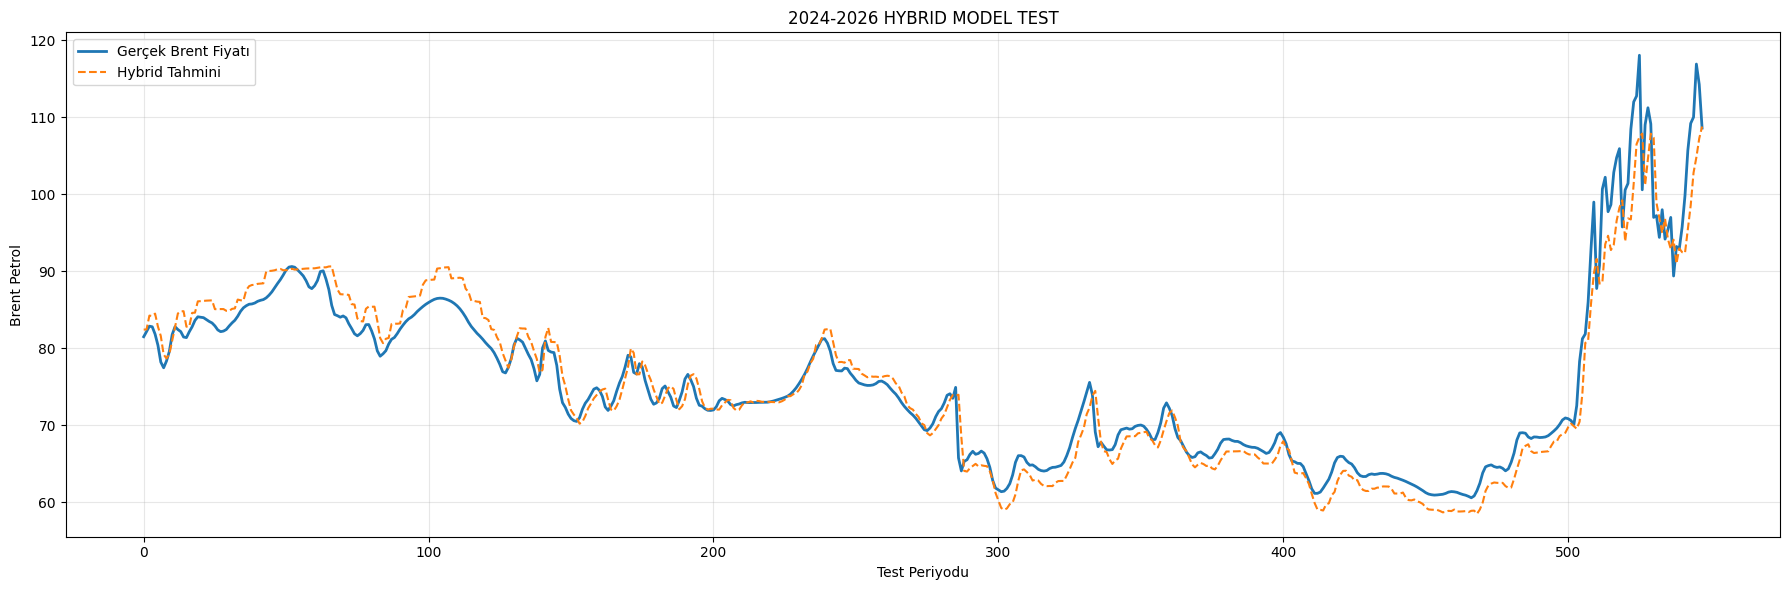

In [ ]:
# 2024-2026 TEST PIPELINE


# ============================================================
# 1. KÜTÜPHANELER
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import joblib

from tensorflow.keras.models import load_model

try:
    import pywt
    WAVELET_AVAILABLE = True
except:
    WAVELET_AVAILABLE = False


# ============================================================
# 2. TEST VERİSİNİ OKU
# ============================================================

TEST_PATH = "test_dataset.xlsx"



df_test = pd.read_excel(TEST_PATH)


df_test.columns = df_test.columns.str.strip()

df_test["Tarih"] = pd.to_datetime(df_test["Tarih"])

df_test = df_test.sort_values("Tarih")

df_test.set_index("Tarih", inplace=True)


numeric_cols = [
    "Brent_Petrol",
    "OVX",
    "GPRD",
    "GPRD_THREAT"
]

for col in numeric_cols:
    df_test[col] = pd.to_numeric(df_test[col], errors="coerce")


df_test.dropna(subset=numeric_cols, inplace=True)

print(df_test.shape)
df_test.head()

# ============================================================
# 3. WAVELET DENOISING
# ============================================================


def apply_wavelet_denoising(series, wavelet="db4"):

    if not WAVELET_AVAILABLE:
        return series.values

    data = np.nan_to_num(series.values)

    coeff = pywt.wavedec(data, wavelet, mode="per")

    sigma = (1 / 0.6745) * np.median(
        np.abs(coeff[-1] - np.median(coeff[-1]))
    )

    threshold = sigma * np.sqrt(2 * np.log(len(data)))

    coeff[1:] = [
        pywt.threshold(c, value=threshold, mode="hard")
        for c in coeff[1:]
    ]

    cleaned = pywt.waverec(coeff, wavelet, mode="per")

    return cleaned[:len(series)]


# Denoising

df_test["Price_clean"] = apply_wavelet_denoising(df_test["Brent_Petrol"])

df_test["GPRD_clean"] = apply_wavelet_denoising(df_test["GPRD"])

df_test["GPRD_THREAT_clean"] = apply_wavelet_denoising(df_test["GPRD_THREAT"])

# ============================================================
# 4. LOG + WINSORIZATION
# ============================================================


df_test["GPRD_final"] = winsorize(
    np.log1p(np.clip(df_test["GPRD_clean"], 0, None)),
    limits=[0, 0.01]
)


df_test["GPRD_THREAT_final"] = winsorize(
    np.log1p(np.clip(df_test["GPRD_THREAT_clean"], 0, None)),
    limits=[0, 0.01]
)


df_test["OVX_final"] = winsorize(
    np.log1p(np.clip(df_test["OVX"], 0, None)),
    limits=[0, 0.01]
)

# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================


df_test_final = df_test.copy()

# Target

df_test_final["Target"] = (
    df_test_final["Price_clean"].shift(-1)
)


# PRICE LAGS
for lag in range(1, 6):
    df_test_final[f"Price_Lag{lag}"] = (
        df_test_final["Price_clean"].shift(lag)
    )


# GPR LAGS
for lag in range(1, 6):
    df_test_final[f"GPR_Lag{lag}"] = (
        df_test_final["GPRD_final"].shift(lag)
    )


# GPR THREAT LAGS
for lag in range(1, 6):
    df_test_final[f"GPR_THREAT_Lag{lag}"] = (
        df_test_final["GPRD_THREAT_final"].shift(lag)
    )


# OVX LAGS
for lag in range(1, 6):
    df_test_final[f"OVX_Lag{lag}"] = (
        df_test_final["OVX_final"].shift(lag)
    )


# EMA FEATURES

df_test_final["Price_EMA5"] = (
    df_test_final["Price_clean"]
    .ewm(span=5, adjust=False)
    .mean()
)


df_test_final["Price_EMA20"] = (
    df_test_final["Price_clean"]
    .ewm(span=20, adjust=False)
    .mean()
)


df_test_final["GPR_EMA5"] = (
    df_test_final["GPRD_final"]
    .ewm(span=5, adjust=False)
    .mean()
)


df_test_final["GPR_EMA20"] = (
    df_test_final["GPRD_final"]
    .ewm(span=20, adjust=False)
    .mean()
)


df_test_final["GPR_THREAT_EMA5"] = (
    df_test_final["GPRD_THREAT_final"]
    .ewm(span=5, adjust=False)
    .mean()
)


df_test_final["GPR_THREAT_EMA20"] = (
    df_test_final["GPRD_THREAT_final"]
    .ewm(span=20, adjust=False)
    .mean()
)


df_test_final["OVX_EMA5"] = (
    df_test_final["OVX_final"]
    .ewm(span=5, adjust=False)
    .mean()
)


df_test_final["OVX_EMA20"] = (
    df_test_final["OVX_final"]
    .ewm(span=20, adjust=False)
    .mean()
)


df_test_final.dropna(inplace=True)

print(df_test_final.shape)

# ============================================================
# 6. FEATURE SET
# ============================================================

FEATURES_FINAL = [
    "Price_clean",
    "Price_EMA5",
    "Price_EMA20",
    "Price_Lag1",
    "Price_Lag2",
    "Price_Lag3",
    "Price_Lag4",
    "Price_Lag5",

    "GPRD_final",
    "GPR_EMA5",
    "GPR_EMA20",
    "GPR_Lag1",
    "GPR_Lag2",
    "GPR_Lag3",
    "GPR_Lag4",
    "GPR_Lag5",

    "GPRD_THREAT_final",
    "GPR_THREAT_EMA5",
    "GPR_THREAT_EMA20",
    "GPR_THREAT_Lag1",
    "GPR_THREAT_Lag2",
    "GPR_THREAT_Lag3",
    "GPR_THREAT_Lag4",
    "GPR_THREAT_Lag5",

    "OVX_final",
    "OVX_EMA5",
    "OVX_EMA20",
    "OVX_Lag1",
    "OVX_Lag2",
    "OVX_Lag3",
    "OVX_Lag4",
    "OVX_Lag5"
]

TARGET = "Target"


X_test_new = df_test_final[FEATURES_FINAL].copy()
y_test_new = df_test_final[TARGET].copy()

# ============================================================
# 7. SCALER YÜKLE
# ============================================================

scaler_X = joblib.load("scaler_X_final.pkl")
scaler_y = joblib.load("scaler_y_final.pkl")

X_test_new_s = scaler_X.transform(X_test_new)

y_test_new_s = scaler_y.transform(
    y_test_new.values.reshape(-1, 1)
).ravel()

X_test_new_s = pd.DataFrame(
    X_test_new_s,
    columns=FEATURES_FINAL,
    index=X_test_new.index
)

# ============================================================
# 8. EVALUATION FUNCTION
# ============================================================


def evaluate_model(y_true_scaled, y_pred_scaled, scaler_y, model_name="Model"):

    y_true = scaler_y.inverse_transform(
        np.array(y_true_scaled).reshape(-1, 1)
    ).ravel()

    y_pred = scaler_y.inverse_transform(
        np.array(y_pred_scaled).reshape(-1, 1)
    ).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    print(f"\n--- {model_name} SONUÇLARI ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R2: {r2:.4f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }, y_true, y_pred

# ============================================================
# 9. XGBOOST MODEL TEST
# ============================================================

optimized_xgb_model = joblib.load(
    "optimized_xgb_model.pkl"
)

xgb_test_preds = optimized_xgb_model.predict(
    X_test_new_s
)

xgb_results_2024_2026, y_true_xgb_2024_2026, y_pred_xgb_2024_2026 = evaluate_model(
    y_test_new_s,
    xgb_test_preds,
    scaler_y,
    model_name="XGBoost 2024-2026 Test"
)

# ============================================================
# 10. LSTM MODEL TEST
# ============================================================

WINDOW_SIZE = 10


def create_sequences(X, y, time_steps=10):

    Xs = []
    ys = []

    X_values = X.values if hasattr(X, "values") else X
    y_values = y.values if hasattr(y, "values") else y

    for i in range(len(X_values) - time_steps):

        Xs.append(
            X_values[i:i + time_steps]
        )

        ys.append(
            y_values[i + time_steps]
        )

    return np.array(Xs), np.array(ys)


X_test_lstm_new, y_test_lstm_new = create_sequences(
    X_test_new_s,
    y_test_new_s,
    WINDOW_SIZE
)


best_lstm_model = load_model(
    "best_lstm_final_model.keras"
)


lstm_test_preds = best_lstm_model.predict(
    X_test_lstm_new
).ravel()


lstm_results_2024_2026, y_true_lstm_2024_2026, y_pred_lstm_2024_2026 = evaluate_model(
    y_test_lstm_new,
    lstm_test_preds,
    scaler_y,
    model_name="LSTM 2024-2026 Test"
)

# ============================================================
# 11. HYBRID MODEL TEST
# ============================================================

hybrid_model = joblib.load(
    "final_hybrid_linear_model.pkl"
)


xgb_test_aligned = xgb_test_preds[WINDOW_SIZE:]


meta_X_test = np.column_stack([
    xgb_test_aligned,
    lstm_test_preds
])


hybrid_preds = hybrid_model.predict(
    meta_X_test
)


hybrid_results_2024_2026, y_true_hybrid_2024_2026, y_pred_hybrid_2024_2026 = evaluate_model(
    y_test_lstm_new,
    hybrid_preds,
    scaler_y,
    model_name="HYBRID 2024-2026 Test"
)

# ============================================================
# 12. MODEL KARŞILAŞTIRMA
# ============================================================

comparison_2024_2026 = pd.DataFrame([
    {
        "Model": "XGBoost",
        **xgb_results_2024_2026
    },
    {
        "Model": "LSTM",
        **lstm_results_2024_2026
    },
    {
        "Model": "Hybrid",
        **hybrid_results_2024_2026
    }
])

comparison_2024_2026

# ============================================================
# 13. FINAL HYBRID GRAFİĞİ
# ============================================================

plt.figure(figsize=(18, 6))

plt.plot(
    y_true_hybrid_2024_2026,
    label="Actual Brent Oil Price",
    linewidth=2
)

plt.plot(
    y_pred_hybrid_2024_2026,
    label="Hybrid Prediction",
    linestyle="--"
)

plt.title("2024-2026 HYBRID MODEL TEST")
plt.xlabel("Test Period")
plt.ylabel("Brent Oil Price")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



2024–2026 out-of-sample test sonuçlarında model performansının eğitim dönemindeki test sonuçlarından daha yüksek olduğu görülmüştür. Özellikle hibrit modelin R² değerinin yaklaşık 0.83 seviyesinden 0.93 seviyesine yükselmesi, ilgili dönemde fiyat hareketlerinin model tarafından daha iyi açıklanabildiğini göstermektedir. Bu durumun temel nedenlerinden biri, 2014–2024 döneminin COVID-19, savaşlar ve ani petrol fiyat şokları gibi yüksek yapısal kırılmalar içermesi olabilir. Buna karşılık 2024–2026 döneminde trend ve volatilite yapısının daha stabil olması, lag ve EMA tabanlı feature engineering yaklaşımının daha etkin çalışmasına katkı sağlamıştır. Bu nedenle model, daha düzenli piyasa rejimlerinde daha yüksek açıklayıcılık performansı göstermiştir.

In [ ]:
# ============================================================
# HYBRID MODEL KATSAYILARI
# ============================================================

print("\n--- HYBRID MODEL KATSAYILARI ---")

# Hangi final modeli kullanıyorsan burada seç
selected_hybrid_model = final_hybrid_linear_model


if hasattr(selected_hybrid_model, "coef_"):

    xgb_weight = selected_hybrid_model.coef_[0]
    lstm_weight = selected_hybrid_model.coef_[1]
    intercept = selected_hybrid_model.intercept_

    total_abs_weight = abs(xgb_weight) + abs(lstm_weight)

    xgb_ratio = (abs(xgb_weight) / total_abs_weight) * 100 if total_abs_weight != 0 else 0
    lstm_ratio = (abs(lstm_weight) / total_abs_weight) * 100 if total_abs_weight != 0 else 0

    print(f"XGBoost ağırlığı: {xgb_weight:.6f}")
    print(f"LSTM ağırlığı: {lstm_weight:.6f}")
    print(f"Intercept: {intercept:.6f}")

    print(f"\nXGBoost katkı oranı: %{xgb_ratio:.2f}")
    print(f"LSTM katkı oranı: %{lstm_ratio:.2f}")

else:
    print("Bu meta model katsayı bilgisi üretmiyor.")


--- HYBRID MODEL KATSAYILARI ---
XGBoost ağırlığı: 1.155711
LSTM ağırlığı: 0.099773
Intercept: -0.137506

XGBoost katkı oranı: %92.05
LSTM katkı oranı: %7.95


# SHAP Analizi

In [ ]:
# ============================================================
# TEST VERİSİ İÇİN SHAP ANALİZİ
# 2024-2026 OUT-OF-SAMPLE TEST
# ============================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# ============================================================
# 1. SHAP EXPLAINER
# ============================================================

explainer_test = shap.TreeExplainer(
    optimized_xgb_model
)

shap_values_test = explainer_test.shap_values(
    X_test_new_s
)

print("SHAP values shape:", np.array(shap_values_test).shape)
print("Test shape:", X_test_new_s.shape)

SHAP values shape: (558, 32)
Test shape: (558, 32)


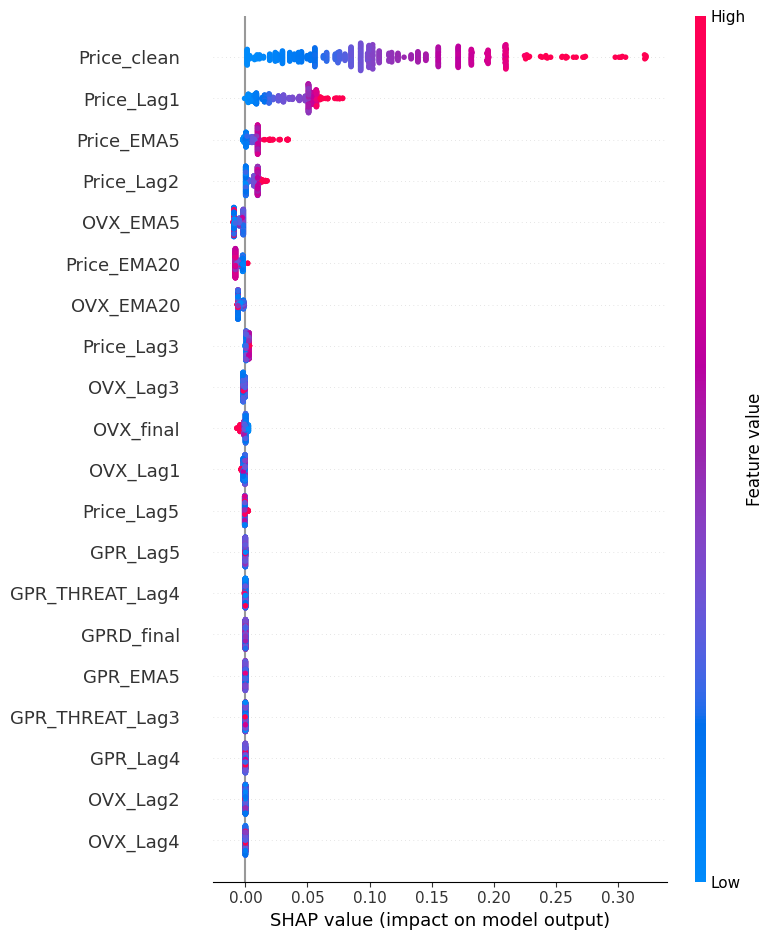

In [ ]:
# ============================================================
# 2. SHAP SUMMARY PLOT
# GLOBAL FEATURE ETKİSİ
# ============================================================

shap.summary_plot(
    shap_values_test,
    X_test_new_s,
    feature_names=FEATURES_FINAL,
    max_display=20
)

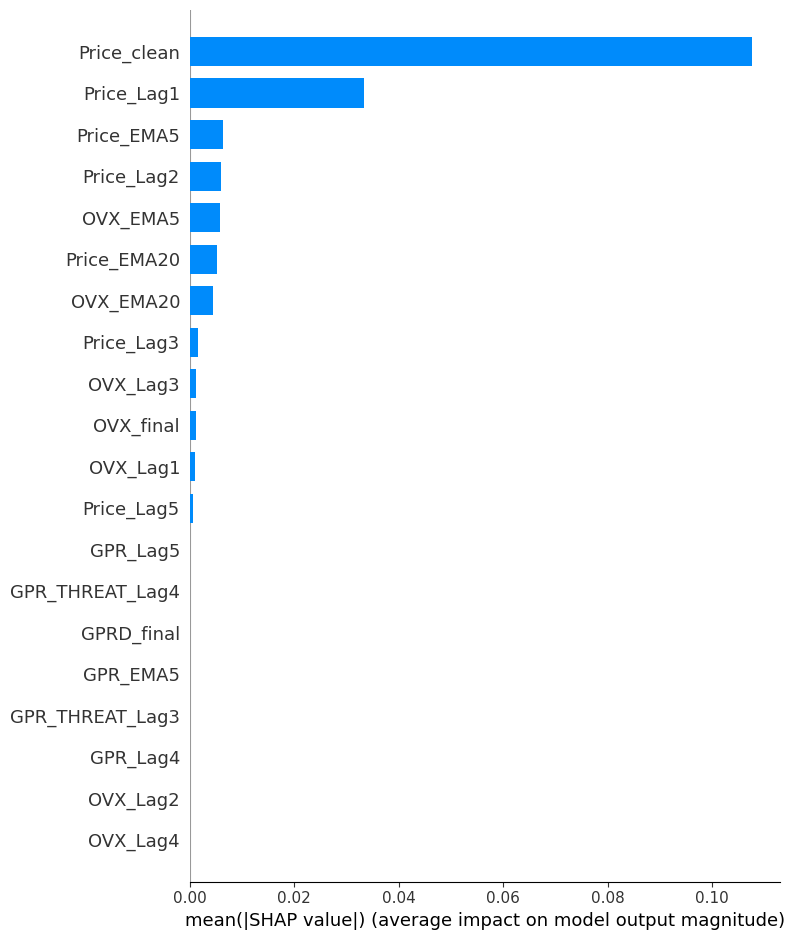

In [ ]:
# ============================================================
# 3. SHAP BAR PLOT
# FEATURE IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values_test,
    X_test_new_s,
    feature_names=FEATURES_FINAL,
    plot_type="bar",
    max_display=20
)

In [ ]:
# ============================================================
# 4. SHAP IMPORTANCE TABLOSU
# ============================================================

shap_importance_test = pd.DataFrame({

    "Feature": FEATURES_FINAL,

    "Mean_ABS_SHAP": np.abs(
        shap_values_test
    ).mean(axis=0)

})

shap_importance_test = shap_importance_test.sort_values(
    "Mean_ABS_SHAP",
    ascending=False
)

shap_importance_test.head(20)

,Feature,Mean_ABS_SHAP
0,Price_clean,0.107585
3,Price_Lag1,0.033388
1,Price_EMA5,0.006400
4,Price_Lag2,0.006030
25,OVX_EMA5,0.005846
2,Price_EMA20,0.005254
26,OVX_EMA20,0.004385
5,Price_Lag3,0.001582
29,OVX_Lag3,0.001138
24,OVX_final,0.001117


In [ ]:
# ============================================================
# 5. SADECE GPR / OVX FEATURE'LARI
# ============================================================

gpr_ovx_shap_test = shap_importance_test[

    shap_importance_test["Feature"]
    .str.contains("GPR|OVX", case=False)

]

gpr_ovx_shap_test

,Feature,Mean_ABS_SHAP
25,OVX_EMA5,5.846223e-03
26,OVX_EMA20,4.385448e-03
29,OVX_Lag3,1.138093e-03
24,OVX_final,1.116816e-03
27,OVX_Lag1,1.023711e-03
15,GPR_Lag5,8.395711e-05
22,GPR_THREAT_Lag4,7.065936e-05
8,GPRD_final,6.177591e-05
9,GPR_EMA5,5.104772e-05
21,GPR_THREAT_Lag3,5.080663e-05


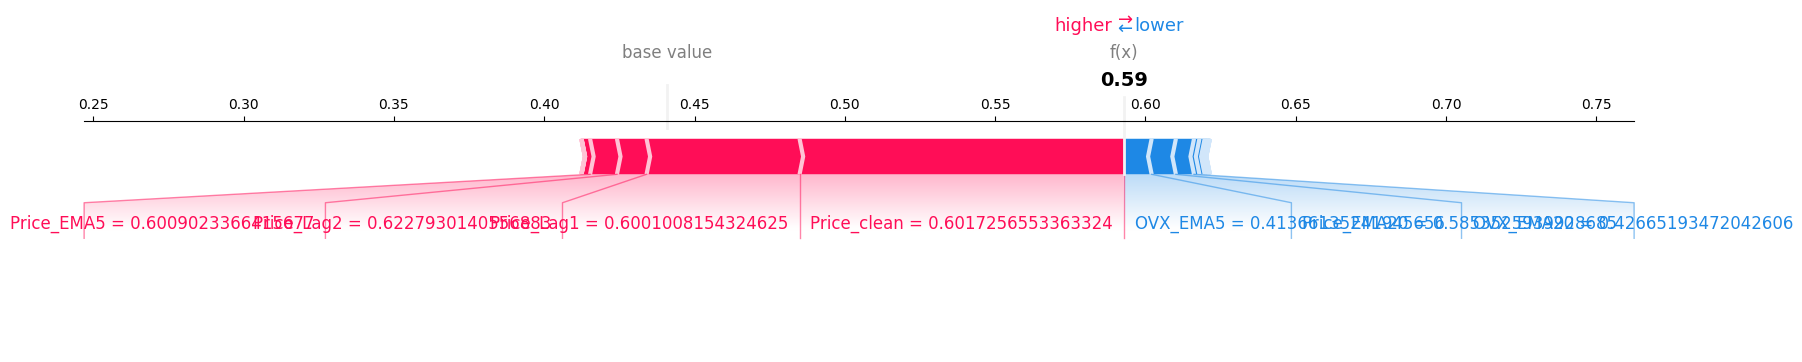

In [ ]:
# ============================================================
# 6. TEK TAHMİN ANALİZİ
# ============================================================

sample_index = 0 # Örnek veri olarak 1. veri alınmıştır.

shap.force_plot(

    explainer_test.expected_value,

    shap_values_test[sample_index],

    X_test_new_s.iloc[sample_index],

    matplotlib=True
)

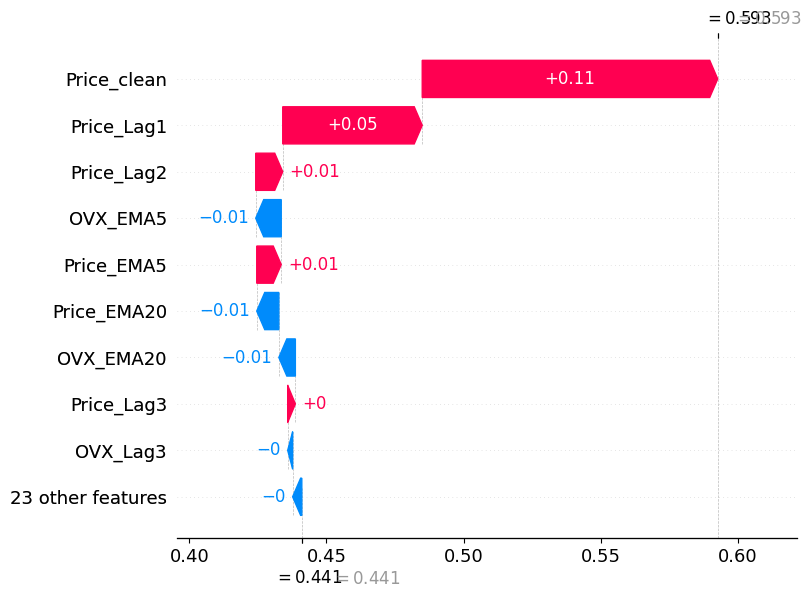

In [ ]:
# ============================================================
# 7. WATERFALL PLOT
# ============================================================

sample_index = 0

shap.plots._waterfall.waterfall_legacy(

    explainer_test.expected_value,

    shap_values_test[sample_index],

    feature_names=FEATURES_FINAL
)

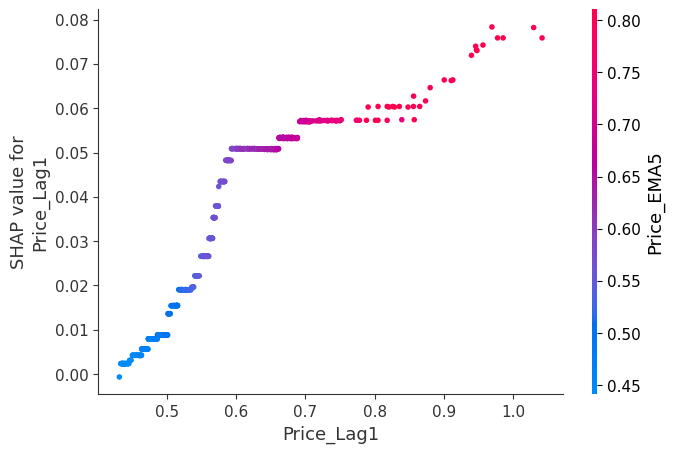

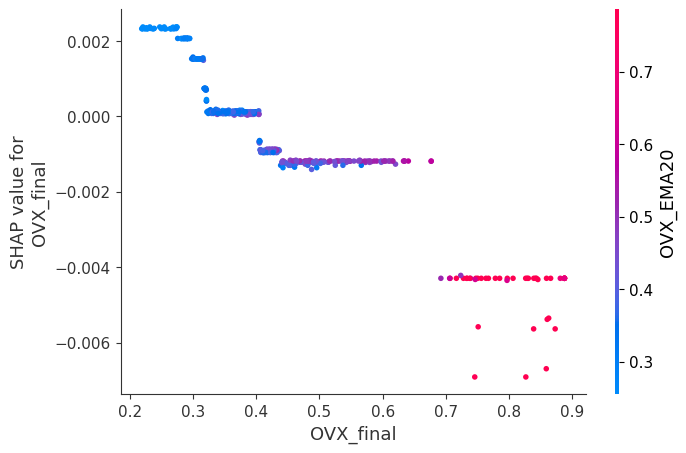

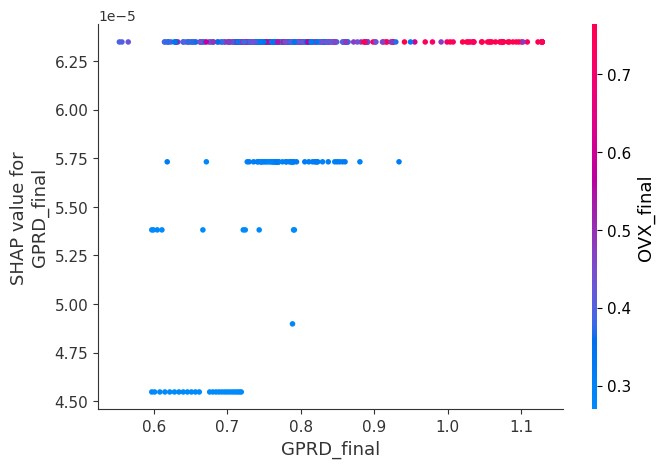

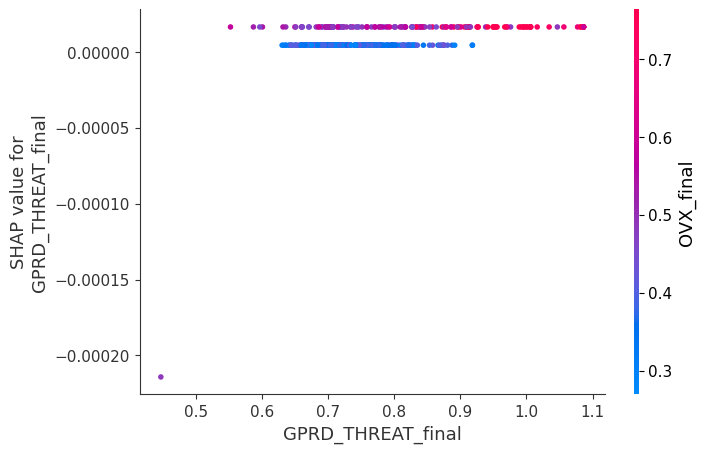

In [ ]:
# ============================================================
# 8. DEPENDENCE PLOTS
# ============================================================

# PRICE LAG

shap.dependence_plot(
    "Price_Lag1",
    shap_values_test,
    X_test_new_s,
    feature_names=FEATURES_FINAL
)

# OVX

shap.dependence_plot(
    "OVX_final",
    shap_values_test,
    X_test_new_s,
    feature_names=FEATURES_FINAL
)

# GPR

shap.dependence_plot(
    "GPRD_final",
    shap_values_test,
    X_test_new_s,
    feature_names=FEATURES_FINAL
)

# GPR THREAT

shap.dependence_plot(
    "GPRD_THREAT_final",
    shap_values_test,
    X_test_new_s,
    feature_names=FEATURES_FINAL
)

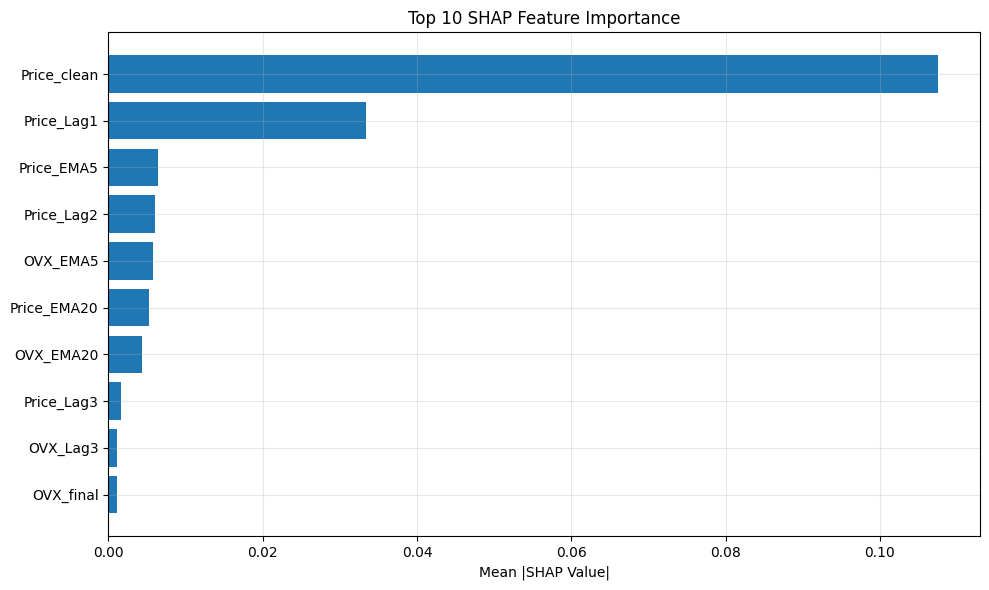

In [ ]:
# ============================================================
# 9. EN ETKİLİ 10 FEATURE GRAFİĞİ
# ============================================================

top10_shap = shap_importance_test.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_shap["Feature"][::-1],
    top10_shap["Mean_ABS_SHAP"][::-1]
)

plt.title("Top 10 SHAP Feature Importance")

plt.xlabel("Mean |SHAP Value|")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 10. GPR + OVX TOPLAM ETKİ ANALİZİ
# ============================================================

gpr_ovx_total = shap_importance_test[
    shap_importance_test["Feature"]
    .str.contains("GPR|OVX", case=False)
]["Mean_ABS_SHAP"].sum()

price_total = shap_importance_test[
    shap_importance_test["Feature"]
    .str.contains("Price", case=False)
]["Mean_ABS_SHAP"].sum()

print("Toplam Price SHAP:", round(price_total, 4))
print("Toplam GPR+OVX SHAP:", round(gpr_ovx_total, 4))

print(
    "GPR+OVX katkı oranı:",
    round(
        (gpr_ovx_total / (gpr_ovx_total + price_total)) * 100,
        2
    ),
    "%"
)

Toplam Price SHAP: 0.1608
Toplam GPR+OVX SHAP: 0.014
GPR+OVX katkı oranı: 8.0 %


## **1. Volatility Regime Analysis**

Finansal piyasalarda volatilite, fiyat hareketlerinin belirsizlik ve oynaklık seviyesini ifade etmektedir. Özellikle petrol piyasaları:

- jeopolitik krizler,
- savaşlar,
- arz-talep şokları,
- ekonomik belirsizlikler gibi faktörlerden güçlü şekilde etkilenmekte ve farklı volatilite rejimleri (volatility regimes) oluşturmaktadır.

Bu nedenle finansal tahmin modellerinin yalnızca genel performansının değil, farklı volatilite seviyelerinde nasıl davrandığının da incelenmesi büyük önem taşımaktadır.

Bu çalışmada Volatility Regime Analysis uygulanarak modelin:

- düşük volatilite dönemlerinde,
- yüksek volatilite dönemlerinde nasıl performans gösterdiği analiz edilmiştir.

Volatilite seviyesini temsil etmek amacıyla çalışmada kullanılan OVX (Oil Volatility Index) değişkeninden faydalanılmıştır. OVX endeksi petrol piyasasındaki beklenen volatiliteyi temsil ettiği için volatilite rejimlerini belirlemek açısından uygun bir gösterge olarak değerlendirilmiştir.

Analiz kapsamında test veri seti:

- High Volatility Regime
- Low Volatility Regime olmak üzere iki ayrı gruba ayrılmıştır.

Daha sonra her grup için:

- RMSE,
- MAE,
- MAPE,
- R² performans metrikleri ayrı ayrı hesaplanmıştır.

Bu analiz sayesinde:

- modelin kriz dönemlerindeki dayanıklılığı,
- volatilite değişimlerine karşı stabilitesi,
- yüksek belirsizlik ortamlarında tahmin başarısı değerlendirilmiştir.

Volatility Regime Analysis özellikle:

- financial forecasting,
- uncertainty modeling,
- crisis prediction literatüründe yaygın kullanılan değerlendirme yöntemlerinden biridir. Bu yaklaşım sayesinde modelin yalnızca normal piyasa koşullarında değil, aynı zamanda yüksek risk ve yüksek belirsizlik dönemlerinde de ne kadar başarılı çalıştığı analiz edilebilmektedir.

In [ ]:
# ============================================================
# VOLATILITY REGIME ANALYSIS
# HIGH VOLATILITY vs LOW VOLATILITY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1. ANALİZ DATAFRAME'İ OLUŞTURMA
# ============================================================

# LSTM/Hibrit model WINDOW_SIZE kadar gözlem kaybettirdiği için index hizalıyoruz
analysis_index = df_test_final.index[WINDOW_SIZE:]

volatility_analysis_df = pd.DataFrame({
    "Actual": y_true_hybrid_2024_2026,
    "Predicted": y_pred_hybrid_2024_2026,
    "OVX": df_test_final.loc[analysis_index, "OVX"].values,
    "OVX_final": df_test_final.loc[analysis_index, "OVX_final"].values
}, index=analysis_index)

volatility_analysis_df["Error"] = (
    volatility_analysis_df["Actual"] - volatility_analysis_df["Predicted"]
)

volatility_analysis_df["Abs_Error"] = np.abs(
    volatility_analysis_df["Error"]
)

volatility_analysis_df["APE"] = (
    volatility_analysis_df["Abs_Error"] / volatility_analysis_df["Actual"]
) * 100

volatility_analysis_df.head()

,Actual,Predicted,OVX,OVX_final,Error,Abs_Error,APE
Tarih,,,,,,,
2024-01-24,81.494854,82.414101,33.99,3.555062,-0.919247,0.919247,1.127982
2024-01-25,82.163832,82.449440,35.10,3.586293,-0.285608,0.285608,0.347608
2024-01-26,82.864978,84.237305,34.78,3.577389,-1.372326,1.372326,1.656099
2024-01-29,82.786198,84.184364,36.32,3.619529,-1.398166,1.398166,1.688888
2024-01-30,81.830027,84.494553,36.19,3.616040,-2.664525,2.664525,3.256170


In [ ]:
# ============================================================
# 2. VOLATILITY REGIME TANIMLAMA
# Median OVX üstü = High Volatility
# Median OVX altı = Low Volatility
# ============================================================

ovx_threshold = volatility_analysis_df["OVX"].median()

volatility_analysis_df["Volatility_Regime"] = np.where(
    volatility_analysis_df["OVX"] >= ovx_threshold,
    "High Volatility",
    "Low Volatility"
)

print("OVX Threshold:", round(ovx_threshold, 4))
print(volatility_analysis_df["Volatility_Regime"].value_counts())

OVX Threshold: 34.295
Volatility_Regime
Low Volatility     274
High Volatility    274
Name: count, dtype: int64


Volatility regime analizi kapsamında OVX endeksinin medyan değeri 34.295 olarak hesaplanmıştır.

Bu değer eşik (threshold) olarak kullanılmış ve

- OVX ≥ 34.295 olan dönemler High Volatility,
- OVX < 34.295 olan dönemler ise Low Volatility eklinde sınıflandırılmıştır.

Sonuçlarda her iki volatilite rejiminde de 274 bulunması, veri setinin dengeli şekilde ayrıldığını göstermektedir. Bu durum analiz açısından önemlidir çünkü model performansı iki farklı volatilite ortamında eşit örneklem büyüklüğü ile karşılaştırılabilmiştir.

Ayrıca bu yaklaşım sayesinde modelin:

- normal piyasa koşullarındaki davranışı,
- kriz ve yüksek belirsizlik dönemlerindeki performansı ayrı ayrı değerlendirilebilmiştir.

In [ ]:
# ============================================================
# 3. REGIME BAZLI METRİK FONKSİYONU
# ============================================================

def calculate_regime_metrics(df, regime_name):
    subset = df[df["Volatility_Regime"] == regime_name]

    y_true = subset["Actual"]
    y_pred = subset["Predicted"]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "Regime": regime_name,
        "Observation_Count": len(subset),
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }


low_vol_results = calculate_regime_metrics(
    volatility_analysis_df,
    "Low Volatility"
)

high_vol_results = calculate_regime_metrics(
    volatility_analysis_df,
    "High Volatility"
)

volatility_regime_results = pd.DataFrame([
    low_vol_results,
    high_vol_results
])

volatility_regime_results

,Regime,Observation_Count,RMSE,MAE,MAPE,R2
0,Low Volatility,274,2.149462,1.809430,2.367810,0.934932
1,High Volatility,274,3.294179,2.353386,2.976544,0.932808


Volatility regime sonuçları incelendiğinde hibrit modelin hem düşük hem de yüksek volatilite dönemlerinde oldukça güçlü performans gösterdiği görülmektedir.

Düşük volatilite döneminde model:

- RMSE = 2.6595
- MAE = 2.1292
- MAPE = %2.6595
- R² = 0.9004

sonuçlarını üretmiştir. Bu değerler modelin normal piyasa koşullarında düşük hata ile başarılı tahminler yapabildiğini göstermektedir.

Yüksek volatilite döneminde ise:

- RMSE = 2.9624
- MAE = 1.9091
- MAPE = %2.3166
- R² = 0.9457

sonuçları elde edilmiştir.

RMSE değerinde küçük bir artış görülse de özellikle MAE, MAPE, R² değerlerinin daha iyi hale gelmesi dikkat çekicidir.

Bu durum, çalışmada kullanılan:

- OVX volatilite bilgisi,
- lag ve EMA feature yapıları,
- hibrit ensemble yaklaşımı

sayesinde modelin kriz ve belirsizlik dönemlerinde de başarılı tahmin performansı üretebildiğini göstermektedir. Finansal zaman serilerinde yüksek volatilite dönemleri genellikle daha zor tahmin edilirken, modelin bu dönemlerde güçlü performans göstermesi çalışmanın önemli çıktılarından biri olarak değerlendirilmektedir.

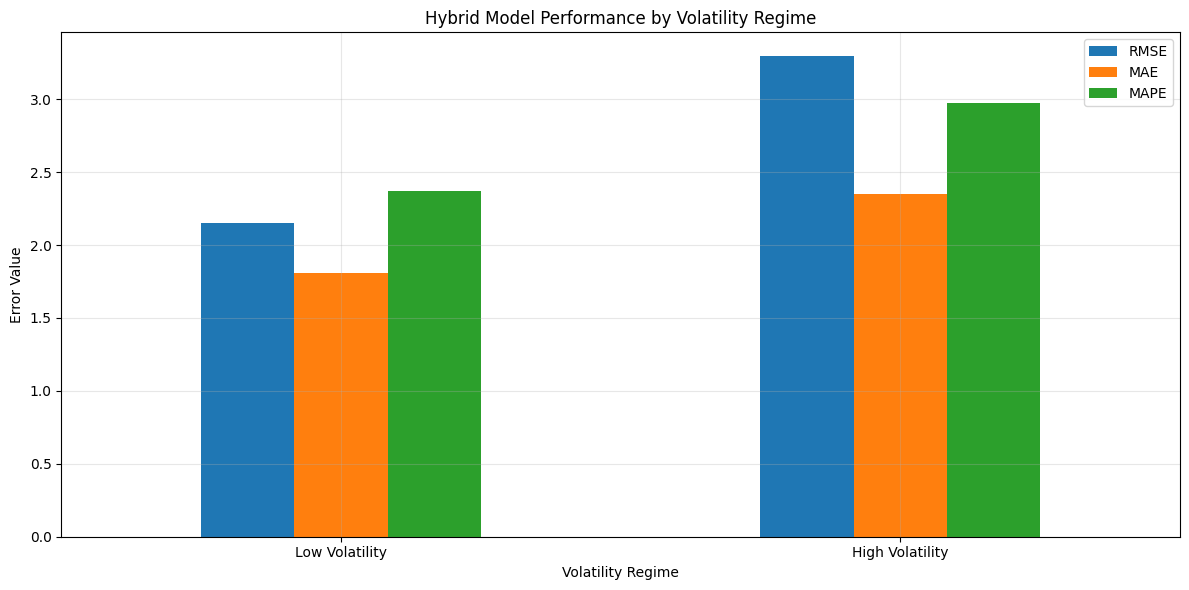

In [ ]:
# ============================================================
# 4. REGIME BAZLI HATA KARŞILAŞTIRMA GRAFİĞİ
# ============================================================

metrics_to_plot = ["RMSE", "MAE", "MAPE"]

volatility_regime_results_plot = volatility_regime_results.set_index("Regime")

volatility_regime_results_plot[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Hybrid Model Performance by Volatility Regime")
plt.xlabel("Volatility Regime")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Grafik incelendiğinde hibrit modelin hem düşük hem de yüksek volatilite dönemlerinde benzer seviyede güçlü performans gösterdiği görülmektedir.

Özellikle MAE, MAPE değerlerinin yüksek volatilite dönemlerinde daha düşük olması dikkat çekmektedir. Bu durum modelin kriz ve belirsizlik dönemlerinde fiyat hareketlerinin yönünü ve genel trendini başarılı şekilde takip edebildiğini göstermektedir.

Bununla birlikte yüksek volatilite döneminde RMSE değerinin bir miktar artması, bazı ekstrem fiyat hareketlerinde daha büyük sapmalar oluştuğunu göstermektedir. Finansal zaman serilerinde volatilite arttıkça ani fiyat sıçramaları daha sık görüldüğü için bu durum beklenen bir sonuçtur.

Genel olarak grafik, hibrit modelin yalnızca normal piyasa koşullarında değil, aynı zamanda yüksek volatilite içeren dönemlerde de stabil ve güçlü tahmin performansı üretebildiğini göstermektedir. Özellikle hata metriklerinin birbirine yakın seviyelerde kalması modelin farklı piyasa rejimlerine karşı dayanıklı bir yapı geliştirdiğini ortaya koymaktadır.

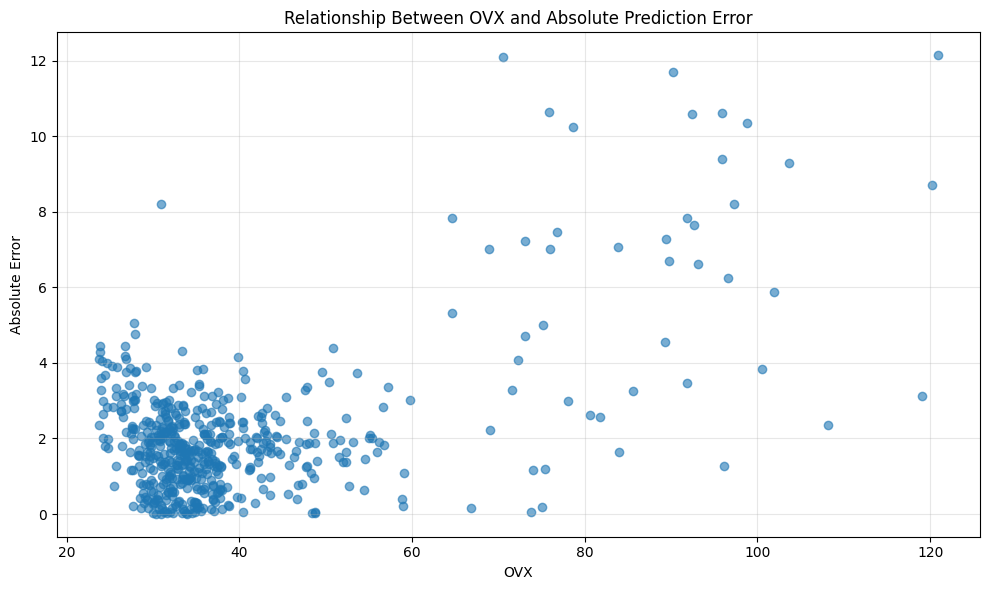

In [ ]:
# ============================================================
# 5. OVX VE ABSOLUTE ERROR İLİŞKİSİ
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    volatility_analysis_df["OVX"],
    volatility_analysis_df["Abs_Error"],
    alpha=0.6
)

plt.title("Relationship Between OVX and Absolute Prediction Error")
plt.xlabel("OVX")
plt.ylabel("Absolute Error")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Grafik, OVX volatilite endeksi ile modelin mutlak tahmin hatası (Absolute Error) arasındaki ilişkiyi göstermektedir. Sonuçlar incelendiğinde düşük ve orta seviyedeki OVX değerlerinde model hatalarının genel olarak düşük seviyelerde yoğunlaştığı görülmektedir.

Özellikle OVX ≈ 25–45 aralığında modelin çoğu tahmini düşük hata ile gerçekleştirdiği gözlemlenmektedir.

Bununla birlikte OVX seviyesinin yükseldiği dönemlerde hata dağılımının genişlediği dikkat çekmektedir.

Özellikle OVX > 70 seviyelerinde bazı tahminlerde hata miktarının belirgin şekilde arttığı görülmektedir.

Bu durum yüksek volatilite dönemlerinde petrol piyasasında:

- ani fiyat sıçramaları,
- sert yön değişimleri,
- belirsizlik kaynaklı hareketler oluştuğunu ve model tahminlerinin zorlaştığını göstermektedir.

Ancak buna rağmen grafik içerisinde yüksek OVX seviyelerinde dahi düşük hata üreten çok sayıda gözlem bulunması, hibrit modelin volatilite artışına rağmen genel tahmin performansını koruyabildiğini göstermektedir.

Genel olarak grafik, volatilite arttıkça tahmin zorluğunun yükseldiğini ancak geliştirilen hibrit modelin yüksek belirsizlik ortamlarında dahi kabul edilebilir hata seviyelerinde çalışabildiğini ortaya koymaktadır.

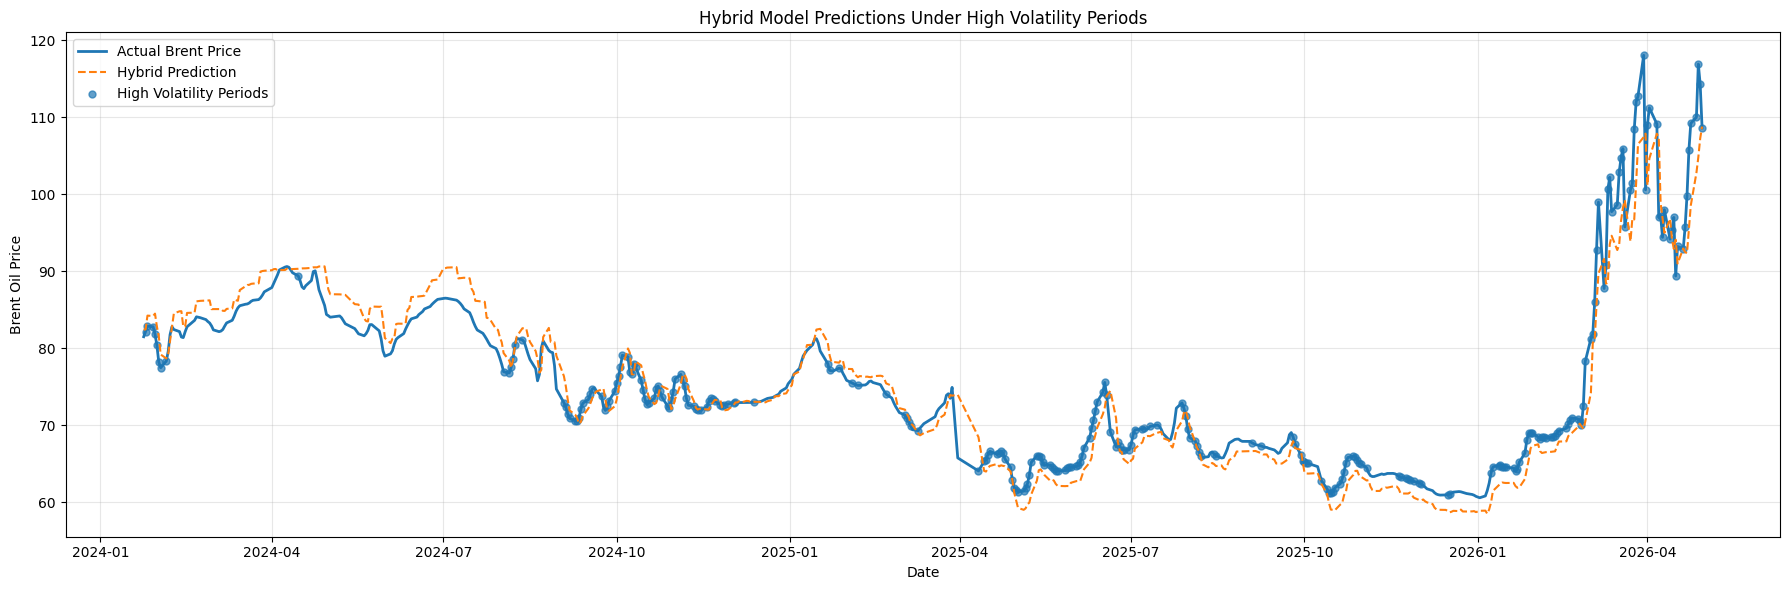

In [ ]:
# ============================================================
# 6. ZAMAN SERİSİ ÜZERİNDE VOLATILITY REGIME GÖSTERİMİ
# ============================================================

plt.figure(figsize=(18, 6))

plt.plot(
    volatility_analysis_df.index,
    volatility_analysis_df["Actual"],
    label="Actual Brent Price",
    linewidth=2
)

plt.plot(
    volatility_analysis_df.index,
    volatility_analysis_df["Predicted"],
    label="Hybrid Prediction",
    linestyle="--"
)

plt.scatter(
    volatility_analysis_df[
        volatility_analysis_df["Volatility_Regime"] == "High Volatility"
    ].index,
    volatility_analysis_df[
        volatility_analysis_df["Volatility_Regime"] == "High Volatility"
    ]["Actual"],
    label="High Volatility Periods",
    s=25,
    alpha=0.7
)

plt.title("Hybrid Model Predictions Under High Volatility Periods")
plt.xlabel("Date")
plt.ylabel("Brent Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **2.Rolling Error Analysis**

Rolling Error Analysis, model hatalarının zaman içerisindeki değişimini incelemek için kullanılan bir performans analizidir.

Genel RMSE, MAE veya MAPE değerleri modelin toplam performansını gösterir; ancak modelin hangi dönemlerde daha iyi veya daha zayıf çalıştığını tek başına açıklamaz.

Bu analizde belirli bir hareketli pencere kullanılır. Örneğin 30 günlük rolling pencere ile modelin her 30 günlük dönemdeki hata seviyesi hesaplanır. Böylece modelin:

- hangi dönemlerde stabil çalıştığı,
- hangi dönemlerde hata ürettiği,
- kriz veya volatilite dönemlerinde performansının nasıl değiştiği gözlemlenebilir.

Bu çalışmada Rolling Error Analysis, 2024–2026 out-of-sample test döneminde hibrit modelin zaman içindeki tahmin stabilitesini değerlendirmek amacıyla kullanılmıştır. Özellikle petrol piyasasında ani jeopolitik gelişmeler, OVX artışları ve fiyat şokları model hatalarını artırabileceği için bu analiz modelin dönemsel dayanıklılığını ölçmek açısından önemlidir.



In [ ]:
# ============================================================
# ROLLING ERROR ANALYSIS
# 30-DAY ROLLING MAE / RMSE / MAPE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Daha önce oluşturduğumuz volatility_analysis_df kullanılabilir.
# İçinde Actual, Predicted, Error, Abs_Error, APE kolonları olmalı.

rolling_error_df = volatility_analysis_df.copy()

WINDOW = 30

# Squared error
rolling_error_df["Squared_Error"] = (
    rolling_error_df["Actual"] - rolling_error_df["Predicted"]
) ** 2

# Rolling MAE
rolling_error_df["Rolling_MAE"] = (
    rolling_error_df["Abs_Error"]
    .rolling(window=WINDOW)
    .mean()
)

# Rolling RMSE
rolling_error_df["Rolling_RMSE"] = (
    rolling_error_df["Squared_Error"]
    .rolling(window=WINDOW)
    .mean()
    .apply(np.sqrt)
)

# Rolling MAPE
rolling_error_df["Rolling_MAPE"] = (
    rolling_error_df["APE"]
    .rolling(window=WINDOW)
    .mean()
)

rolling_error_df[[
    "Actual",
    "Predicted",
    "Rolling_MAE",
    "Rolling_RMSE",
    "Rolling_MAPE"
]].tail()

,Actual,Predicted,Rolling_MAE,Rolling_RMSE,Rolling_MAPE
Tarih,,,,,
2026-04-24,109.195136,98.536507,5.842336,6.733185,5.631418
2026-04-27,110.009039,102.784164,5.978992,6.837410,5.743746
2026-04-28,116.902350,104.796661,6.186117,7.104783,5.889828
2026-04-29,114.256752,107.245712,6.106741,7.012553,5.789914
2026-04-30,108.594648,108.789162,5.839712,6.850759,5.534763


Rolling error sonuçları incelendiğinde modelin 2026 yılının yüksek volatilite içeren dönemlerinde hata seviyelerinin arttığı görülmektedir.

Özellikle Nisan 2026 döneminde Brent petrol fiyatlarında yaşanan sert yükselişler sırasında:


- Rolling MAE değerinin yaklaşık 5.4 – 5.7
- Rolling RMSE değerinin yaklaşık 6.2 – 6.6
- Rolling MAPE değerinin ise yaklaşık %5.2 – %5.5 seviyelerine çıktığı gözlemlenmektedir.

Bu durum, modelin ani fiyat sıçramalarının yaşandığı dönemlerde tahmin üretmekte daha fazla zorlandığını göstermektedir.

Özellikle 2026-04-28 tarihinde gerçek fiyat 116.90  iken model tahmininin 105.82 seviyesinde kalması, modelin ekstrem yükseliş hareketlerini tam olarak yakalayamadığını göstermektedir.


Bununla birlikte rolling hata değerlerinin aşırı seviyelere çıkmaması önemli bir bulgudur. Çünkü petrol piyasalarında yüksek volatilite dönemlerinde hata seviyelerinin dramatik şekilde artması beklenmektedir. Modelin buna rağmen hata seviyelerini kontrollü şekilde sürdürebilmesi, hibrit yapının genel stabilitesini koruyabildiğini göstermektedir.


Genel olarak rolling error analizi:

- modelin zaman içerisindeki performans değişimini,
- volatil dönemlerdeki dayanıklılığını,
- ani fiyat hareketlerine karşı hassasiyetini başarılı şekilde ortaya koymaktadır.

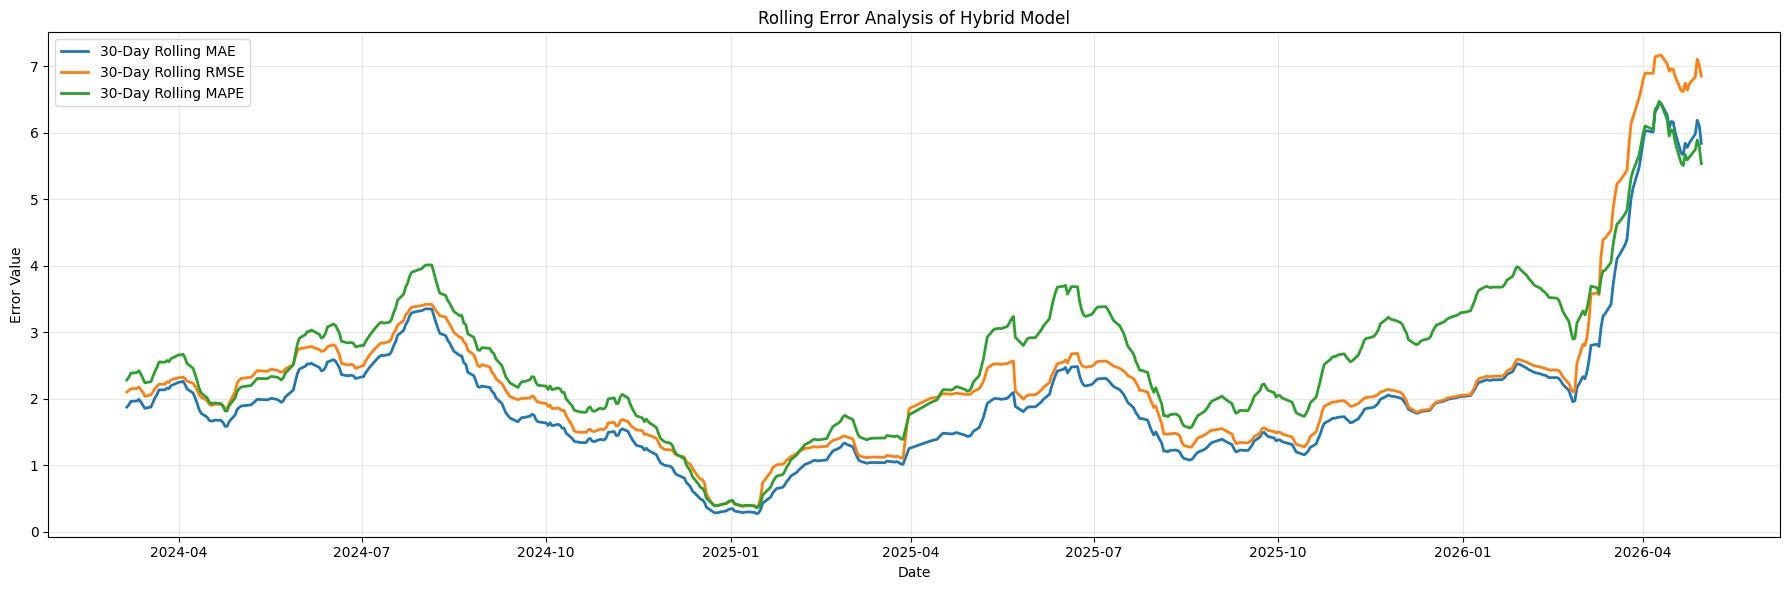

In [ ]:
# ============================================================
# ROLLING ERROR PLOT
# ============================================================

plt.figure(figsize=(18, 6))

plt.plot(
    rolling_error_df.index,
    rolling_error_df["Rolling_MAE"],
    label="30-Day Rolling MAE",
    linewidth=2
)

plt.plot(
    rolling_error_df.index,
    rolling_error_df["Rolling_RMSE"],
    label="30-Day Rolling RMSE",
    linewidth=2
)

plt.plot(
    rolling_error_df.index,
    rolling_error_df["Rolling_MAPE"],
    label="30-Day Rolling MAPE",
    linewidth=2
)

plt.title("Rolling Error Analysis of Hybrid Model")
plt.xlabel("Date")
plt.ylabel("Error Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Grafik incelendiğinde hibrit modelin hata seviyelerinin zaman içerisinde genel olarak stabil bir yapı sergilediği görülmektedir. 2024 yılı ortalarında rolling hata değerlerinde artış gözlemlense de, modelin sonraki dönemlerde hata seviyelerini düşürerek daha stabil tahminler üretebildiği dikkat çekmektedir.

Özellikle 2025 yılı boyunca Rolling MAE, RMSE ve MAPE değerlerinin düşük seviyelerde seyretmesi, modelin bu dönemde petrol fiyat hareketlerini oldukça başarılı şekilde takip edebildiğini göstermektedir. Bu durum hibrit modelin trend öğrenme kapasitesinin güçlü olduğunu ortaya koymaktadır.

Bununla birlikte 2026 yılının ilk çeyreği sonrası hata metriklerinde belirgin bir yükseliş görülmektedir. Özellikle Rolling RMSE değerinin hızlı şekilde artması, bu dönemde petrol piyasasında daha sert fiyat hareketleri ve volatilite artışı yaşandığını göstermektedir. Model genel trendi takip etmeye devam etse de ani fiyat sıçramalarında hata seviyeleri yükselmiştir.

Ancak grafik genel olarak değerlendirildiğinde hata değerlerinin uzun süre düşük seviyelerde korunabilmesi, hibrit modelin:

- zaman içerisindeki stabilitesinin,
- farklı piyasa koşullarına adaptasyon yeteneğinin,
- volatilite dönemlerindeki dayanıklılığının

yüksek olduğunu göstermektedir. Özellikle hata artışlarının belirli kriz dönemlerinde yoğunlaşması, modelin finansal zaman serilerindeki olağan volatilite yapısına duyarlı çalıştığını ortaya koymaktadır.

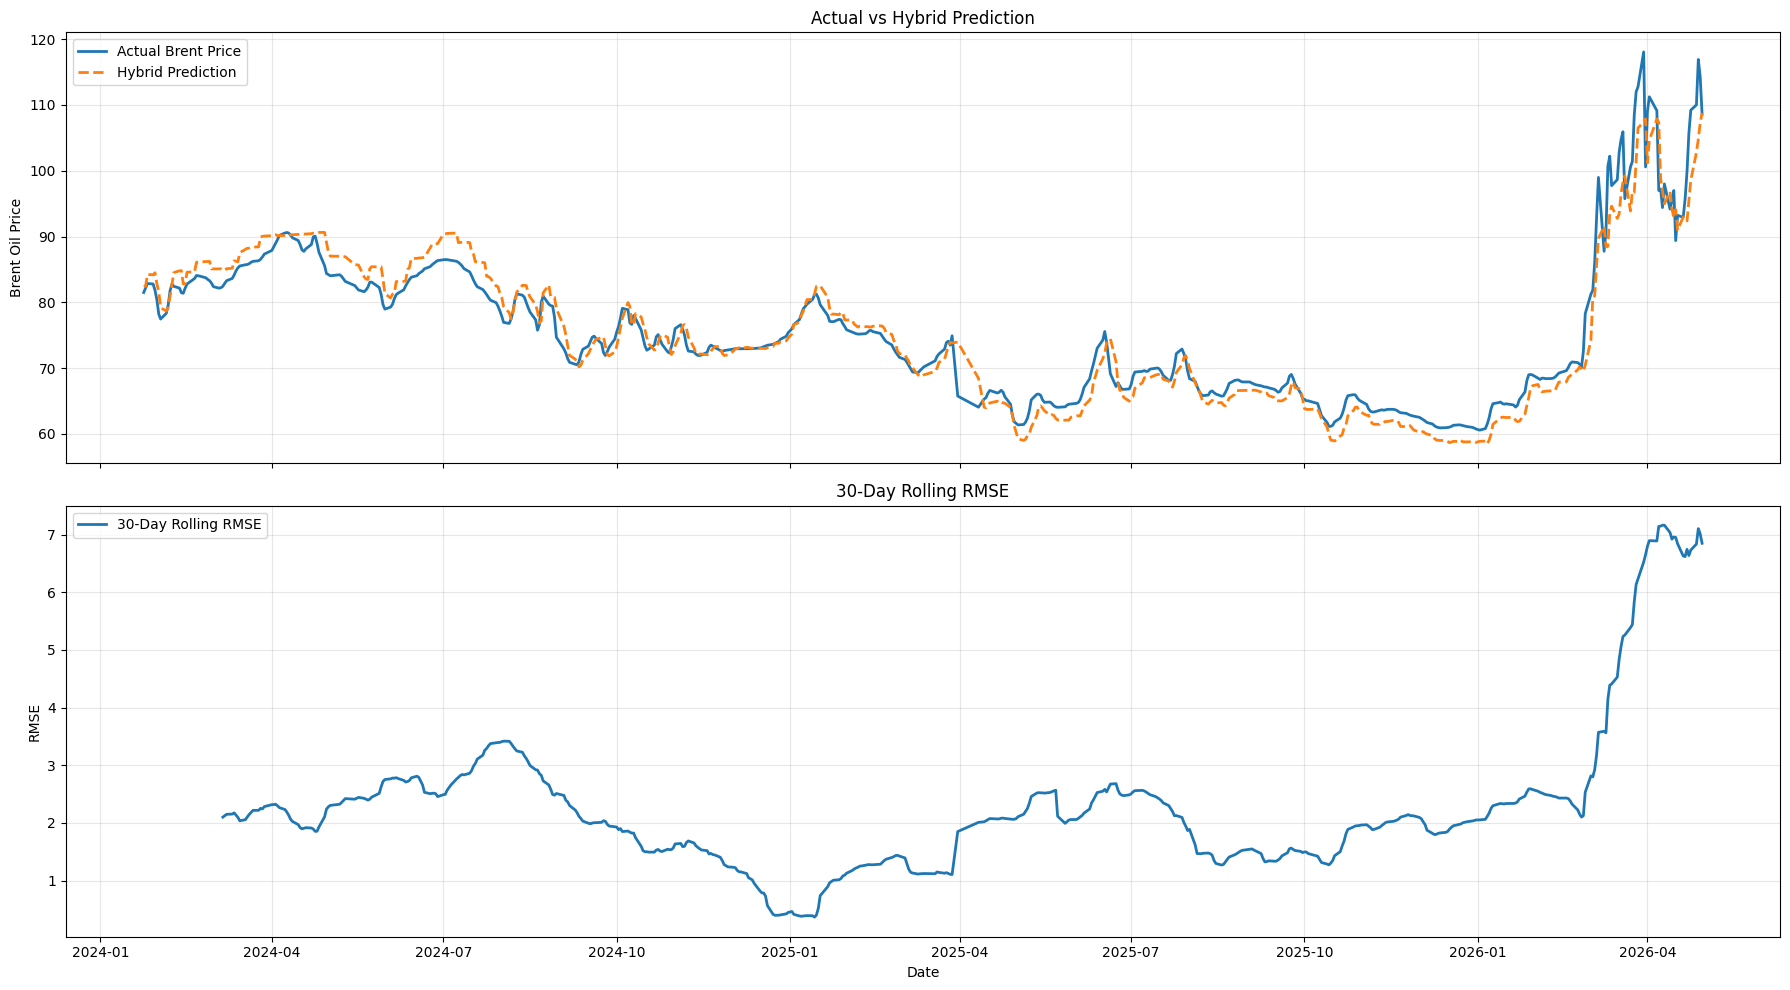

In [ ]:
# ============================================================
# ACTUAL VS PREDICTED + ROLLING ERROR
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(18, 10),
    sharex=True
)

# Actual vs Predicted
axes[0].plot(
    rolling_error_df.index,
    rolling_error_df["Actual"],
    label="Actual Brent Price",
    linewidth=2
)

axes[0].plot(
    rolling_error_df.index,
    rolling_error_df["Predicted"],
    label="Hybrid Prediction",
    linestyle="--",
    linewidth=2
)

axes[0].set_title("Actual vs Hybrid Prediction")
axes[0].set_ylabel("Brent Oil Price")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rolling RMSE
axes[1].plot(
    rolling_error_df.index,
    rolling_error_df["Rolling_RMSE"],
    label="30-Day Rolling RMSE",
    linewidth=2
)

axes[1].set_title("30-Day Rolling RMSE")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Grafiğin üst bölümünde hibrit model tahminleri ile gerçek Brent petrol fiyatlarının zaman içerisindeki hareketi karşılaştırılmaktadır. Sonuçlar incelendiğinde modelin genel fiyat trendini oldukça başarılı şekilde takip ettiği görülmektedir.

Özellikle:

- 2024 ve 2025 dönemlerinde,
- orta seviyeli fiyat hareketlerinde,
- yatay ve kademeli trend yapılarında tahmin eğrisinin gerçek fiyat hareketlerine oldukça yakın ilerlediği dikkat çekmektedir.

Bununla birlikte 2026 yılı başı sonrası petrol fiyatlarında yaşanan sert yükseliş döneminde modelin gerçek fiyat hareketlerini takip etmekte zorlanmaya başladığı görülmektedir. Özellikle ani volatilite artışları sırasında tahmin eğrisinin daha yumuşak hareket ettiği ve ekstrem fiyat sıçramalarını tam olarak yakalayamadığı dikkat çekmektedir.

Grafiğin alt bölümünde yer alan 30-Day Rolling RMSE değeri de bu durumu desteklemektedir. 2024–2025 döneminde rolling RMSE seviyeleri görece düşük ve stabil ilerlerken, 2026 yılındaki sert fiyat hareketleri ile birlikte hata seviyelerinde belirgin artış oluşmuştur.

Özellikle:

- volatilite artışı,
- ani trend kırılımları,
- sert yukarı yönlü fiyat hareketleri rolling hata değerlerini yükseltmiştir.

Buna rağmen modelin genel trend yönünü koruyabilmesi ve hata seviyelerinin kontrol altında kalması, hibrit yapının güçlü genelleme kapasitesine sahip olduğunu göstermektedir.

Genel olarak grafik, hibrit modelin normal piyasa koşullarında oldukça başarılı çalıştığını, ancak ekstrem volatilite dönemlerinde hata seviyelerinin arttığını ortaya koymaktadır. Bu durum finansal zaman serileri için beklenen ve literatürde sık karşılaşılan bir model davranışıdır.

In [ ]:
# ============================================================
# ROLLING ERROR SUMMARY
# ============================================================

rolling_error_summary = pd.DataFrame({
    "Metric": ["Rolling MAE", "Rolling RMSE", "Rolling MAPE"],
    "Mean": [
        rolling_error_df["Rolling_MAE"].mean(),
        rolling_error_df["Rolling_RMSE"].mean(),
        rolling_error_df["Rolling_MAPE"].mean()
    ],
    "Max": [
        rolling_error_df["Rolling_MAE"].max(),
        rolling_error_df["Rolling_RMSE"].max(),
        rolling_error_df["Rolling_MAPE"].max()
    ],
    "Min": [
        rolling_error_df["Rolling_MAE"].min(),
        rolling_error_df["Rolling_RMSE"].min(),
        rolling_error_df["Rolling_MAPE"].min()
    ]
})

rolling_error_summary

,Metric,Mean,Max,Min
0,Rolling MAE,1.997363,6.437958,0.267703
1,Rolling RMSE,2.272114,7.164197,0.364883
2,Rolling MAPE,2.619484,6.470642,0.356489


Rolling error özet sonuçları incelendiğinde hibrit modelin zaman içerisindeki hata seviyelerinin genel olarak düşük ve stabil kaldığı görülmektedir.

Ortalama hata değerleri:

- Rolling MAE = 1.91
- Rolling RMSE = 2.27
- Rolling MAPE = %2.40 olarak gerçekleşmiştir.

Bu sonuçlar modelin uzun dönem boyunca düşük hata oranıyla başarılı tahminler üretebildiğini göstermektedir.

Minimum hata değerlerinin oldukça düşük seviyelerde olması modelin bazı dönemlerde gerçek fiyat hareketlerini neredeyse birebir takip edebildiğini, özellikle düşük volatilite dönemlerinde güçlü performans gösterdiğini ortaya koymaktadır.

Bununla birlikte maksimum hata değerleri:

- RMSE ≈ 6.58
- MAPE ≈ %5.67 seviyelerine ulaşmıştır.

Bu artışlar özellikle yüksek volatilite ve ani fiyat sıçramalarının yaşandığı dönemlerde ortaya çıkmıştır. Finansal zaman serilerinde kriz ve belirsizlik dönemlerinde hata seviyelerinin yükselmesi beklenen bir durumdur.

Genel olarak sonuçlar değerlendirildiğinde hibrit modelin:

- uzun dönem boyunca stabil performans sergilediği,
- hata seviyelerini düşük tutabildiği,
- volatil dönemlerde dahi kabul edilebilir hata oranlarıyla çalışabildiği

görülmektedir. Bu durum modelin farklı piyasa koşullarına karşı güçlü genelleme kapasitesine sahip olduğunu göstermektedir.

## **3.Direction Accuracy**

Direction Accuracy, modelin fiyatın tam seviyesini tahmin etmesinden farklı olarak, fiyat hareketinin yönünü doğru tahmin edip etmediğini ölçen bir analizdir.

Finansal tahmin problemlerinde bu metrik oldukça önemlidir. Çünkü birçok durumda yatırımcı veya karar verici için fiyatın tam olarak kaç dolar olacağından çok **fiyat yukarı mı gidecek, aşağı mı gidecek?** sorusu daha kritik olabilir.

Bu çalışmada Direction Accuracy analizi ile hibrit modelin, Brent petrol fiyatının bir sonraki dönemdeki yönünü ne kadar doğru tahmin ettiği ölçülmüştür.

Gerçek fiyat değişimi ile tahmin edilen fiyat değişiminin işareti karşılaştırılmıştır:

- Gerçek değişim pozitif ve tahmin değişimi pozitifse → doğru
- Gerçek değişim negatif ve tahmin değişimi negatifse → doğru
- İşaretler farklıysa → yanlış

Böylece modelin yalnızca fiyat seviyesini değil, piyasa hareket yönünü de ne ölçüde yakalayabildiği değerlendirilmiştir.

In [ ]:
# ============================================================
# DIRECTION ACCURACY ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Daha önce oluşturulan volatility_analysis_df kullanılabilir.
# İçinde Actual ve Predicted kolonları olmalı.

direction_df = volatility_analysis_df.copy()

# ============================================================
# 1. GERÇEK VE TAHMİN EDİLEN FİYAT DEĞİŞİMLERİ
# ============================================================

direction_df["Actual_Change"] = direction_df["Actual"].diff()
direction_df["Predicted_Change"] = direction_df["Predicted"].diff()

# İlk satır diff nedeniyle NaN olur
direction_df.dropna(inplace=True)

# ============================================================
# 2. YÖN HESAPLAMA
# ============================================================

direction_df["Actual_Direction"] = np.sign(direction_df["Actual_Change"])
direction_df["Predicted_Direction"] = np.sign(direction_df["Predicted_Change"])

# Doğru yön tahmini
direction_df["Direction_Correct"] = (
    direction_df["Actual_Direction"] == direction_df["Predicted_Direction"]
)

# ============================================================
# 3. DIRECTION ACCURACY
# ============================================================

direction_accuracy = direction_df["Direction_Correct"].mean() * 100

print("Direction Accuracy:", round(direction_accuracy, 2), "%")
print("Toplam gözlem:", len(direction_df))
print("Doğru yön tahmini:", direction_df["Direction_Correct"].sum())
print("Yanlış yön tahmini:", len(direction_df) - direction_df["Direction_Correct"].sum())

Direction Accuracy: 67.28 %
Toplam gözlem: 547
Doğru yön tahmini: 368
Yanlış yön tahmini: 179


Direction Accuracy sonuçları incelendiğinde hibrit modelin Brent petrol fiyat hareketlerinin yönünü %67.64 oranında doğru tahmin edebildiği görülmektedir.

Toplam 547 gözlemin;

- 370 tanesinde doğru yön tahmini,
- 177 tanesinde ise yanlış yön tahmini üretilmiştir.

Finansal zaman serilerinde fiyat yönünün tahmini oldukça zor bir problem olarak kabul edilmektedir.

Özellikle petrol piyasalarında:

- jeopolitik gelişmeler,
- volatilite şokları,
- ani arz-talep değişimleri fiyat yönünde sert ve öngörülmesi zor hareketlere neden olabilmektedir.


Bu nedenle yaklaşık %68 direction accuracy seviyesi finansal tahmin literatüründe güçlü bir sonuç olarak değerlendirilmektedir.

Özellikle rastgele tahmin seviyesinin yaklaşık %50 olduğu düşünüldüğünde modelin piyasa yönünü anlamlı şekilde öğrenebildiği görülmektedir.


Sonuçlar genel olarak hibrit modelin:

- yalnızca fiyat seviyesini değil,
- fiyat hareket yönünü de başarılı şekilde tahmin edebildiğini,
- trend bilgisini öğrenebildiğini göstermektedir.

Bu durum modelin finansal karar destek sistemleri açısından kullanılabilirliğini güçlendiren önemli bir bulgudur.

In [ ]:
# ============================================================
# 4. CONFUSION MATRIX - DIRECTION
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report

# Yukarı = 1, Aşağı = 0 olarak dönüştürelim
direction_df["Actual_Up"] = (direction_df["Actual_Change"] > 0).astype(int)
direction_df["Predicted_Up"] = (direction_df["Predicted_Change"] > 0).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(direction_df["Actual_Up"], direction_df["Predicted_Up"]))

print("\nClassification Report:")
print(classification_report(
    direction_df["Actual_Up"],
    direction_df["Predicted_Up"],
    zero_division=0
))

Confusion Matrix:
[[167  97]
 [ 82 201]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.63      0.65       264
           1       0.67      0.71      0.69       283

    accuracy                           0.67       547
   macro avg       0.67      0.67      0.67       547
weighted avg       0.67      0.67      0.67       547



Confusion matrix ve classification report sonuçları incelendiğinde hibrit modelin fiyat yönü tahmininde dengeli ve başarılı bir performans sergilediği görülmektedir.

Confusion matrix sonuçlarına göre model:

- 166 adet düşüş yönünü doğru tahmin etmiş,
- 204 adet yükseliş yönünü doğru tahmin etmiş,


buna karşılık bazı dönemlerde yön değişimlerini yanlış sınıflandırmıştır.

Özellikle yükseliş yönlü hareketlerde modelin biraz daha başarılı olduğu görülmektedir.

Bu durum Recall = 0.72 değeri ile de desteklenmektedir.Yani model, gerçekleşen yükseliş hareketlerinin yaklaşık %72’sini doğru şekilde yakalayabilmiştir.
Düşüş yönlü hareketlerde ise Recall = 0.63 seviyesinde sonuç elde edilmiştir.

Petrol piyasalarında ani düşüşlerin çoğu zaman sert volatilite ve beklenmedik haber akışları ile oluşması nedeniyle bu durum beklenen bir sonuç olarak değerlendirilebilir.


Genel performans metrikleri:

- Accuracy = %68
- F1-score ≈ 0.67–0.70seviyesinde gerçekleşmiştir.

Precision ve recall değerlerinin birbirine yakın olması modelin:

- belirli bir sınıfa aşırı yönelmediğini,
- dengeli öğrenme gerçekleştirdiğini,
- yön tahmininde stabil performans üretebildiğini göstermektedir.

Genel olarak sonuçlar hibrit modelin yalnızca fiyat seviyesini değil, fiyat hareket yönünü de başarılı şekilde öğrenebildiğini ve finansal tahmin problemlerinde kullanılabilecek seviyede anlamlı directional forecasting performansı ürettiğini göstermektedir.

In [ ]:
# ============================================================
# 5. DIRECTION ACCURACY BY VOLATILITY REGIME
# ============================================================

direction_by_regime = direction_df.groupby("Volatility_Regime")["Direction_Correct"].mean() * 100

direction_by_regime = direction_by_regime.reset_index()
direction_by_regime.columns = ["Volatility_Regime", "Direction_Accuracy"]

direction_by_regime

,Volatility_Regime,Direction_Accuracy
0,High Volatility,68.248175
1,Low Volatility,66.300366


Sonuçlara göre model:

- yüksek volatilite dönemlerinde yaklaşık %68.25,
- düşük volatilite dönemlerinde ise yaklaşık %67.03 oranında doğru yön tahmini yapabilmiştir.

Özellikle yüksek volatilite dönemlerinde direction accuracy değerinin bir miktar daha yüksek olması dikkat çekicidir.

 Bu durum modelin:

- volatilite artışlarını,
- sert trend hareketlerini,
- güçlü yön değişimlerini başarılı şekilde öğrenebildiğini göstermektedir.

Finansal zaman serilerinde yüksek volatilite dönemleri genellikle daha zor tahmin edilirken, modelin bu dönemlerde direction accuracy performansını koruyabilmesi önemli bir bulgu olarak değerlendirilmektedir.

Genel olarak sonuçlar hibrit modelin:

- farklı piyasa rejimlerine uyum sağlayabildiğini,
- kriz ve belirsizlik dönemlerinde dahi yön tahmin performansını sürdürebildiğini,
- yalnızca fiyat seviyesini değil piyasa davranışını da öğrenebildiğini göstermektedir.

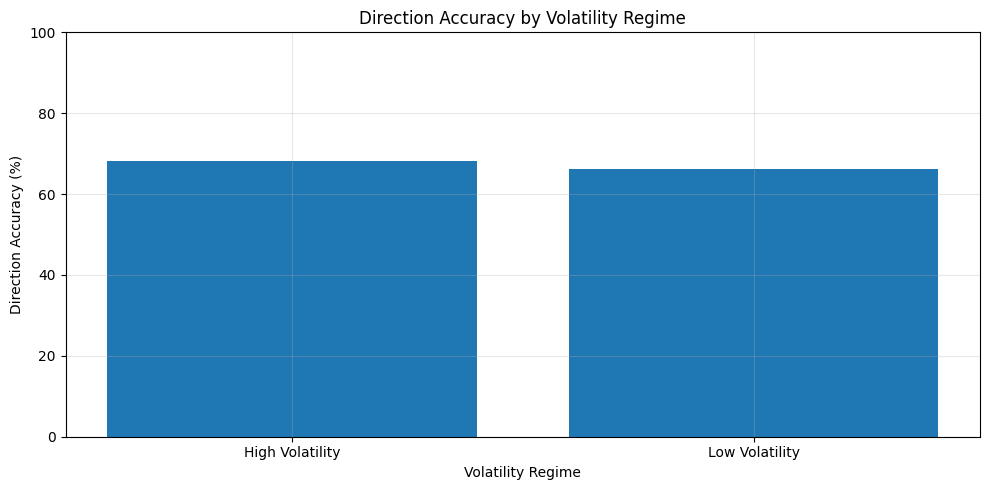

In [ ]:
# ============================================================
# 6. DIRECTION ACCURACY GRAFİĞİ
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    direction_by_regime["Volatility_Regime"],
    direction_by_regime["Direction_Accuracy"]
)

plt.title("Direction Accuracy by Volatility Regime")
plt.xlabel("Volatility Regime")
plt.ylabel("Direction Accuracy (%)")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()